# Template 07: SHAP Analysis

**Purpose:** Generate residual + SHAP range plots for top features

**Inputs:**
- results/06_shap_train.parquet
- results/06_shap_test.parquet
- results/05_predictions_train.parquet
- results/05_predictions_test.parquet
- data/04_train.parquet
- data/04_test.parquet

**Outputs:**
- plots/{dataset}_{feature}_residual.png
- plots/{dataset}_{feature}_shap_range.png
- results/07_analysis_summary.yaml

In [1]:
config_path = "config/car_coll/v1"

In [2]:
# Parameters
config_path = "config/car_coll/v1"


In [3]:
import pandas as pd
import numpy as np
import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt
import yaml
import os
import sys
from pathlib import Path
from datetime import datetime

sys.path.insert(0, str(Path.cwd() / 'lib'))
from utils import setup_notebook_environment
from shap_utils import compute_shap_aggregate, create_residual_plot, create_shap_range_plot

print("########################################")
print("# STAGE 07: SHAP ANALYSIS")
print("########################################")

project_root = setup_notebook_environment()

########################################
# STAGE 07: SHAP ANALYSIS
########################################


In [4]:
with open(f"{config_path}/config.yaml") as f:
    cfg = yaml.safe_load(f)
output_base = cfg["paths"]["output_base"]
shap_cfg = cfg.get("shap_analysis", {})
top_n = shap_cfg.get("top_n_features", 40)
datasets = shap_cfg.get("datasets", ["train", "test"])
resid_cfg = shap_cfg.get("residual_plot", {})
shap_range_cfg = shap_cfg.get("shap_range_plot", {})
print(f"\nConfig: top_n={top_n}")


Config: top_n=40


In [5]:
plots_dir = f"{output_base}/plots"
os.makedirs(plots_dir, exist_ok=True)
print(f"Plots: {plots_dir}")

Plots: output/car_coll/v1/plots


In [6]:
print("\nLoading...")
shap_train = pd.read_parquet(f"{output_base}/results/06_shap_train.parquet")
shap_test = pd.read_parquet(f"{output_base}/results/06_shap_test.parquet")
preds_train = pd.read_parquet(f"{output_base}/results/05_predictions_train.parquet")
preds_test = pd.read_parquet(f"{output_base}/results/05_predictions_test.parquet")
df_train = pd.read_parquet(f"{output_base}/data/04_train.parquet")
df_test = pd.read_parquet(f"{output_base}/data/04_test.parquet")
print(f"SHAP: {shap_train.shape}, {shap_test.shape}")
print(f"Preds: {preds_train.shape}, {preds_test.shape}")


Loading...


SHAP: (10000, 91), (2707950, 91)
Preds: (2716120, 3), (2707950, 3)


In [7]:
# Merge train data with predictions
data_tr = df_train.loc[shap_train.index].copy()
data_tr['actual'] = preds_train.loc[shap_train.index, 'actual']
data_tr['pred'] = preds_train.loc[shap_train.index, 'pred']
data_tr['weight'] = preds_train.loc[shap_train.index, 'exposure']

fc_tr = shap_train.copy()
fc_tr['weight'] = data_tr['weight']
out_tr = data_tr
print(f"Train: {out_tr.shape}")

Train: (10000, 115)


In [8]:
# Merge test data with predictions
data_te = df_test.loc[shap_test.index].copy()
data_te['actual'] = preds_test.loc[shap_test.index, 'actual']
data_te['pred'] = preds_test.loc[shap_test.index, 'pred']
data_te['weight'] = preds_test.loc[shap_test.index, 'exposure']

fc_te = shap_test.copy()
fc_te['weight'] = data_te['weight']
out_te = data_te
print(f"Test: {out_te.shape}")

Test: (2707950, 115)


In [9]:
print("\nSHAP aggregates...")
shagg, shagg_num, shagg2 = compute_shap_aggregate(fc_tr, weight_col="weight")
print(f"Features: {len(shagg2)}")
print(shagg2.head(10))


SHAP aggregates...
Features: 70
                            field   total_shap
8           multi_pol_unknown_cal  1337.669831
87        cef_first_poten_dam_ind   615.289916
7                     married_ind   565.730029
89            cef_lien_holder_ind   458.582980
17                   vc_doors_raw   245.070576
74  vc_speed_sensitive_volume_raw   241.442687
66           vc_premium_audio_raw   209.124106
70              vc_rear_wiper_raw   204.486239
54     vc_heated_side_mirrors_raw   198.343443
79          vc_tinted_windows_raw   129.678268


In [10]:
features = shagg2["field"].head(top_n).tolist()
print(f"\nPlotting {len(features)} features")


Plotting 40 features


In [11]:
summary = {"timestamp": datetime.now().isoformat(), "plots": 0}
plots_by_feature = {}

In [12]:
print("="*60)
print("GENERATING PLOTS")
print("="*60)
for i, f in enumerate(features, 1):
    print(f"[{i}/{len(features)}] {f}")
    plots_by_feature[f] = []
    if f not in out_tr.columns or f not in out_te.columns:
        print(f"  WARNING: Feature {f} not found, skipping")
        continue
    if "train" in datasets:
        try:
            fig, _ = create_residual_plot(out_tr, f, "weight", dataset_label="Train", **resid_cfg)
            path = f"{plots_dir}/train_{f}_residual.png"
            fig.savefig(path, dpi=100, bbox_inches="tight")
            plt.close(fig)
            plots_by_feature[f].append(path)
            summary["plots"] += 1
        except Exception as e:
            print(f"  ERROR (Train Residual): {e}")
        try:
            fig, _ = create_shap_range_plot(fc_tr, data_tr, f, "weight", dataset_label="Train", **shap_range_cfg)
            path = f"{plots_dir}/train_{f}_shap_range.png"
            fig.savefig(path, dpi=100, bbox_inches="tight")
            plt.close(fig)
            plots_by_feature[f].append(path)
            summary["plots"] += 1
        except Exception as e:
            print(f"  ERROR (Train SHAP): {e}")
    if "test" in datasets:
        try:
            fig, _ = create_residual_plot(out_te, f, "weight", dataset_label="Test", **resid_cfg)
            path = f"{plots_dir}/test_{f}_residual.png"
            fig.savefig(path, dpi=100, bbox_inches="tight")
            plt.close(fig)
            plots_by_feature[f].append(path)
            summary["plots"] += 1
        except Exception as e:
            print(f"  ERROR (Test Residual): {e}")
        try:
            fig, _ = create_shap_range_plot(fc_te, data_te, f, "weight", dataset_label="Test", **shap_range_cfg)
            path = f"{plots_dir}/test_{f}_shap_range.png"
            fig.savefig(path, dpi=100, bbox_inches="tight")
            plt.close(fig)
            plots_by_feature[f].append(path)
            summary["plots"] += 1
        except Exception as e:
            print(f"  ERROR (Test SHAP): {e}")
print(f"\n[OK] Generated summary")

GENERATING PLOTS
[1/40] multi_pol_unknown_cal

multi_pol_unknown_cal Summary:
 multi_pol_unknown_cal      weight   act_rate  pred_rate
                     0 4537.020159 248.164568 271.005160
                     1 1497.665933 744.137195 520.741964


/Users/Mach/dev/aps/code/26Dmodelv1/lib/shap_utils.py:155: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  c['SHAP'].fillna(lowest_contrib, inplace=True)
/Users/Mach/dev/aps/code/26Dmodelv1/lib/shap_utils.py:155: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace 


multi_pol_unknown_cal Summary:
 multi_pol_unknown_cal       weight   act_rate  pred_rate
                     0 1.202233e+06 253.659617 274.843721
                     1 4.166114e+05 833.985688 519.068677


/Users/Mach/dev/aps/code/26Dmodelv1/lib/shap_utils.py:155: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  c['SHAP'].fillna(lowest_contrib, inplace=True)
/Users/Mach/dev/aps/code/26Dmodelv1/lib/shap_utils.py:155: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace 

[2/40] cef_first_poten_dam_ind

cef_first_poten_dam_ind Summary:
 cef_first_poten_dam_ind      weight   act_rate  pred_rate
                     0.0 3390.630609 437.904278 289.682028
                     1.0 2644.055483 285.782552 388.512507


...

[40/40] owt_leasepers_ind

owt_leasepers_ind Summary:
 owt_leasepers_ind      weight   act_rate  pred_rate
               0.0 5732.369519 390.832546 336.011530
               1.0  302.316573   0.000000 275.575701


/Users/Mach/dev/aps/code/26Dmodelv1/lib/shap_utils.py:155: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  c['SHAP'].fillna(lowest_contrib, inplace=True)
/Users/Mach/dev/aps/code/26Dmodelv1/lib/shap_utils.py:155: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace 


owt_leasepers_ind Summary:
 owt_leasepers_ind       weight   act_rate  pred_rate
               0.0 1.533642e+06 411.445568 341.336221
               1.0 8.520283e+04 251.116664 272.158716


/Users/Mach/dev/aps/code/26Dmodelv1/lib/shap_utils.py:155: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  c['SHAP'].fillna(lowest_contrib, inplace=True)
/Users/Mach/dev/aps/code/26Dmodelv1/lib/shap_utils.py:155: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace 


[OK] Generated summary



DISPLAYING ALL PLOTS

FEATURE: multi_pol_unknown_cal


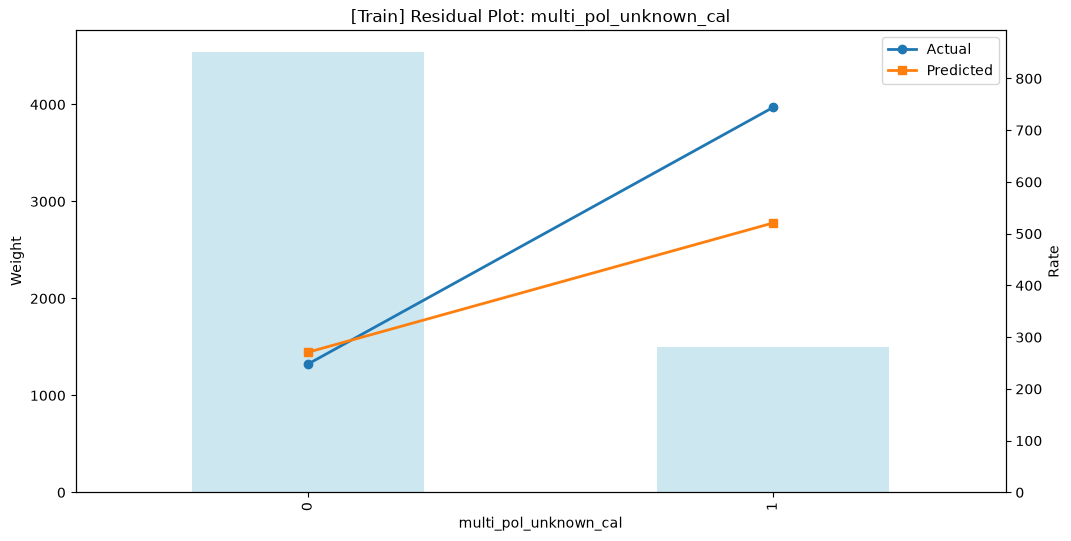

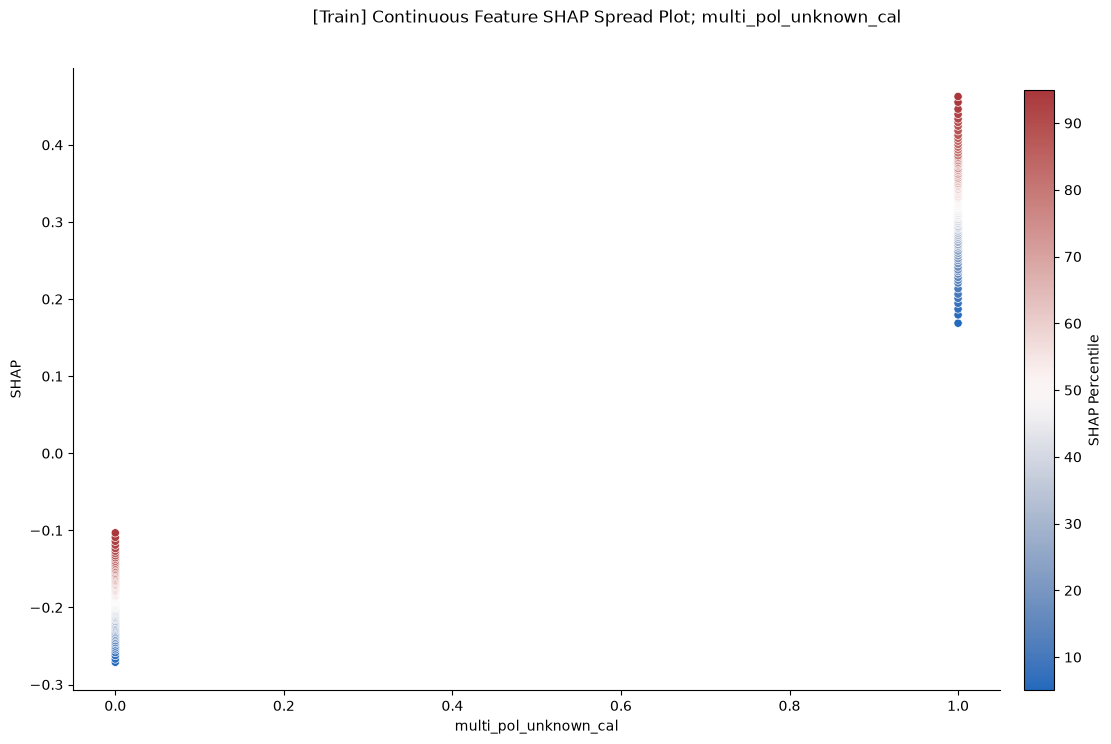

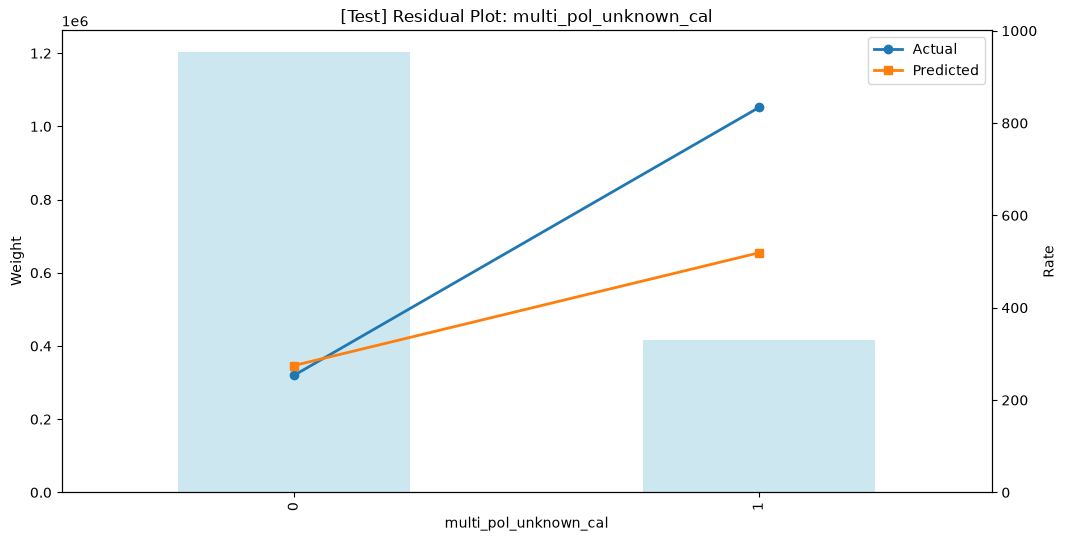

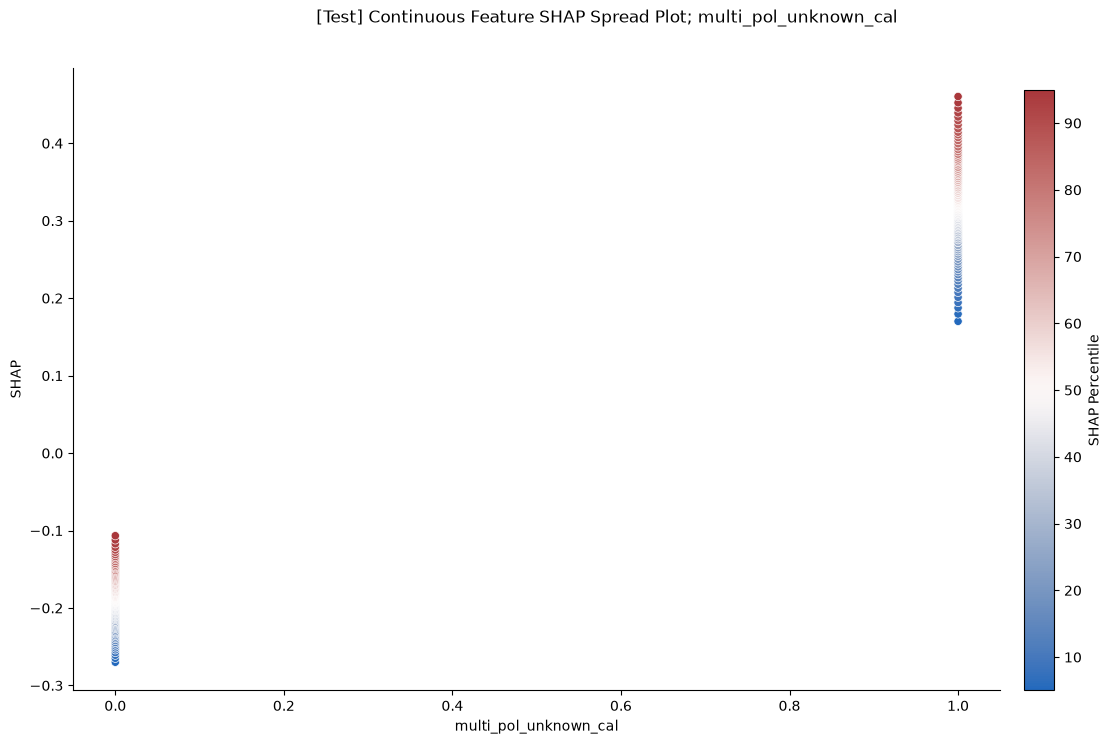


FEATURE: cef_first_poten_dam_ind


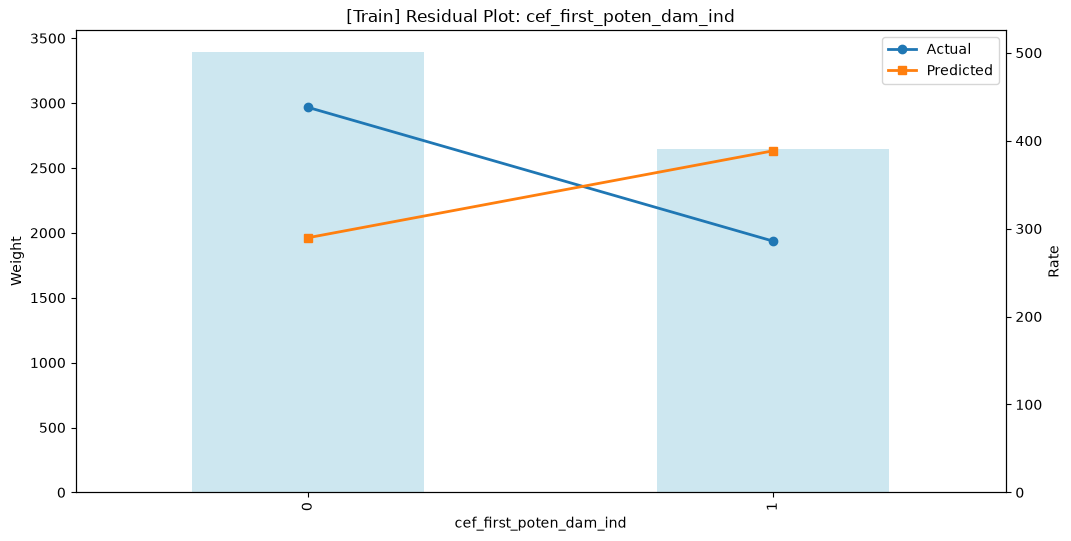

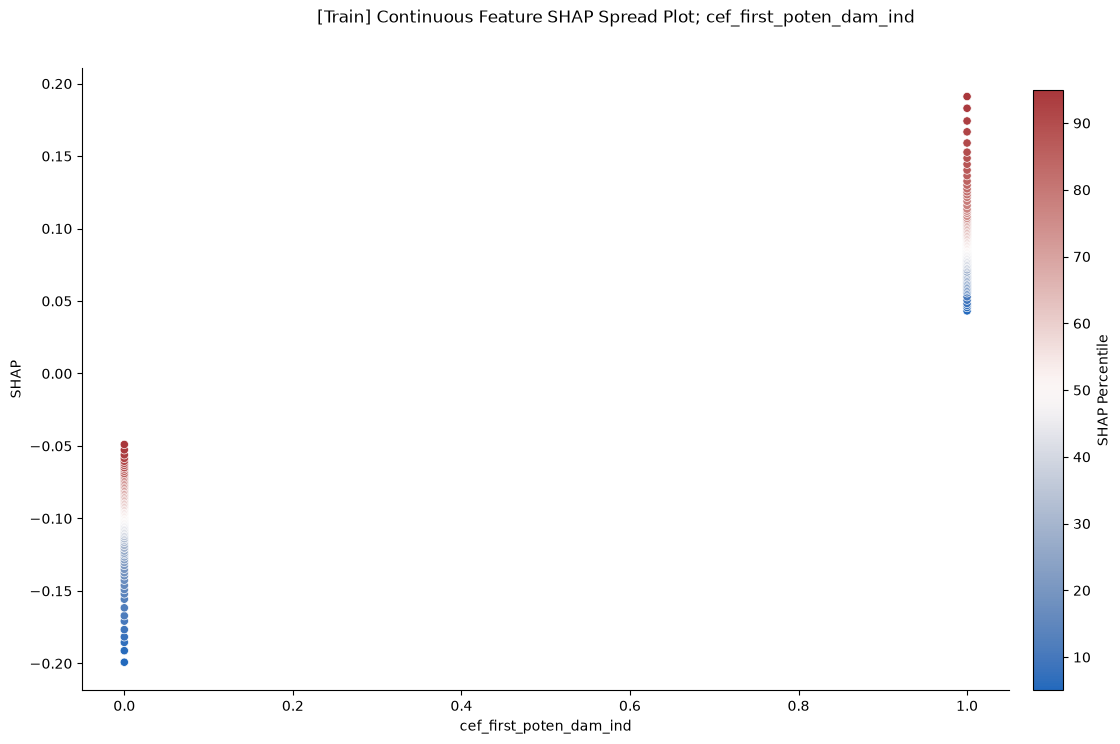

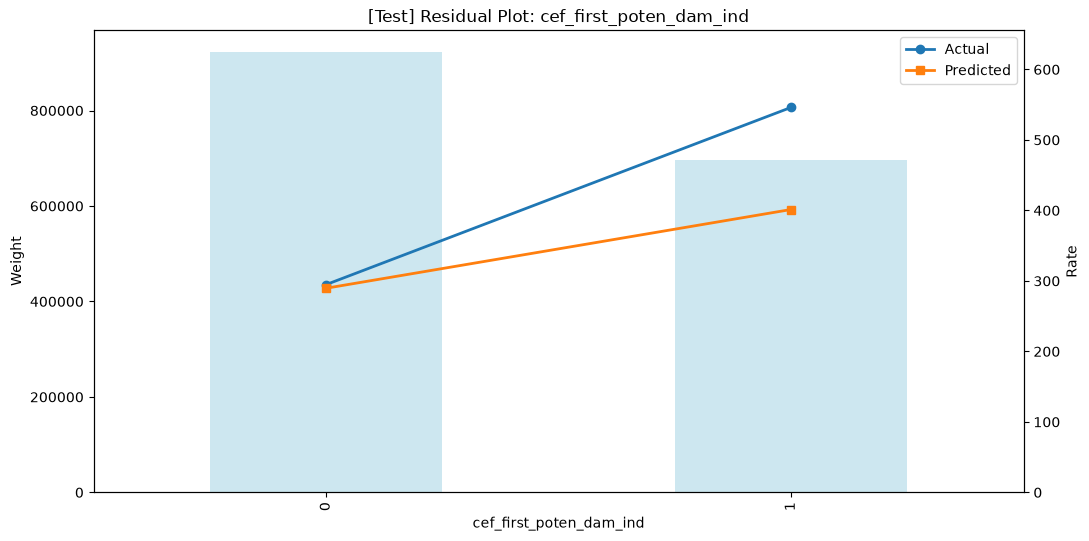

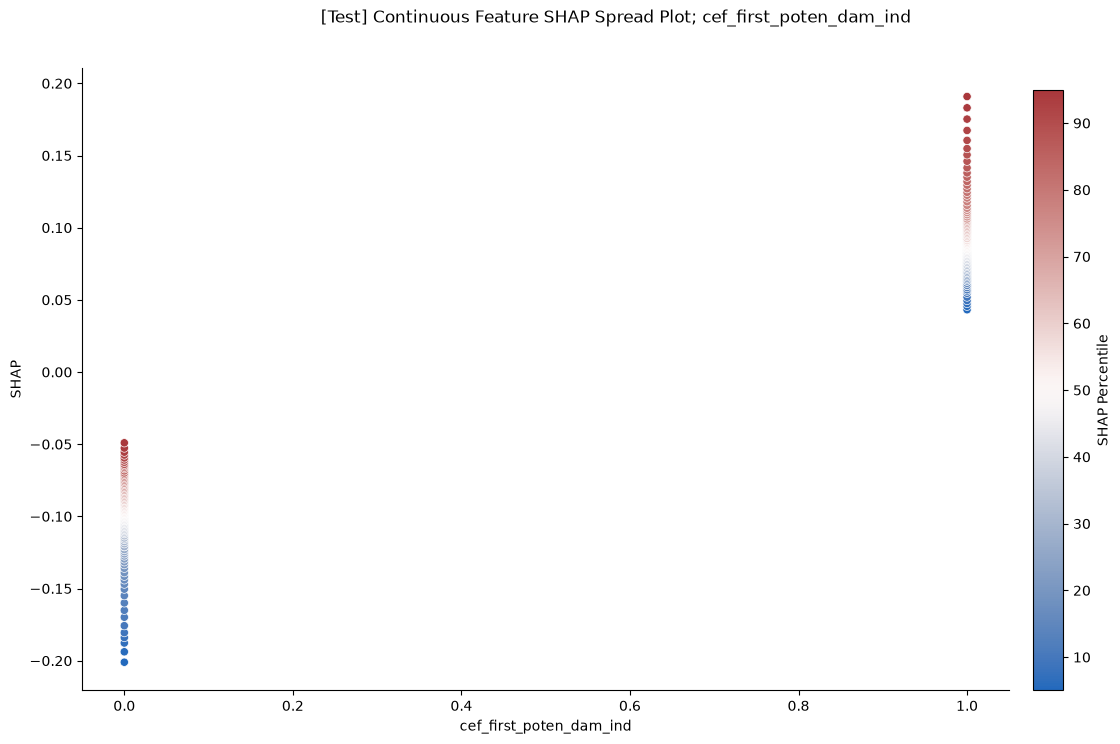


FEATURE: married_ind


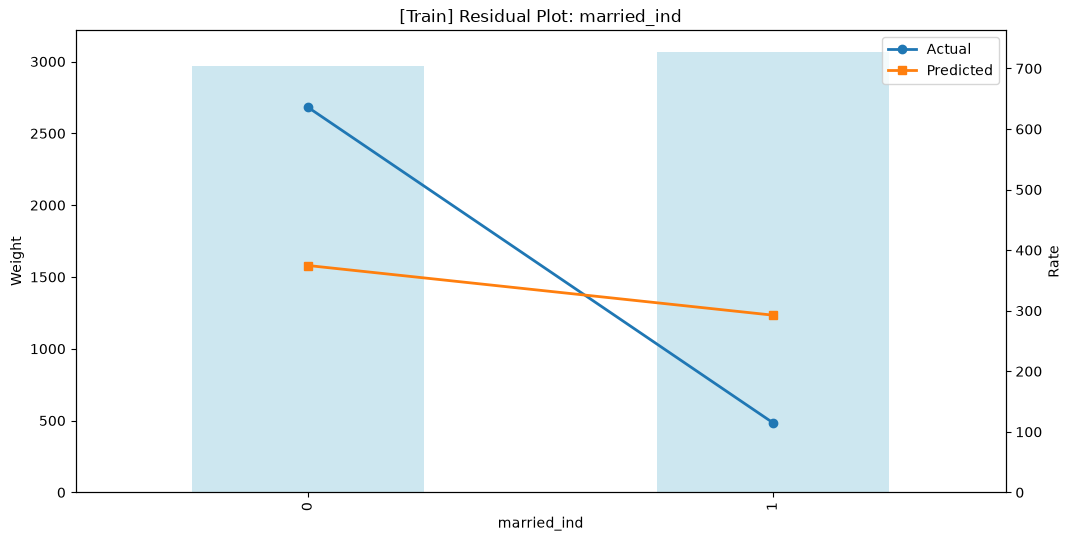

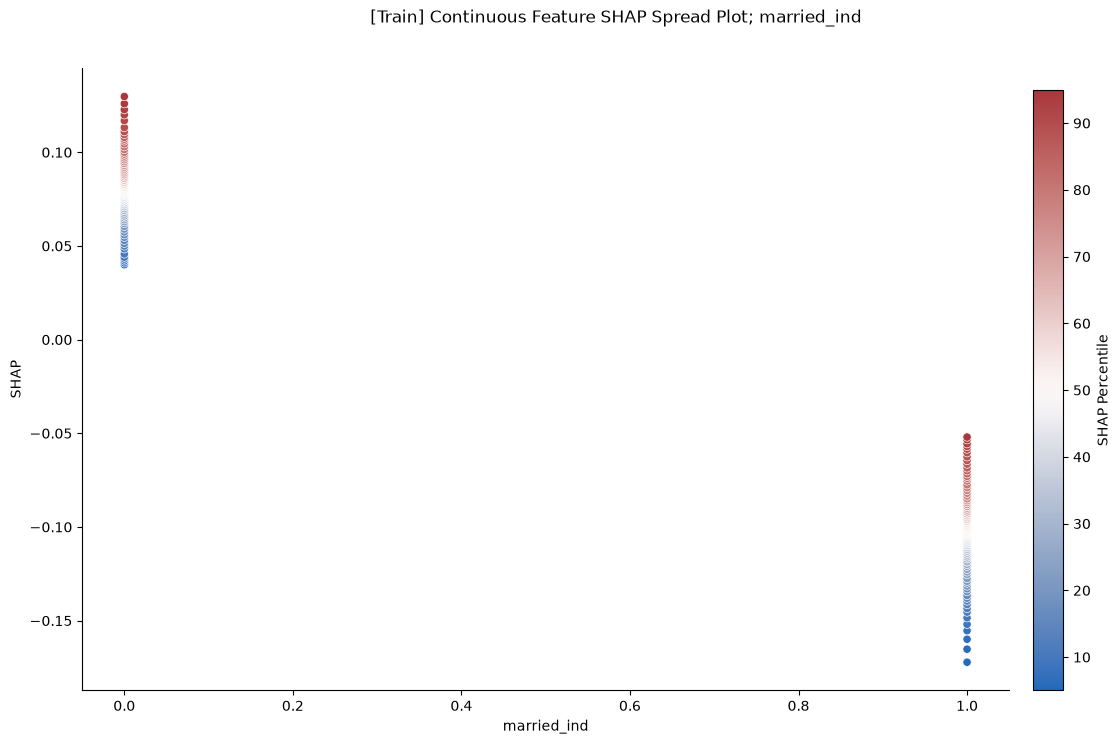

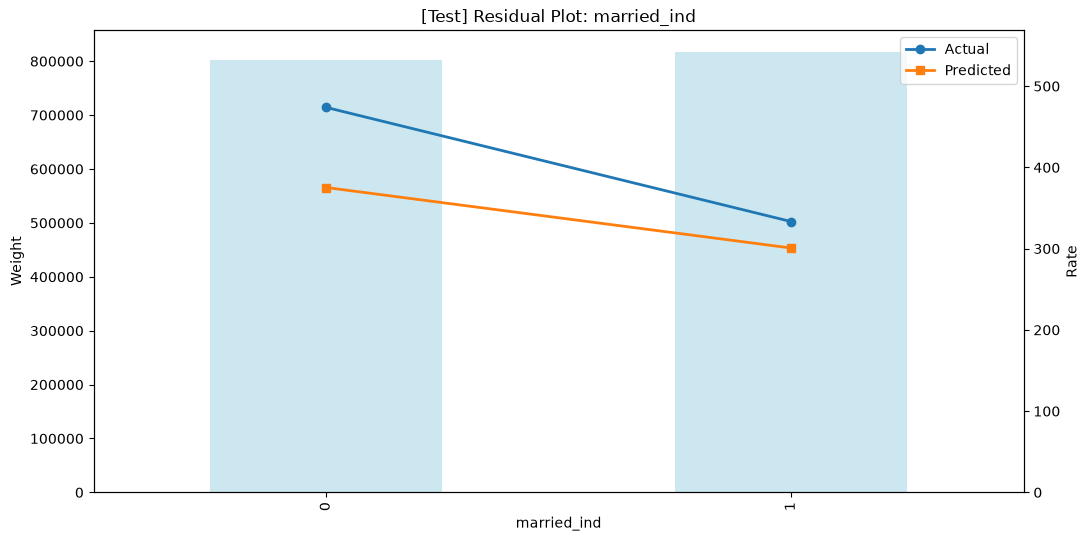

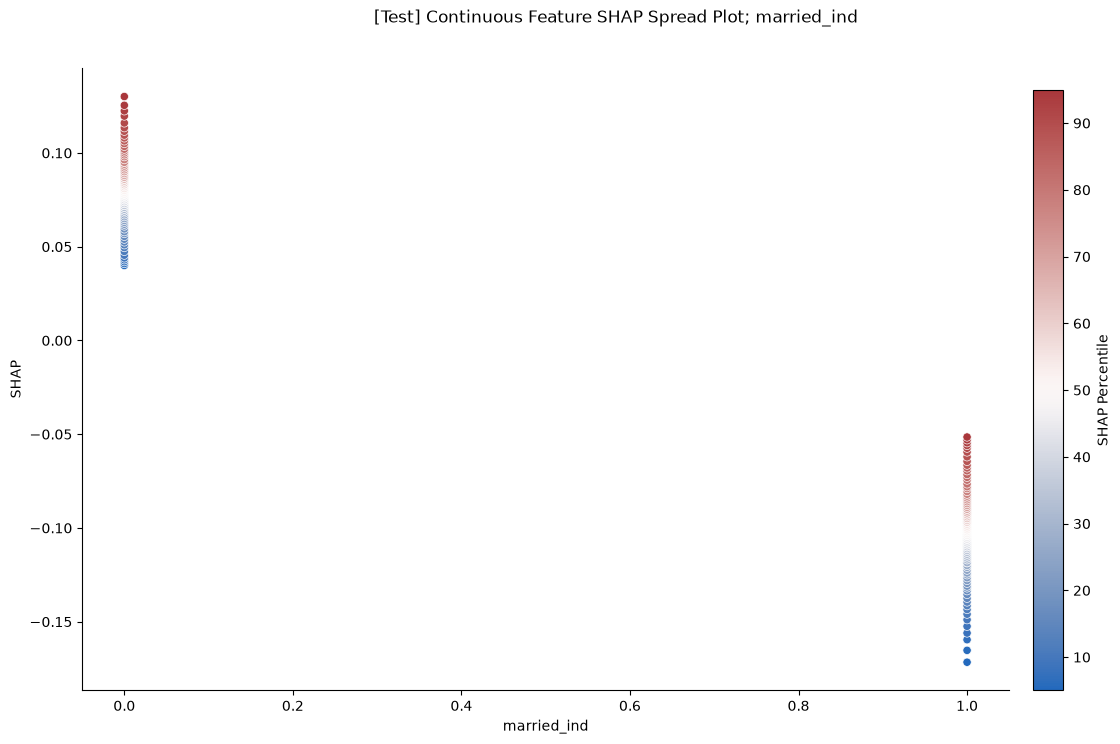


FEATURE: cef_lien_holder_ind


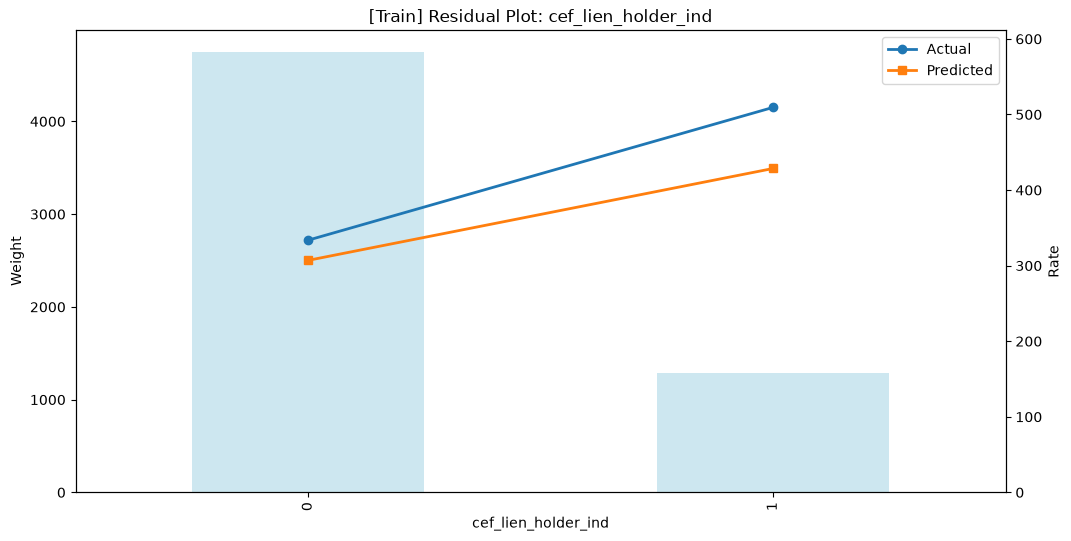

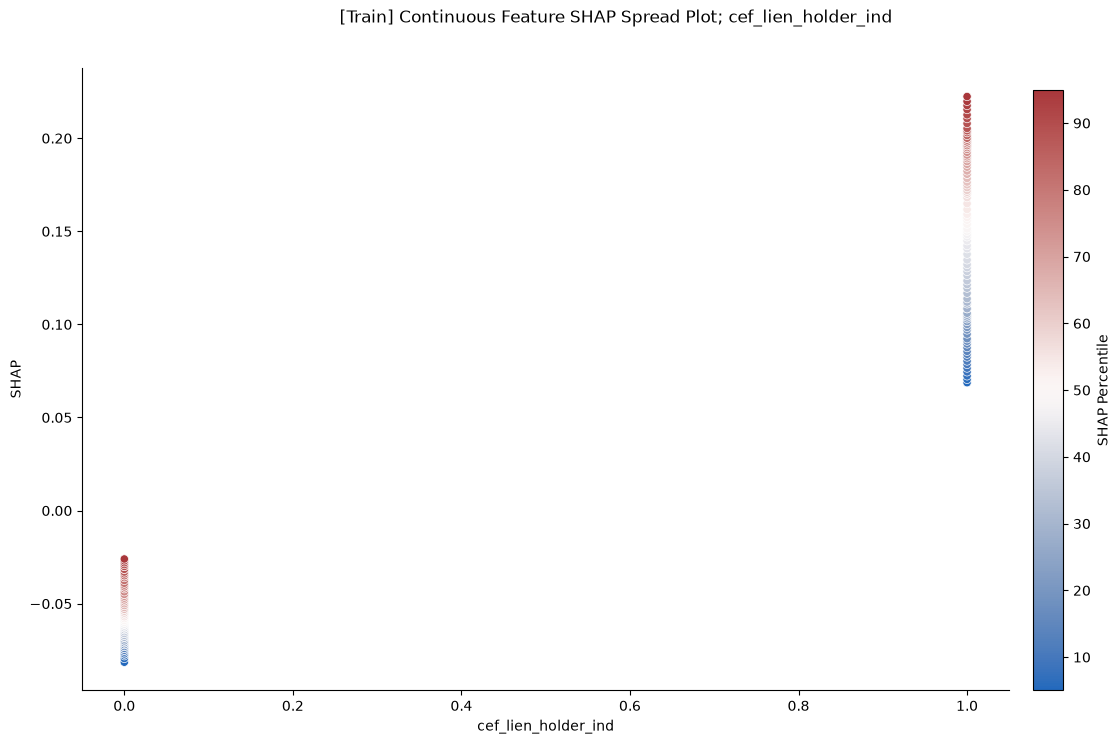

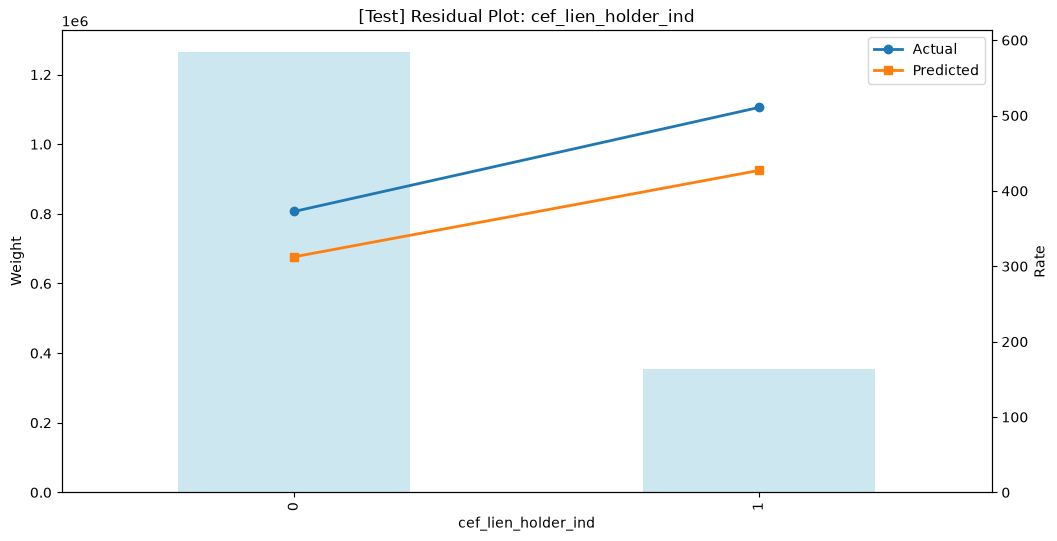

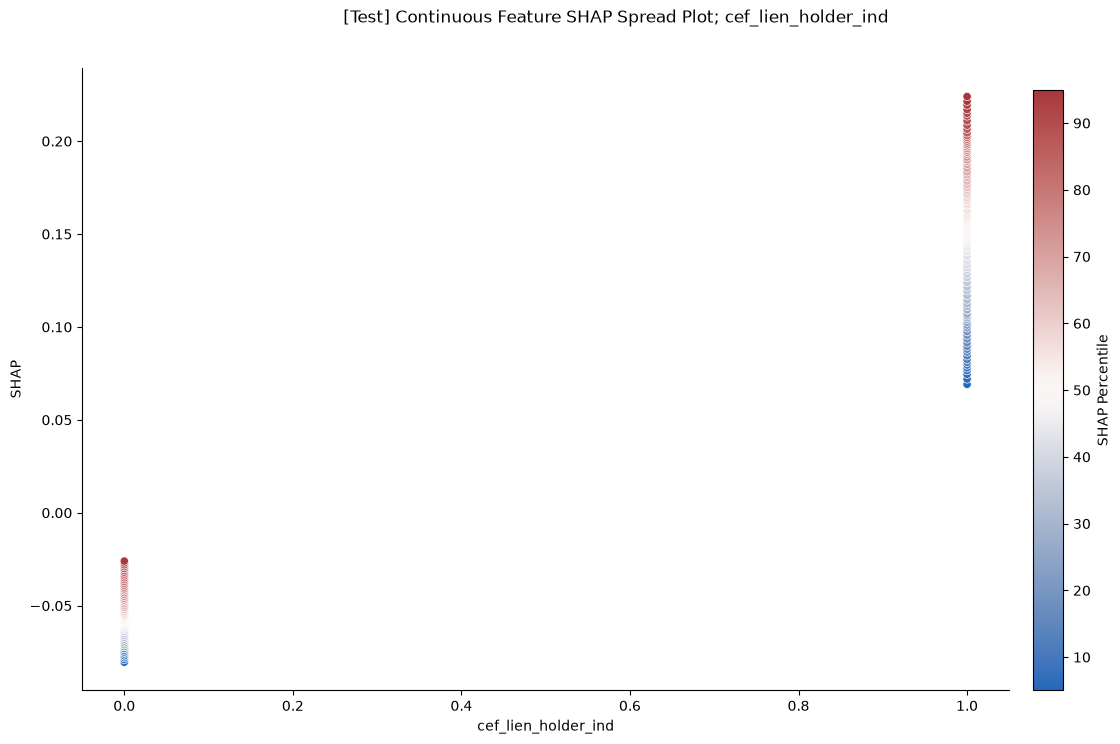


FEATURE: vc_doors_raw


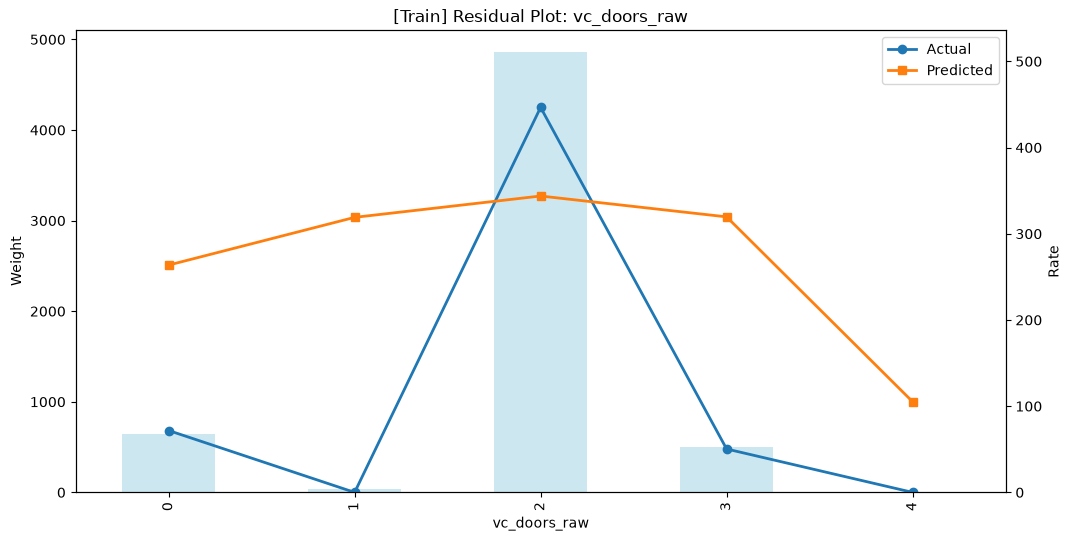

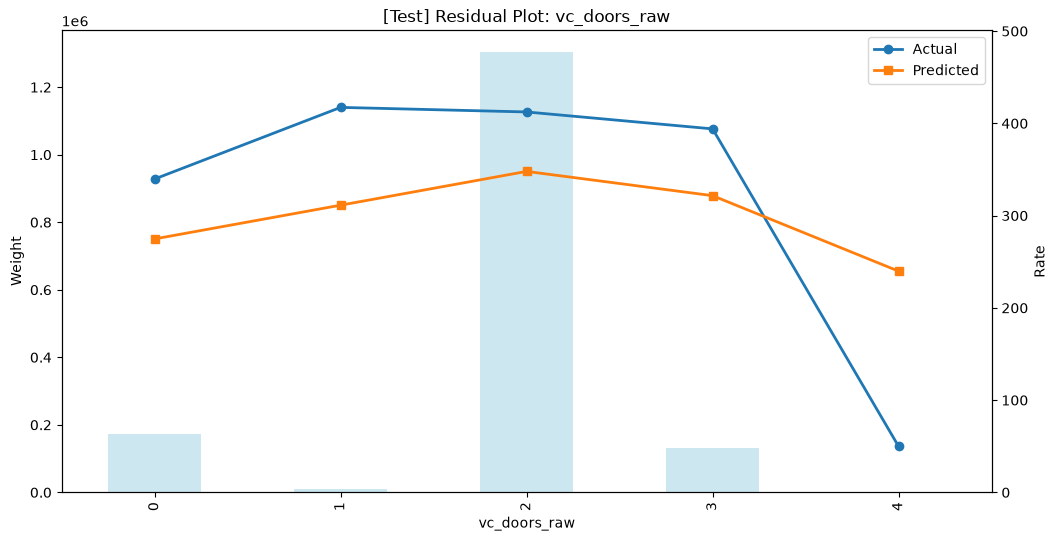

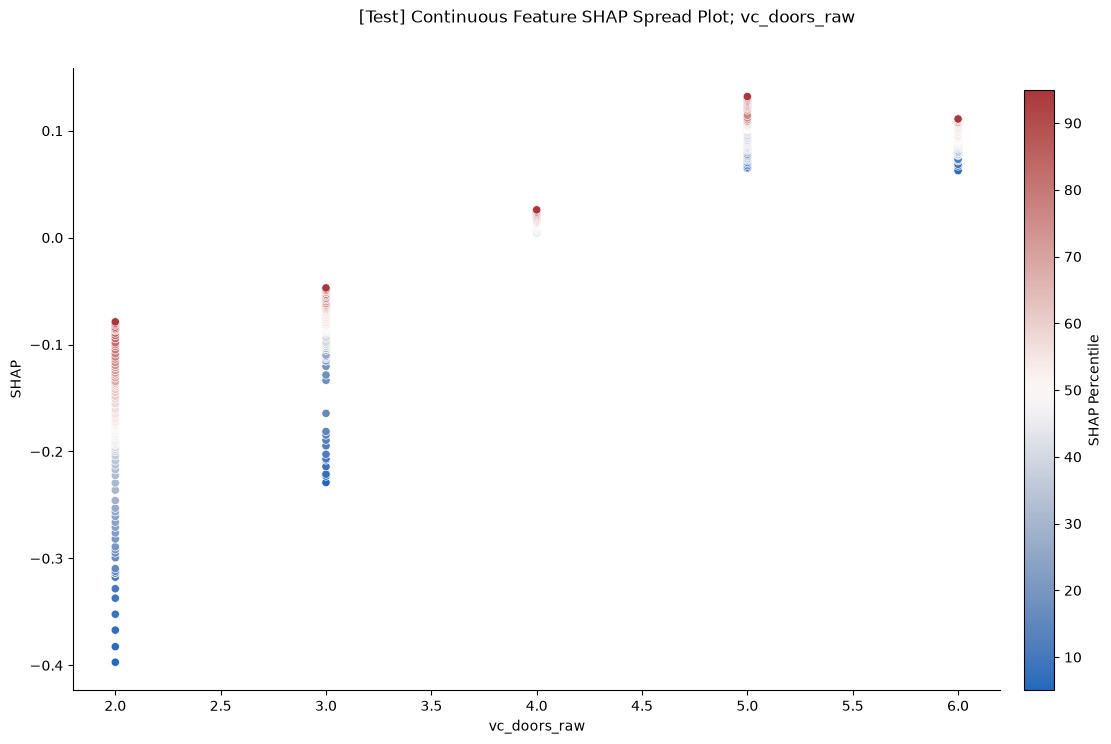


FEATURE: vc_speed_sensitive_volume_raw


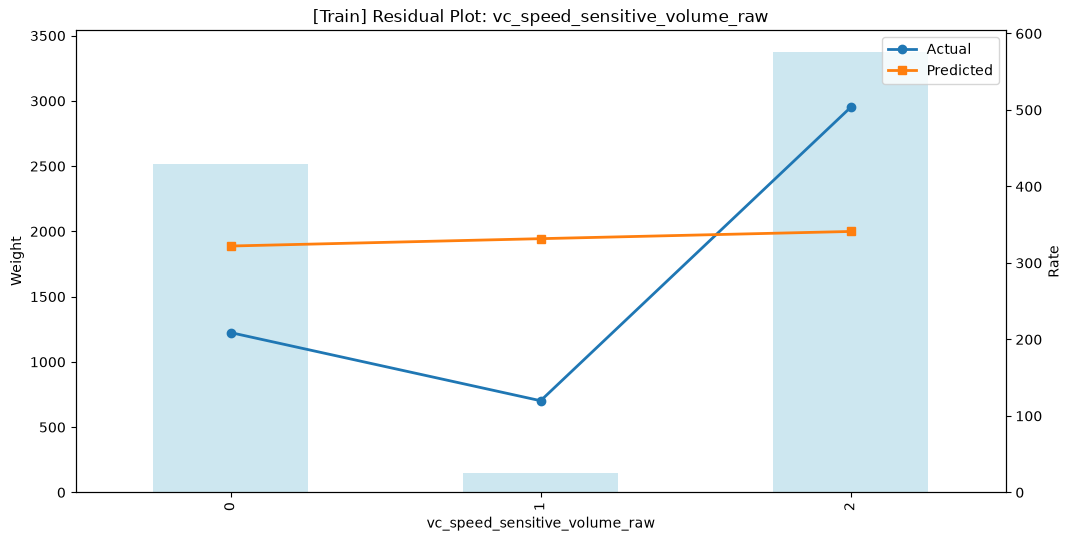

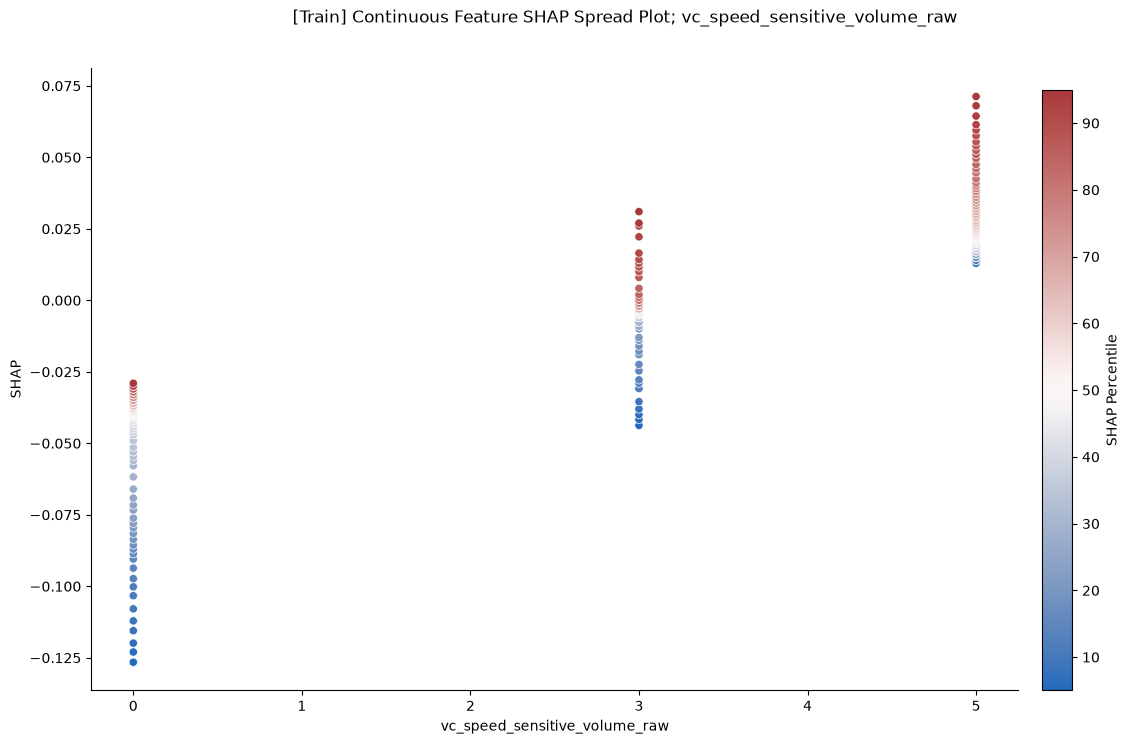

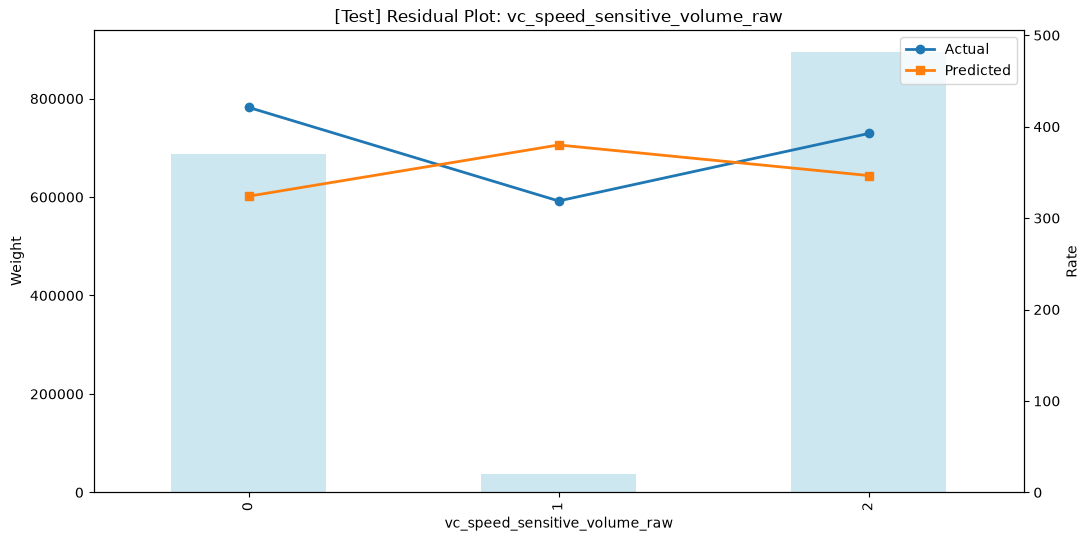

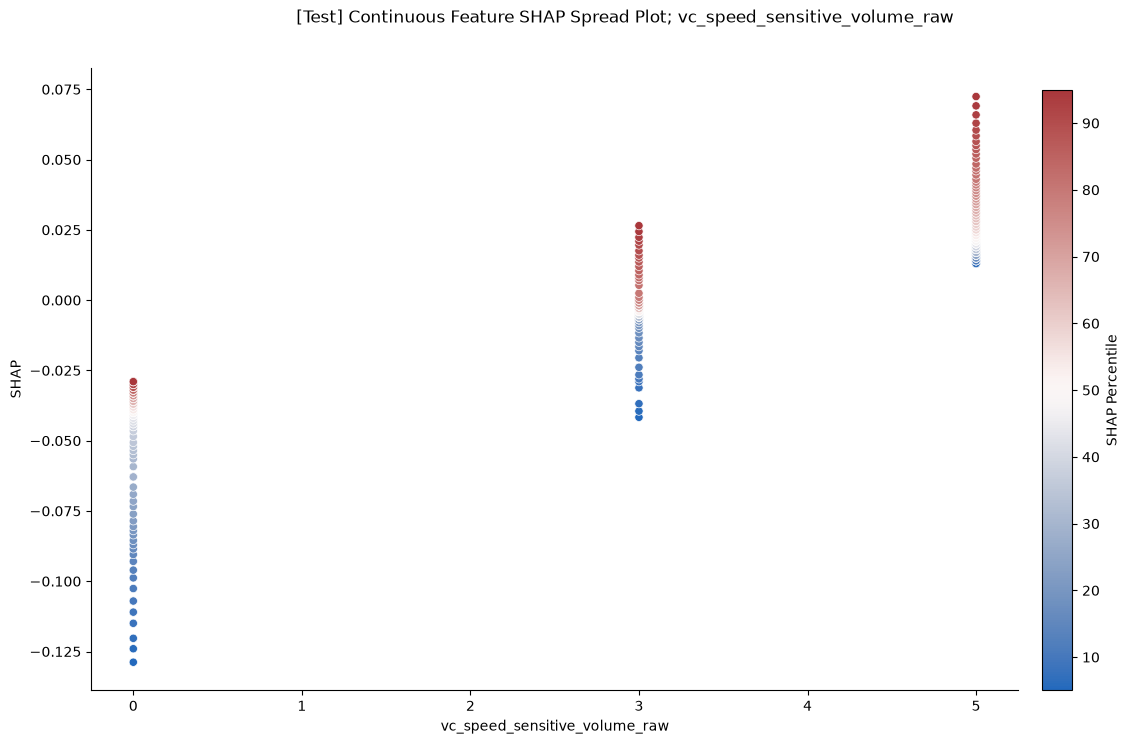


FEATURE: vc_premium_audio_raw


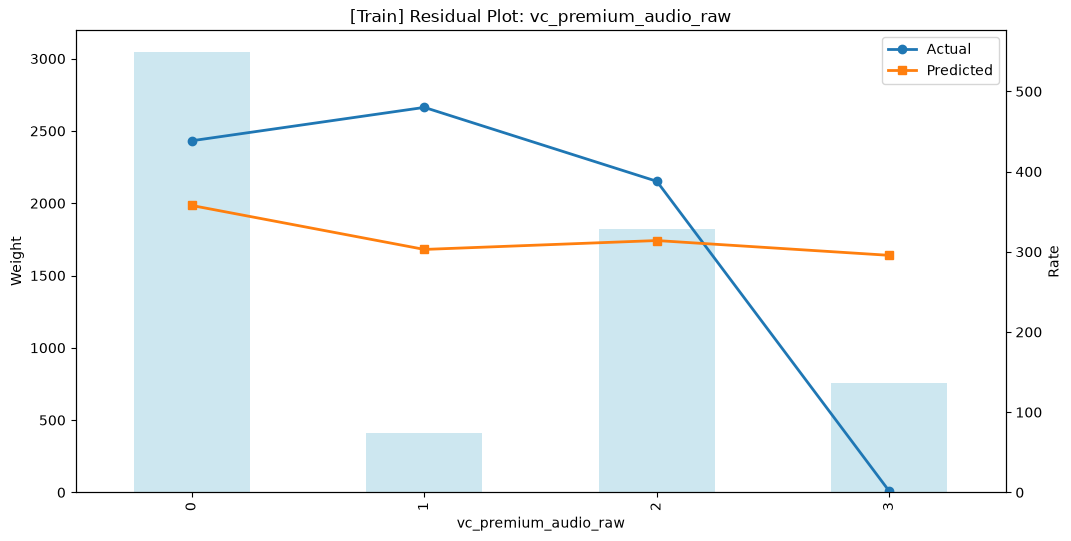

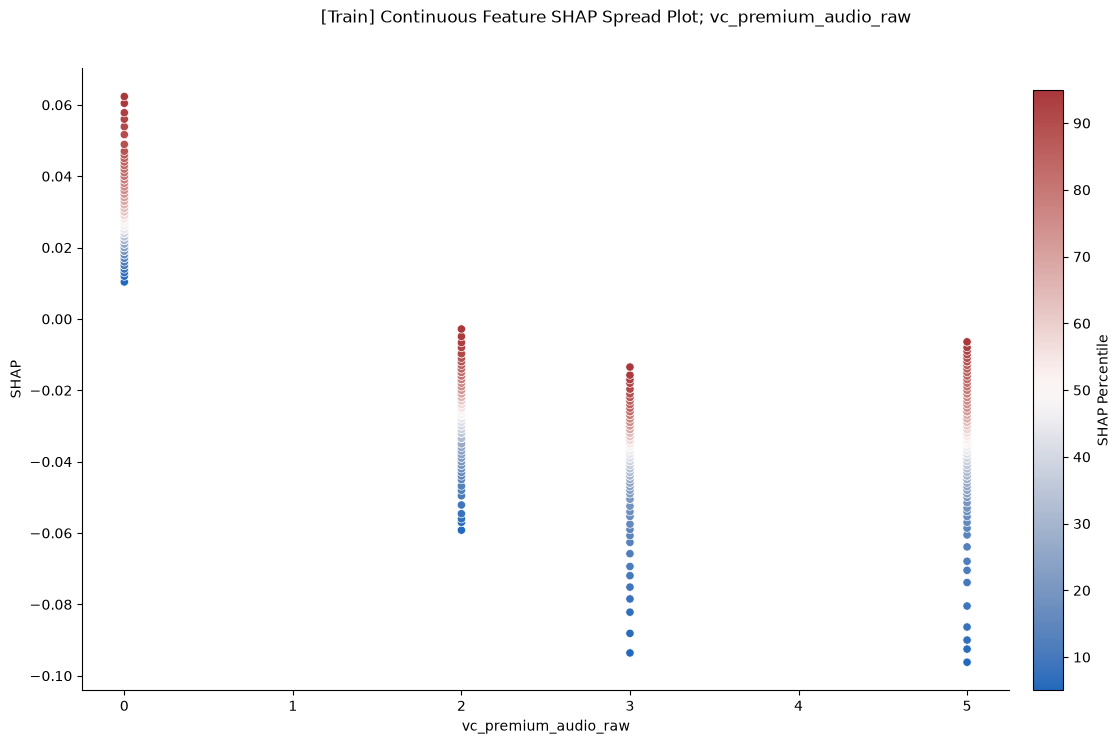

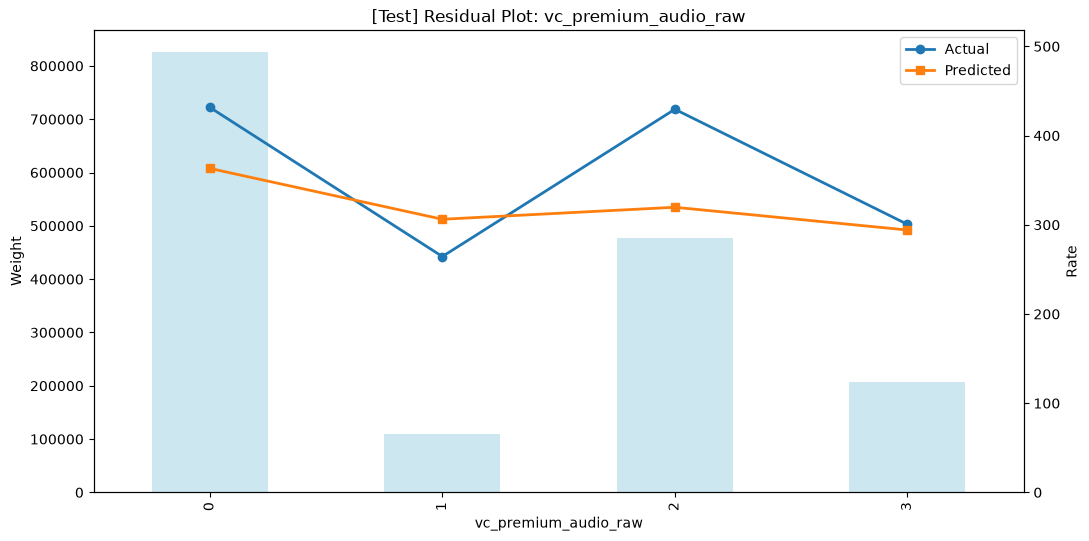

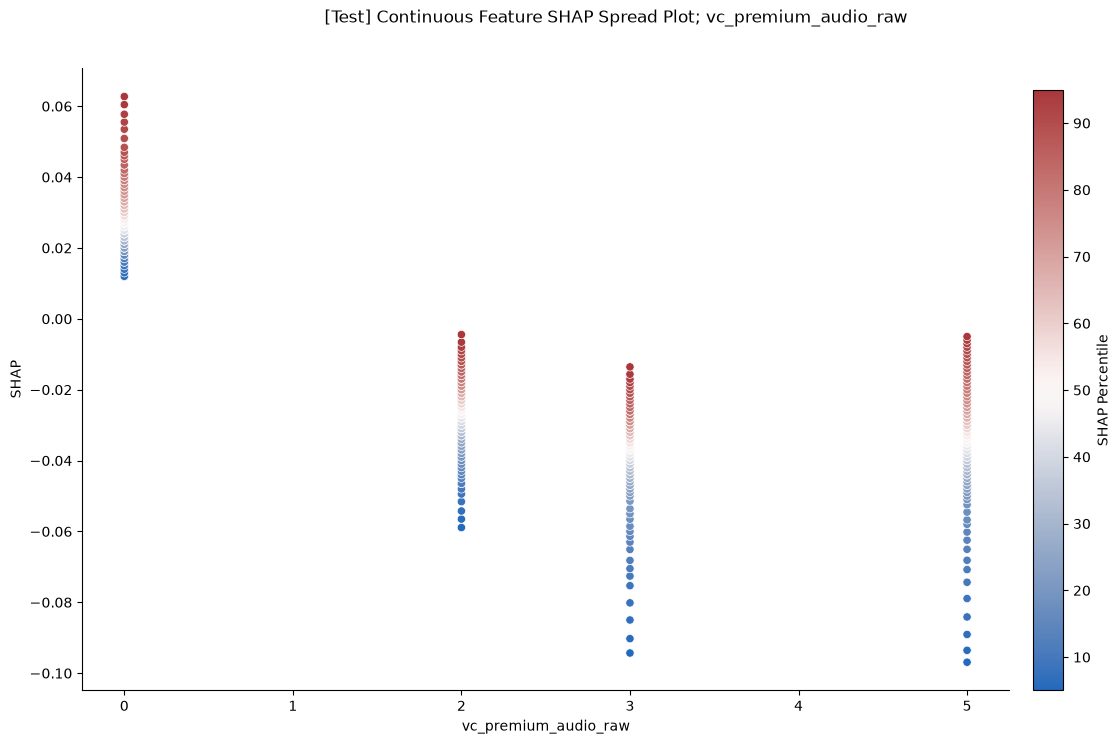


FEATURE: vc_rear_wiper_raw


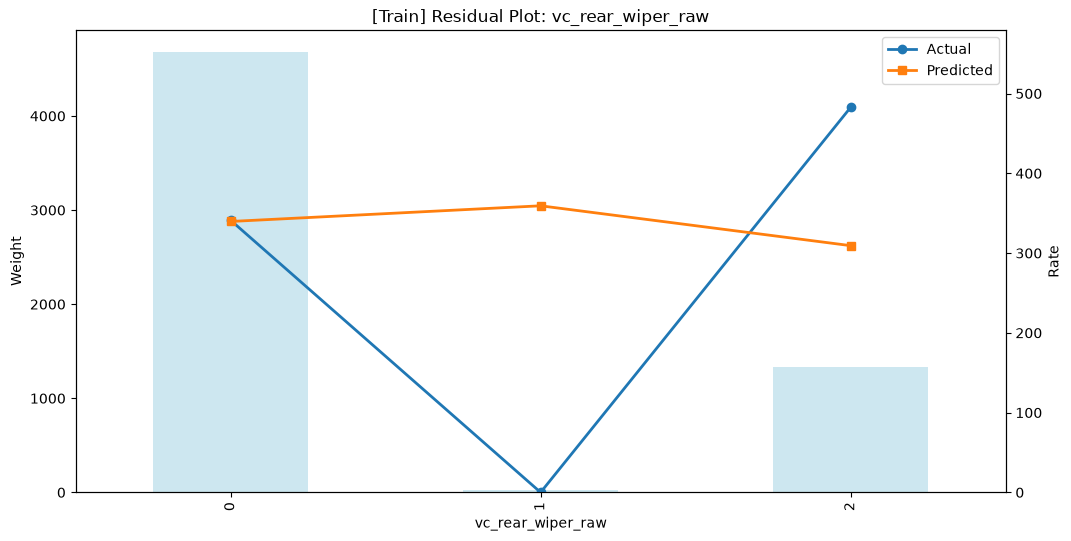

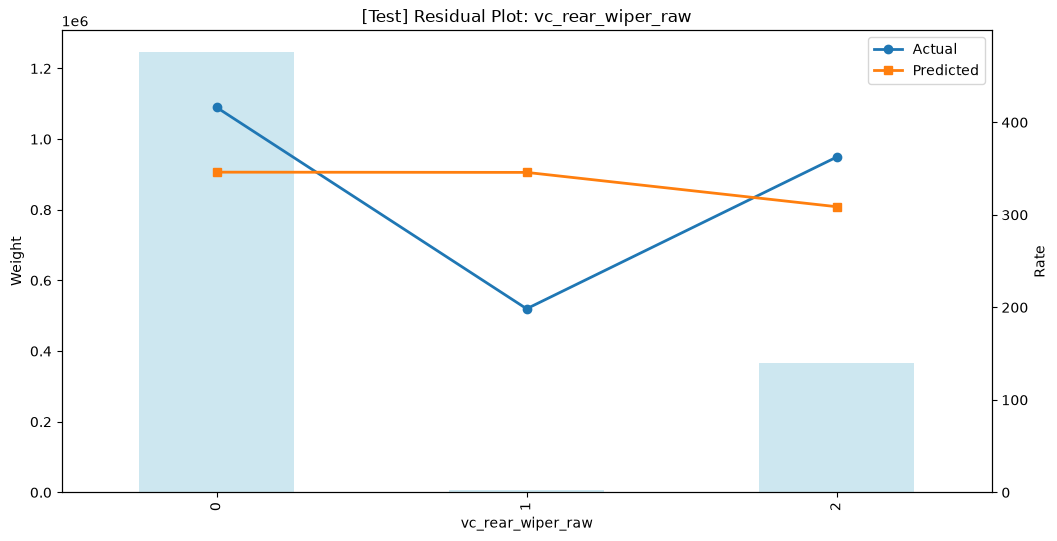

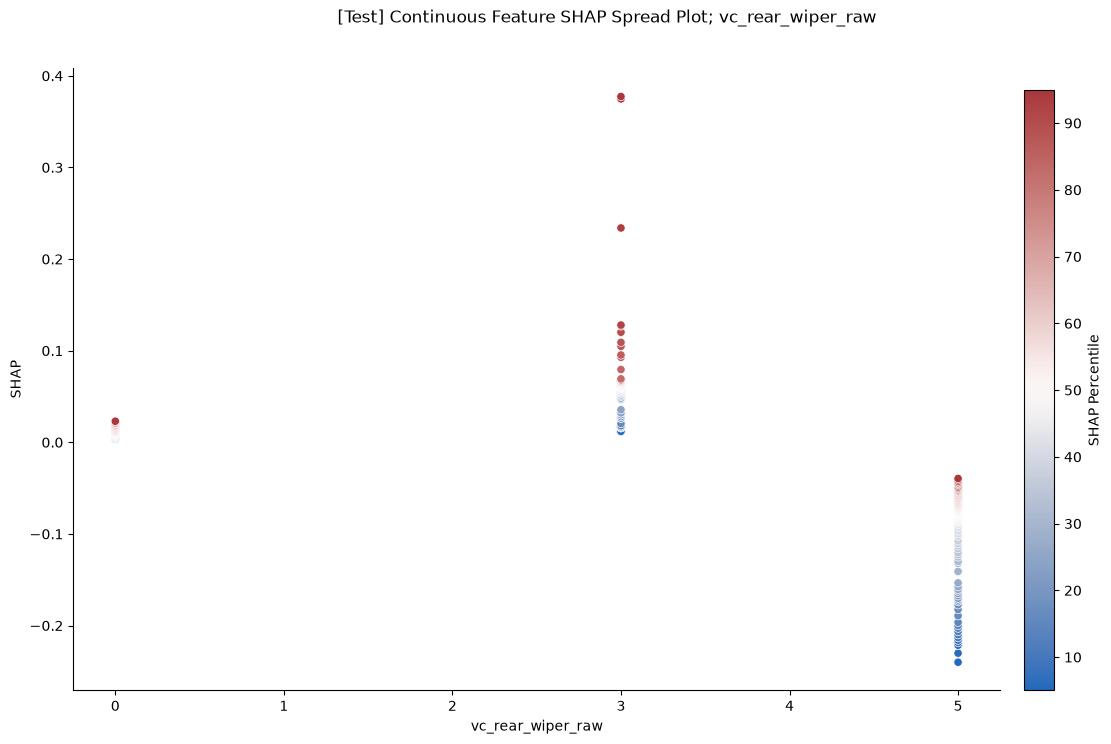


FEATURE: vc_heated_side_mirrors_raw


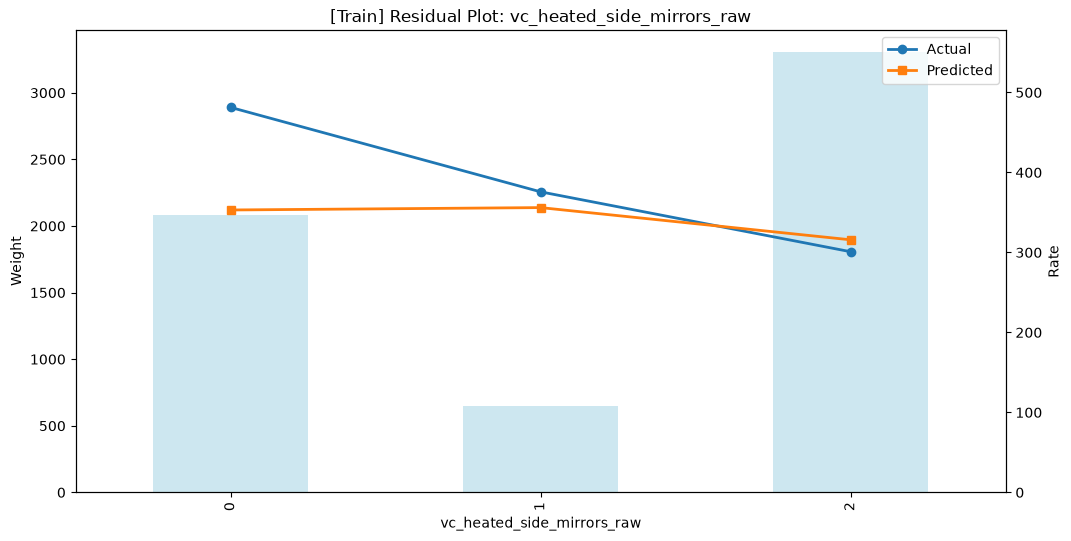

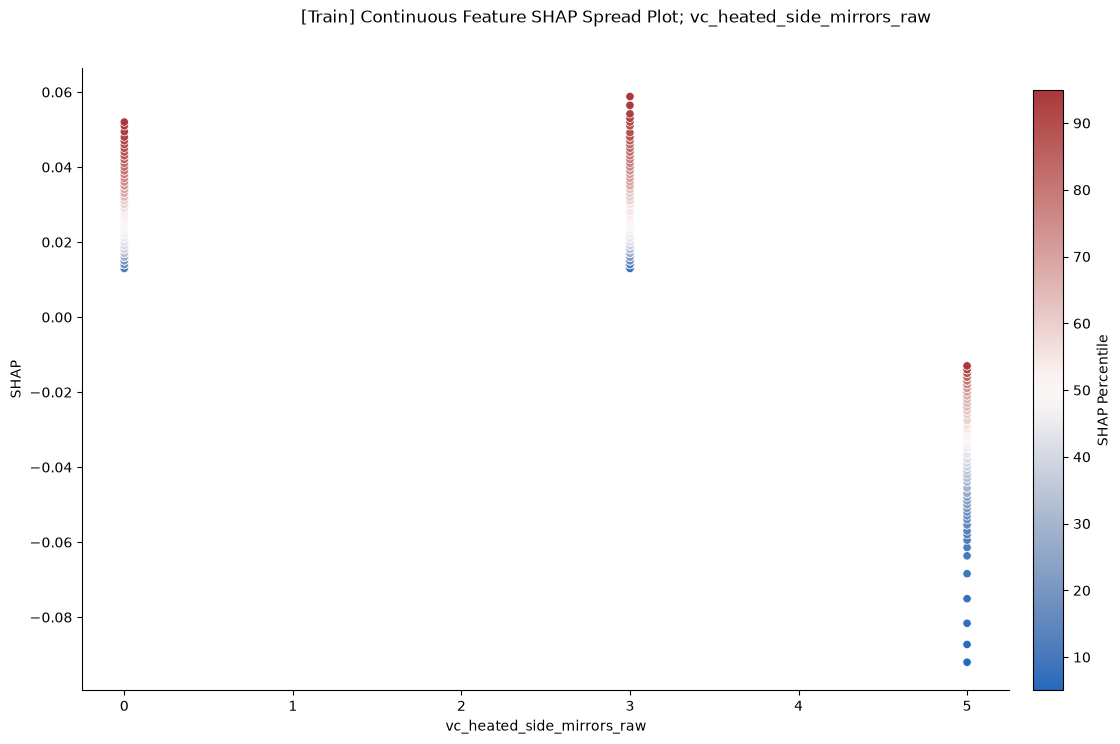

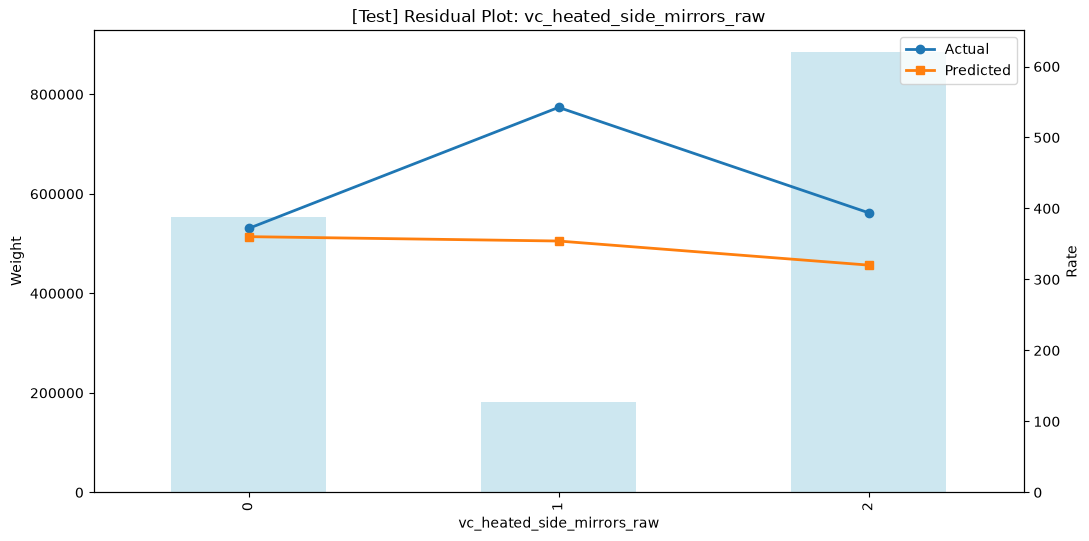

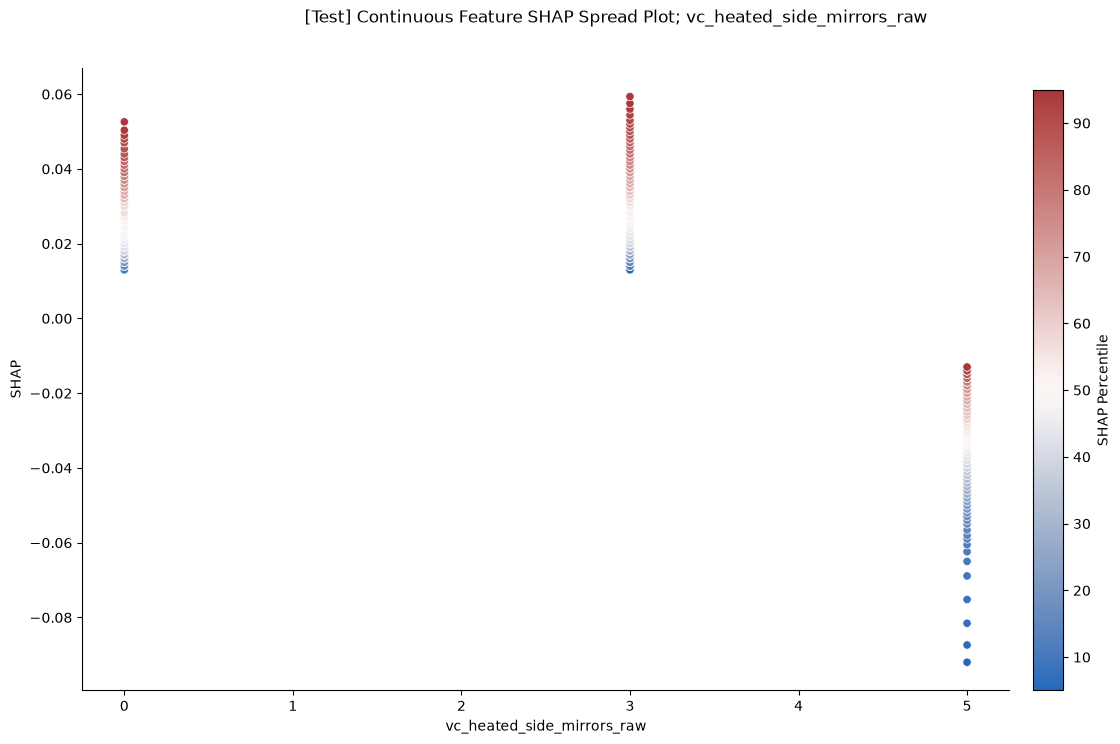


FEATURE: vc_tinted_windows_raw


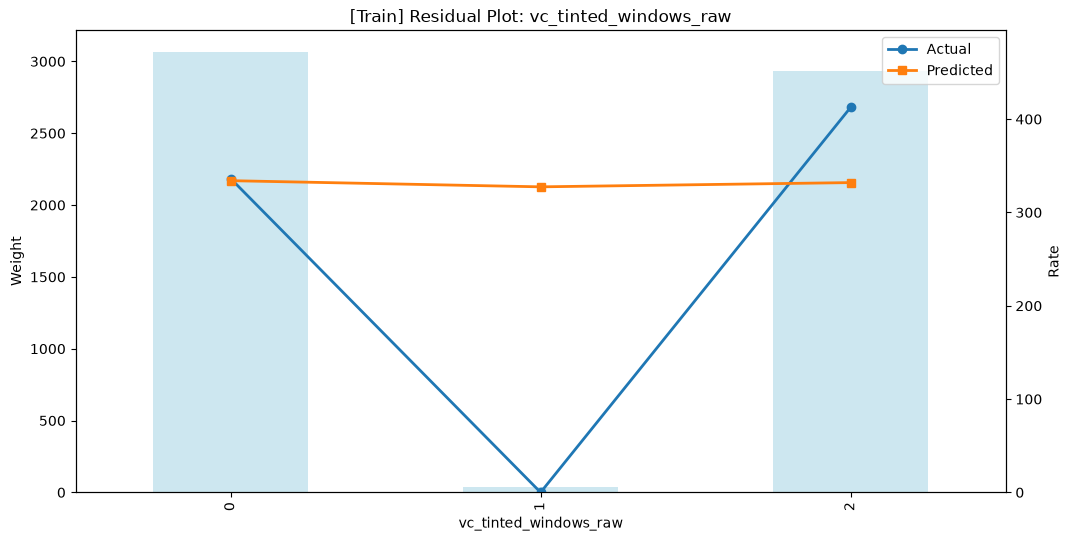

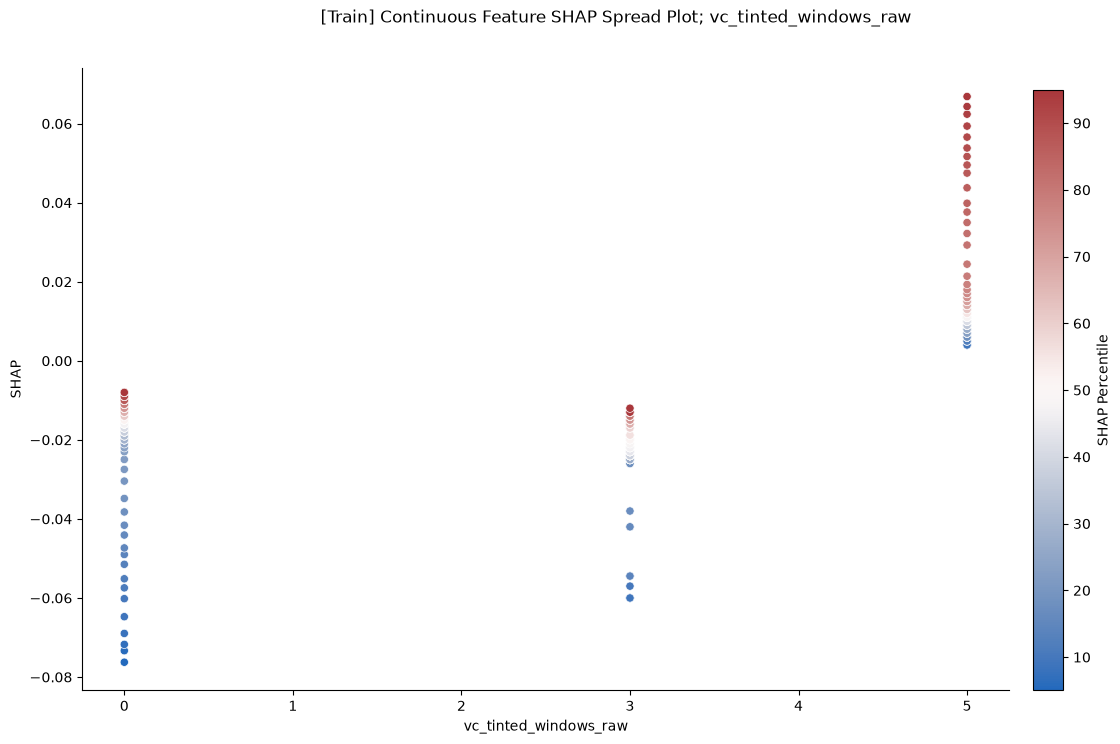

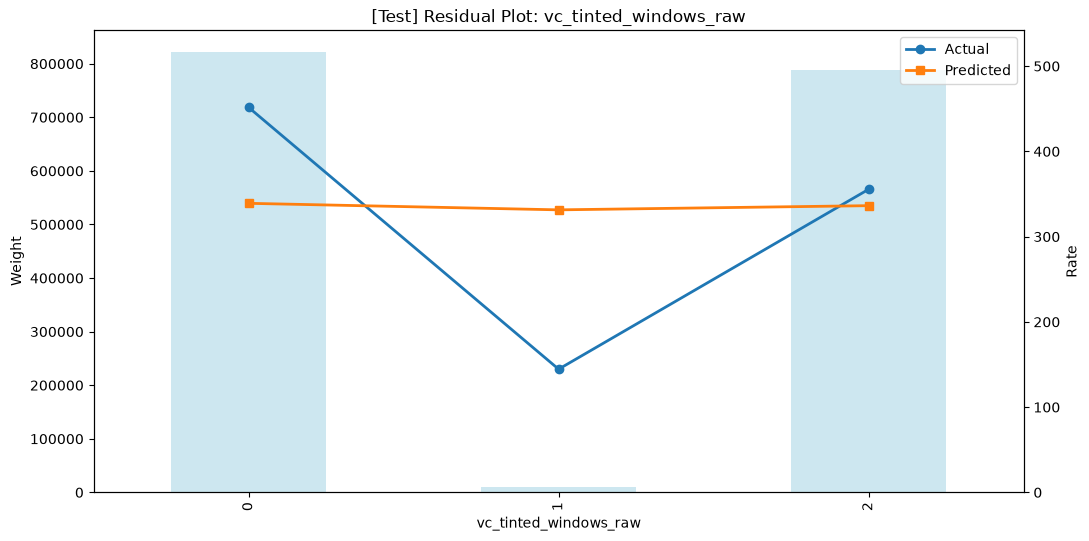

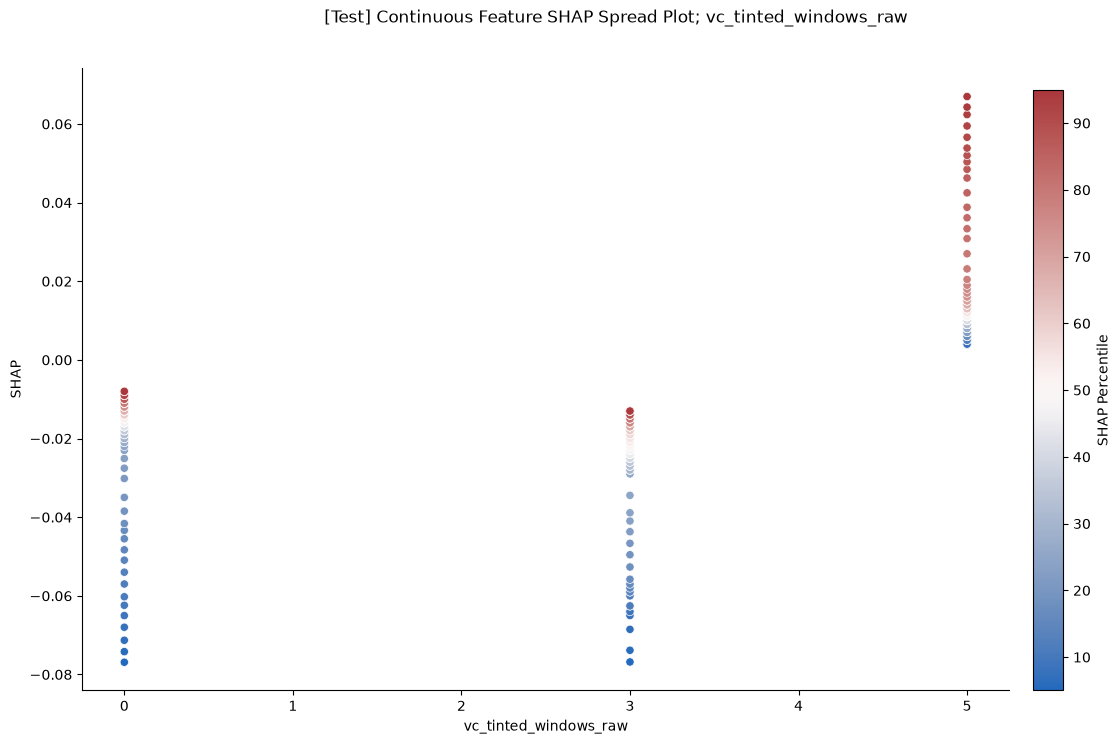


FEATURE: vc_transmission_type_manual_ind


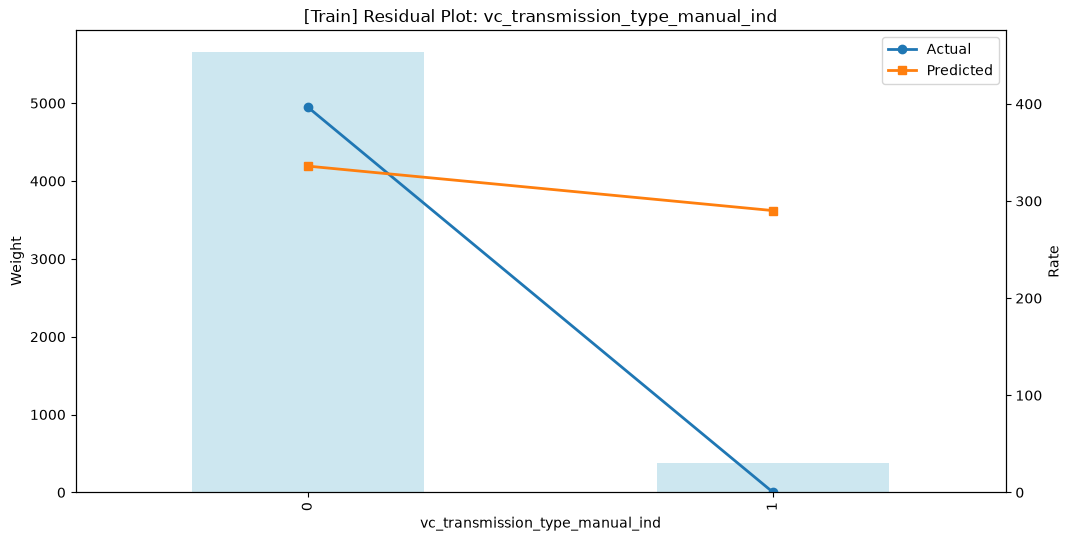

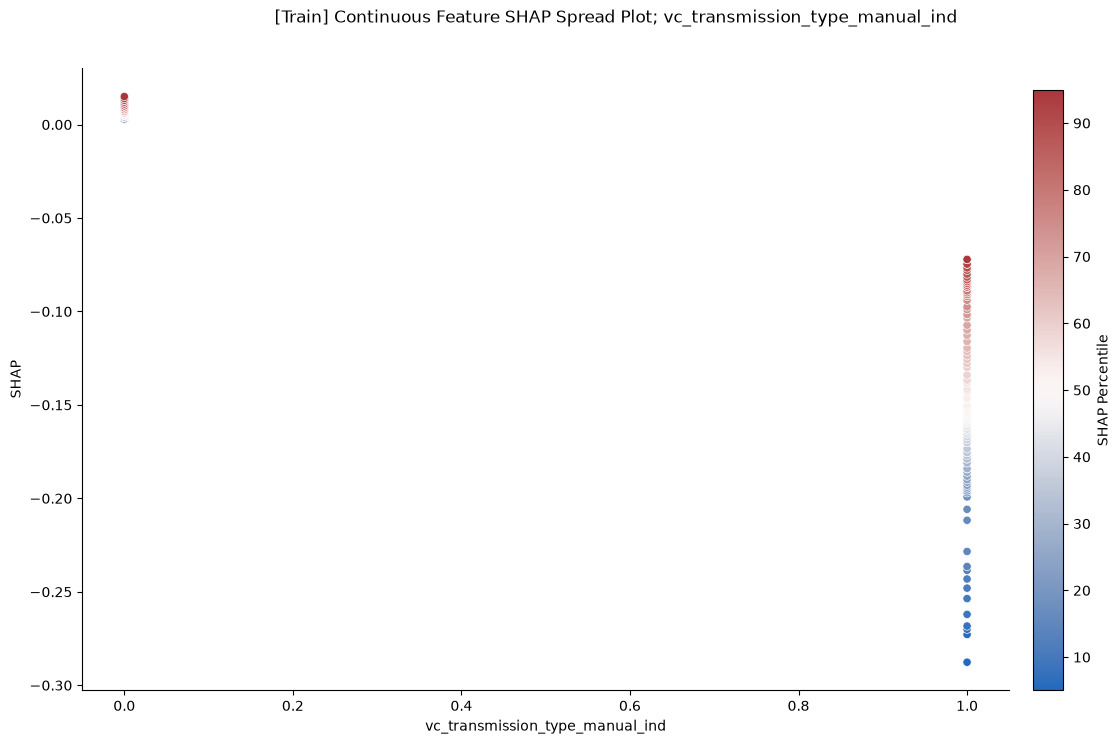

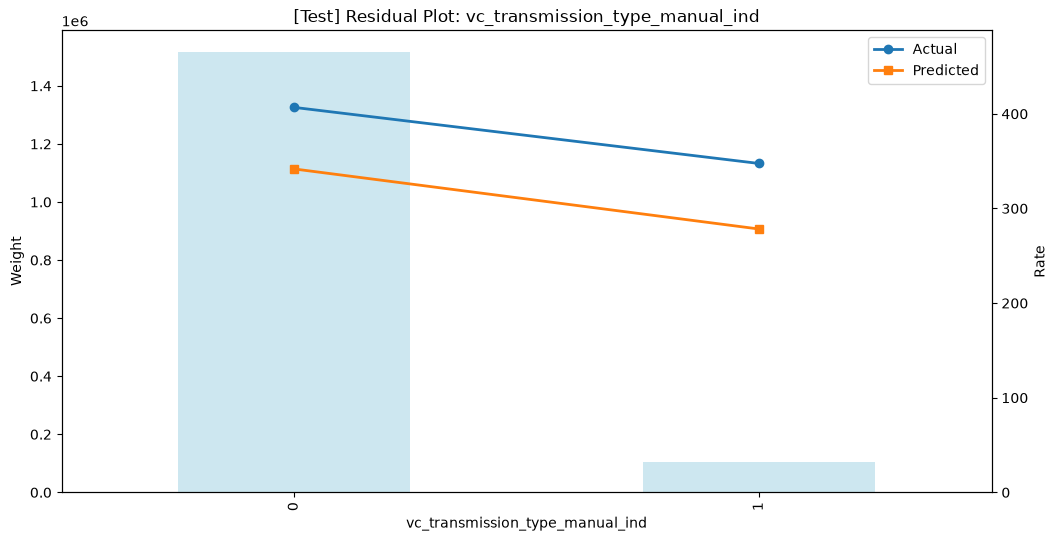

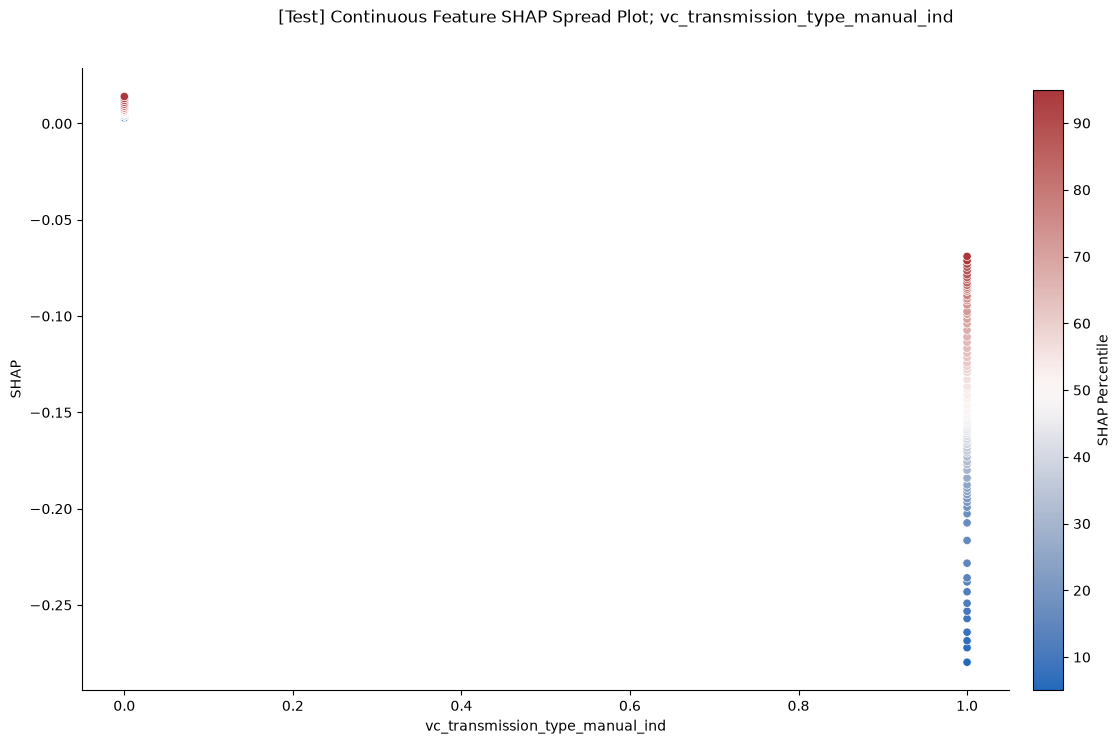


FEATURE: vc_backup_camera_raw


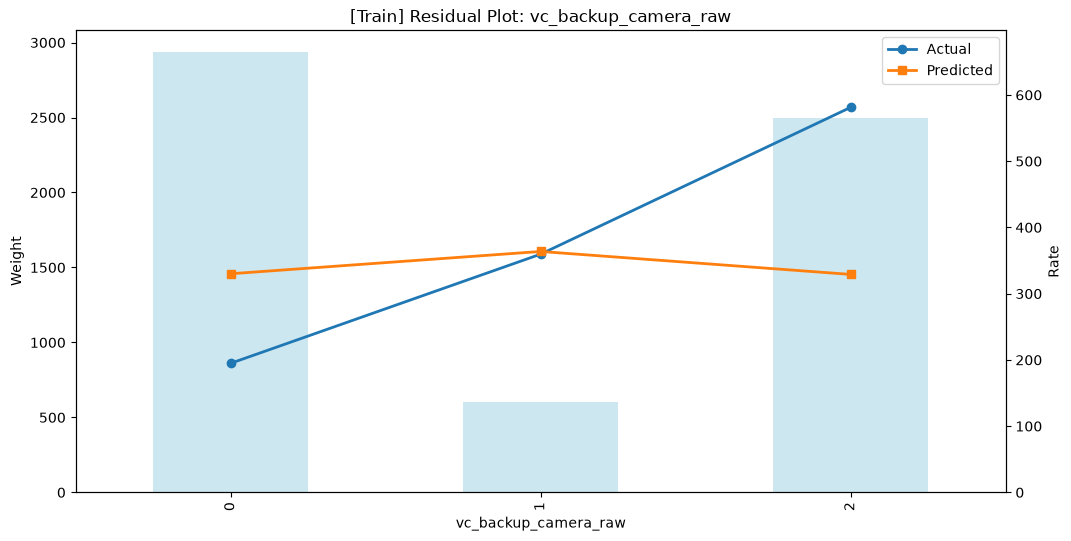

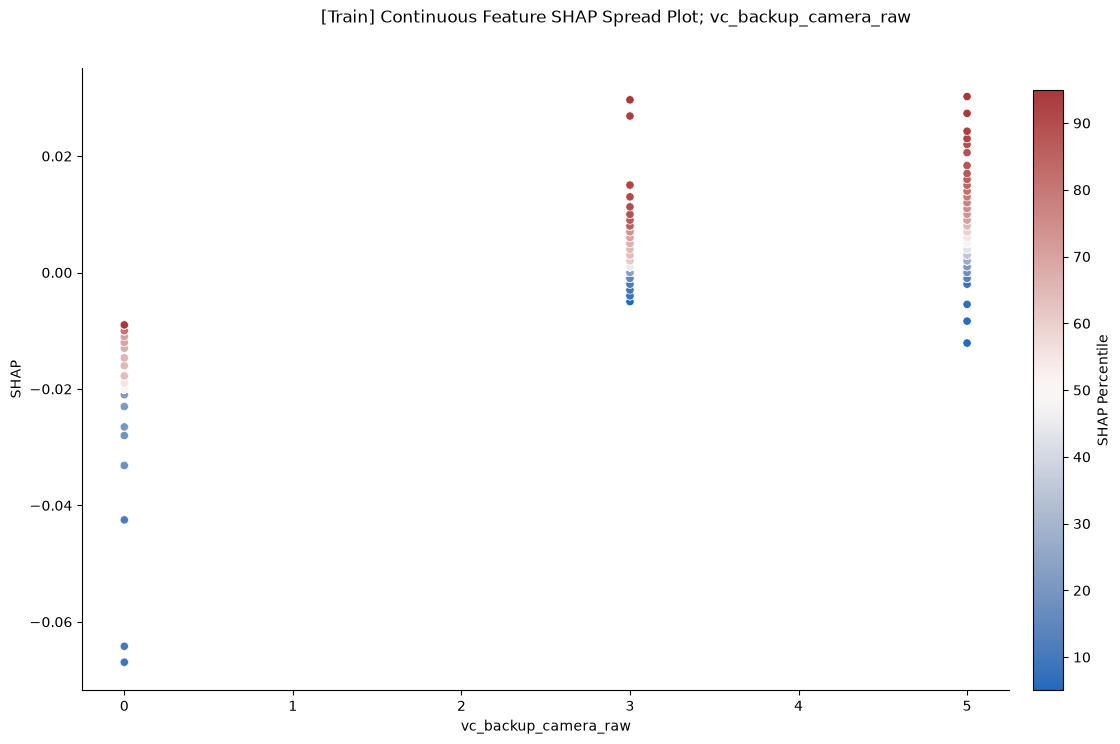

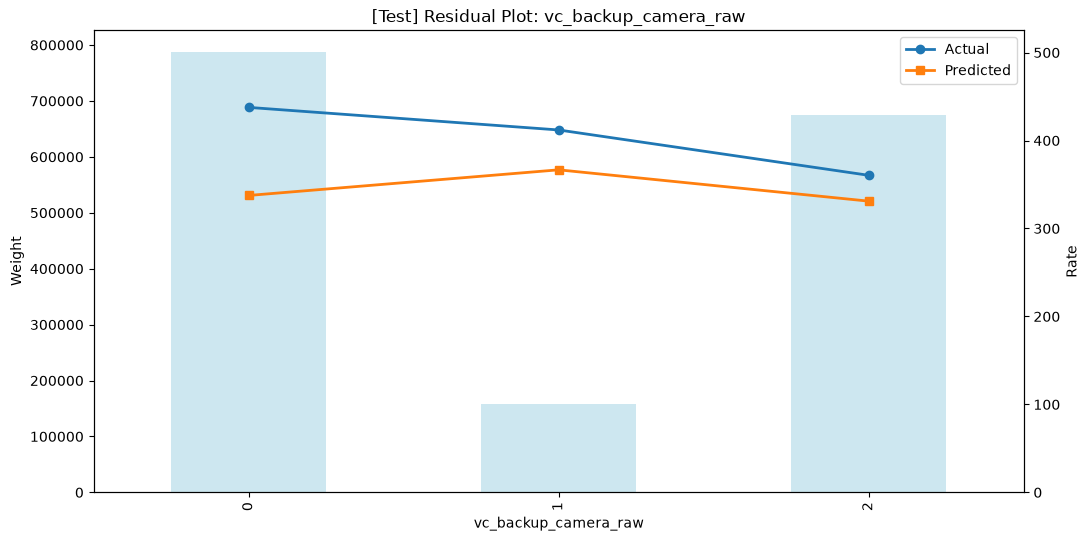

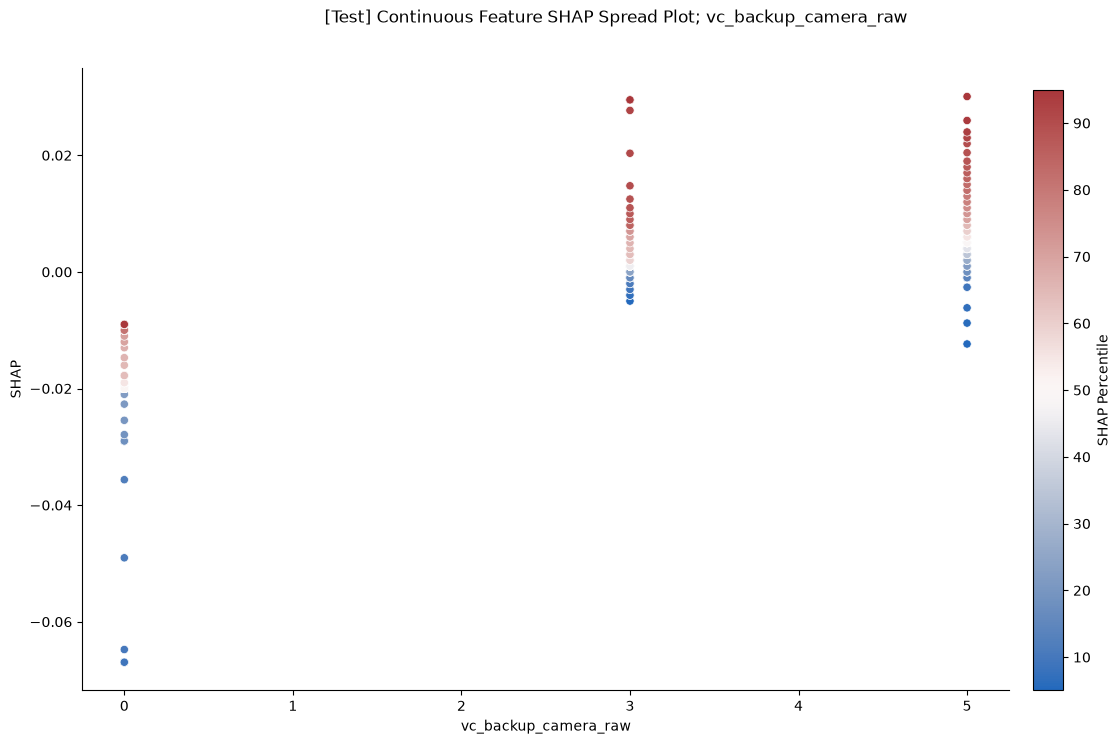


FEATURE: vc_forward_collision_warning_raw


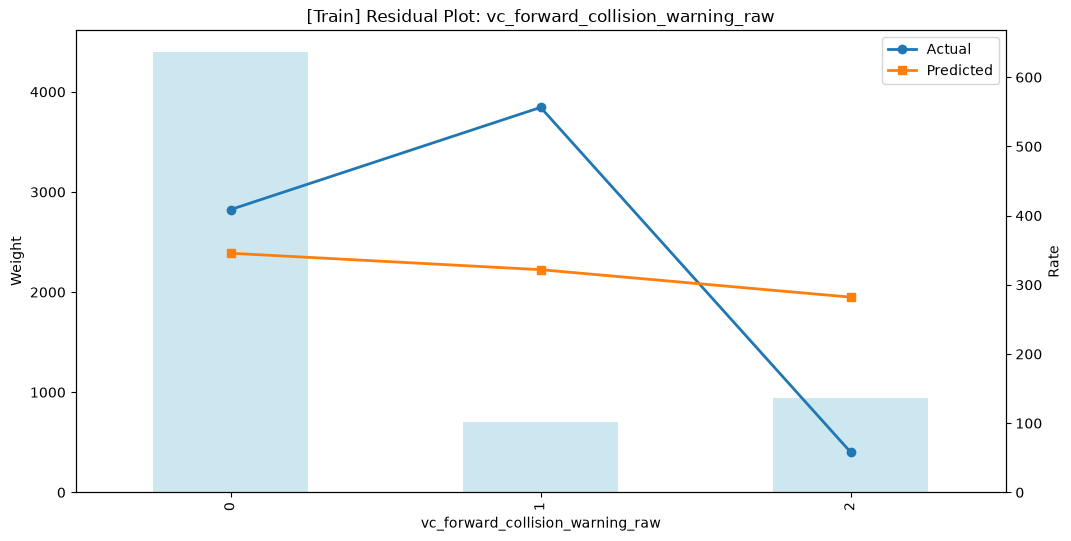

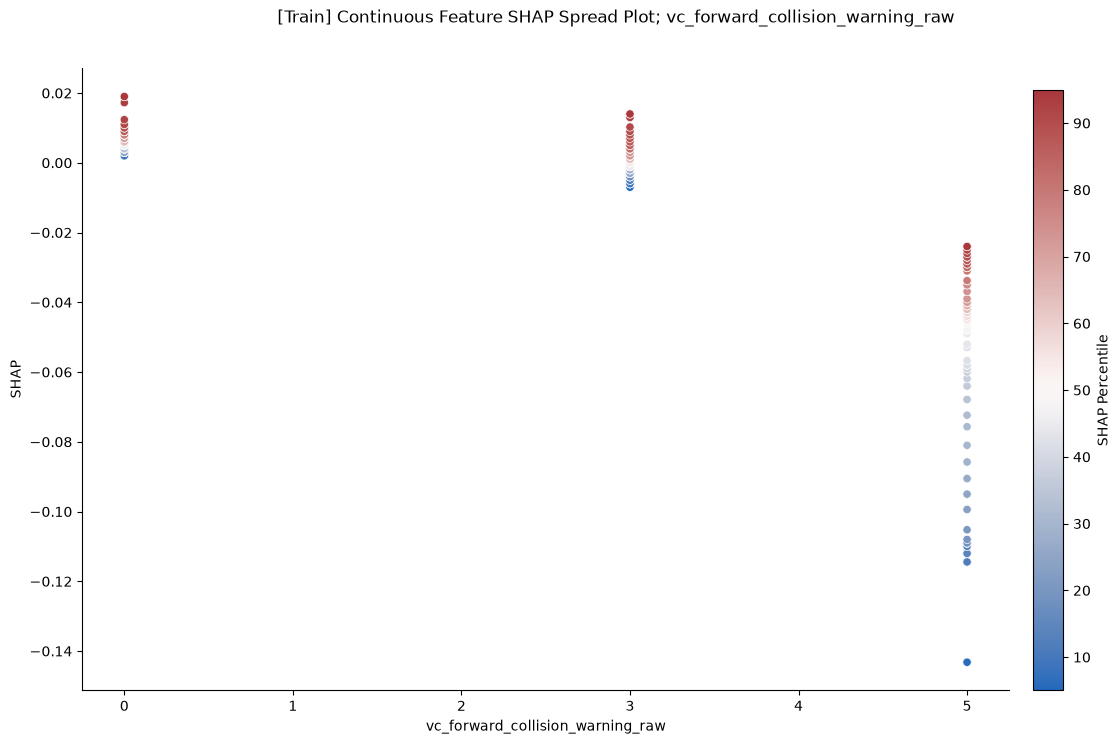

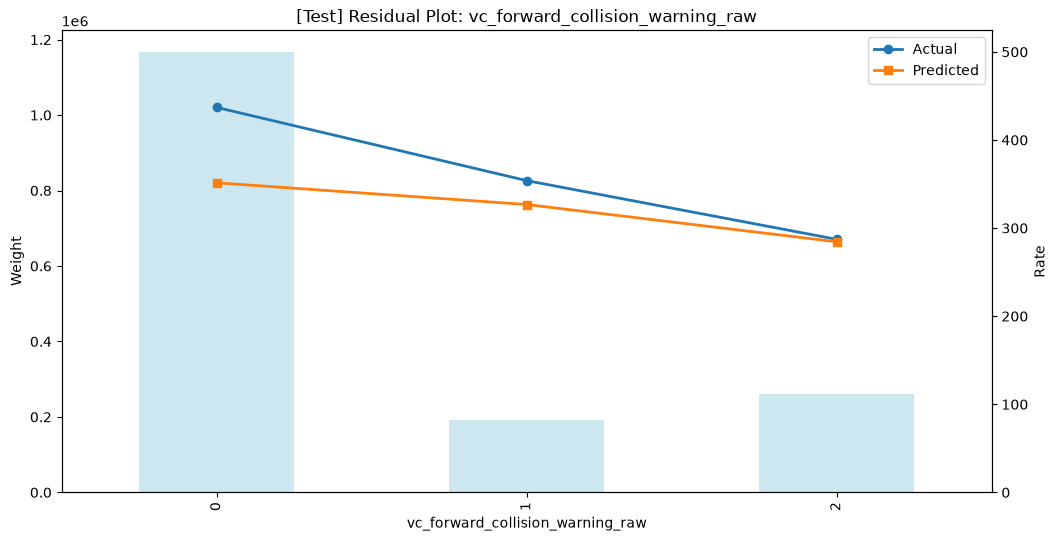

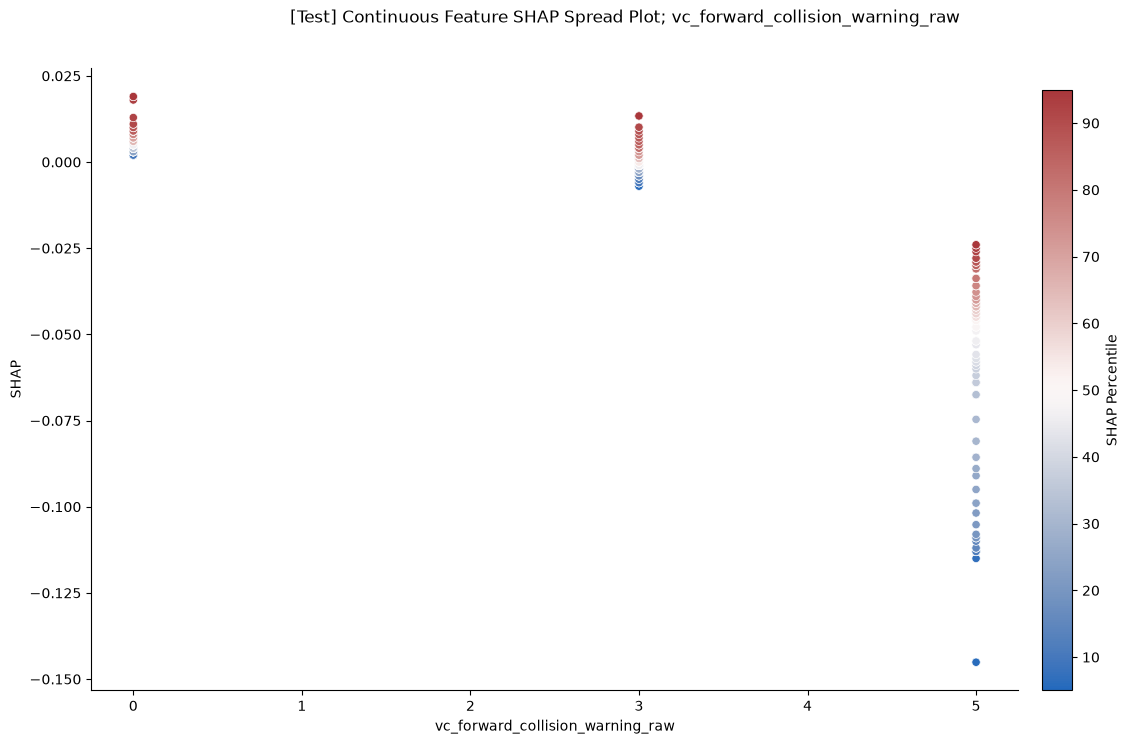


FEATURE: vc_blind_spot_warning_raw


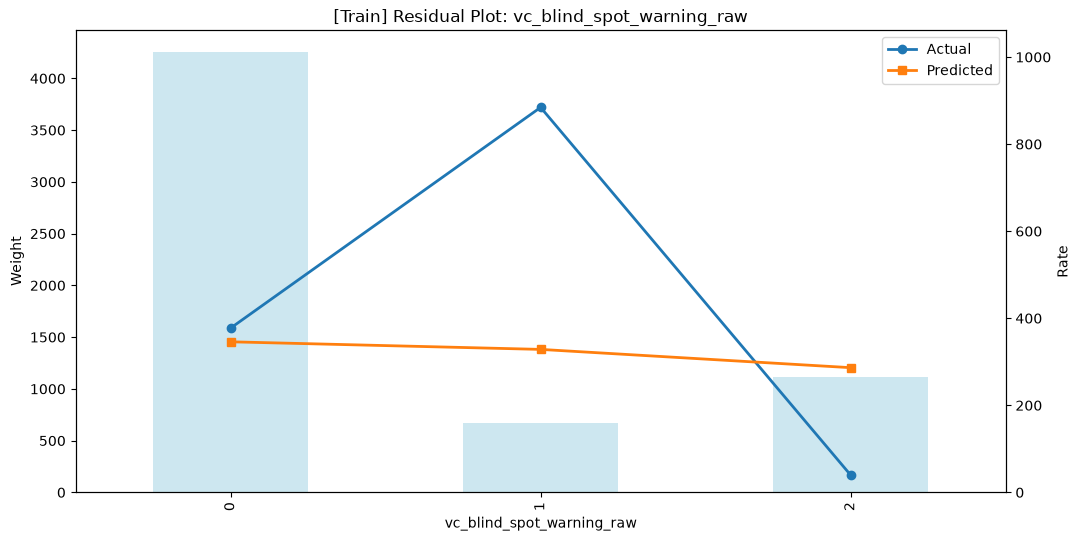

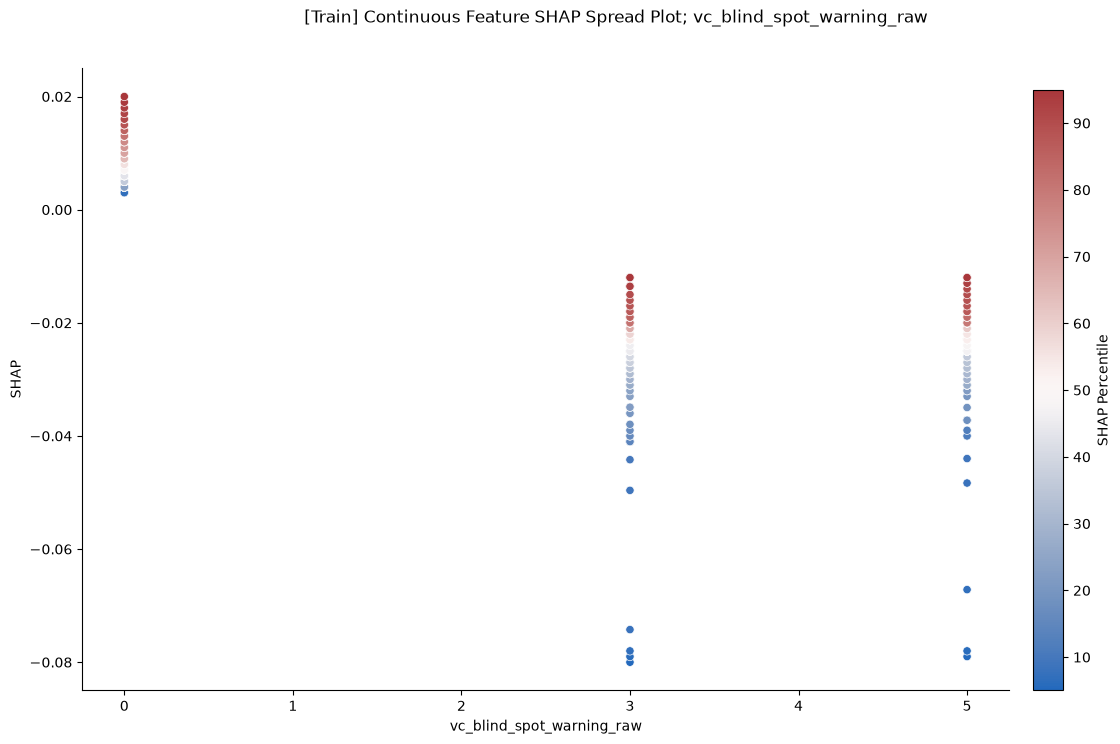

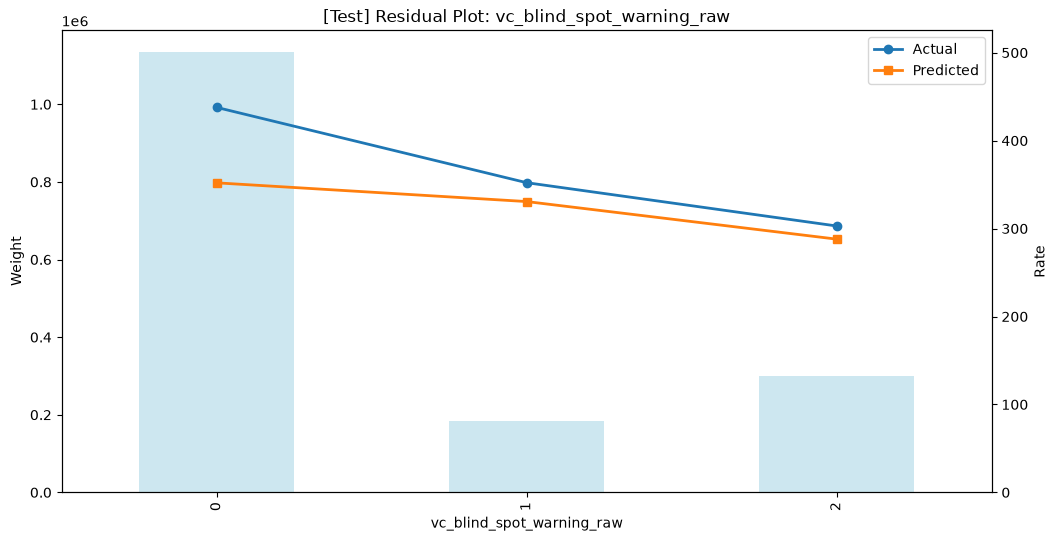

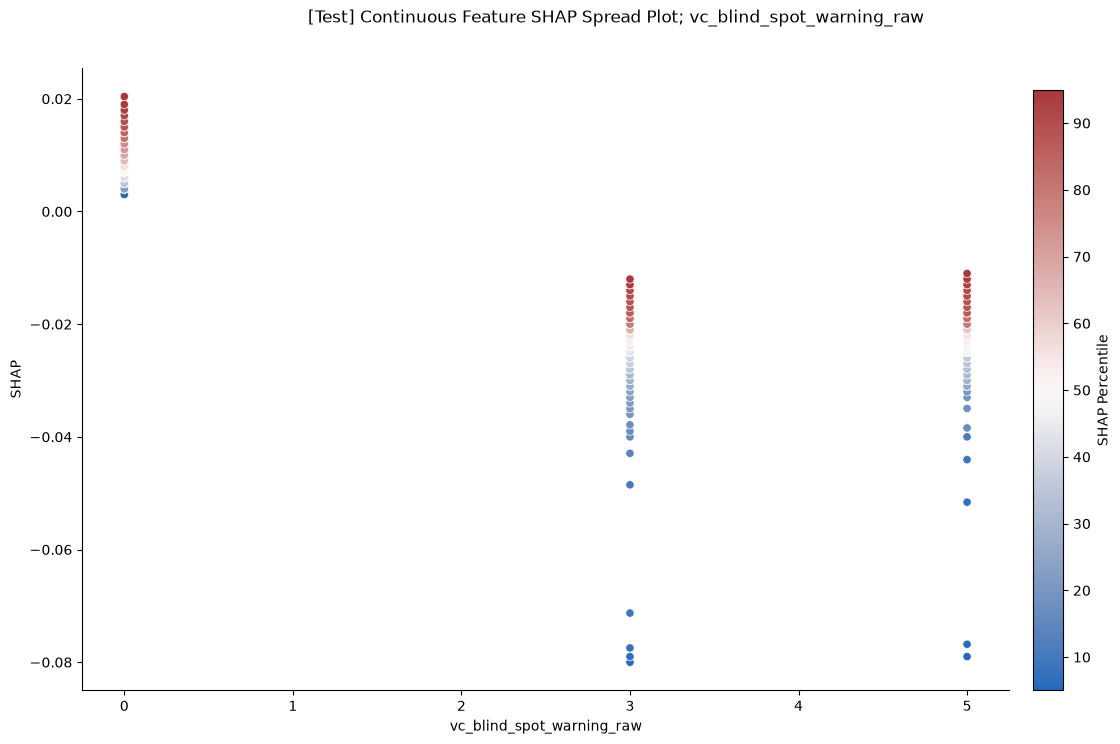


FEATURE: veh_use_business_ind


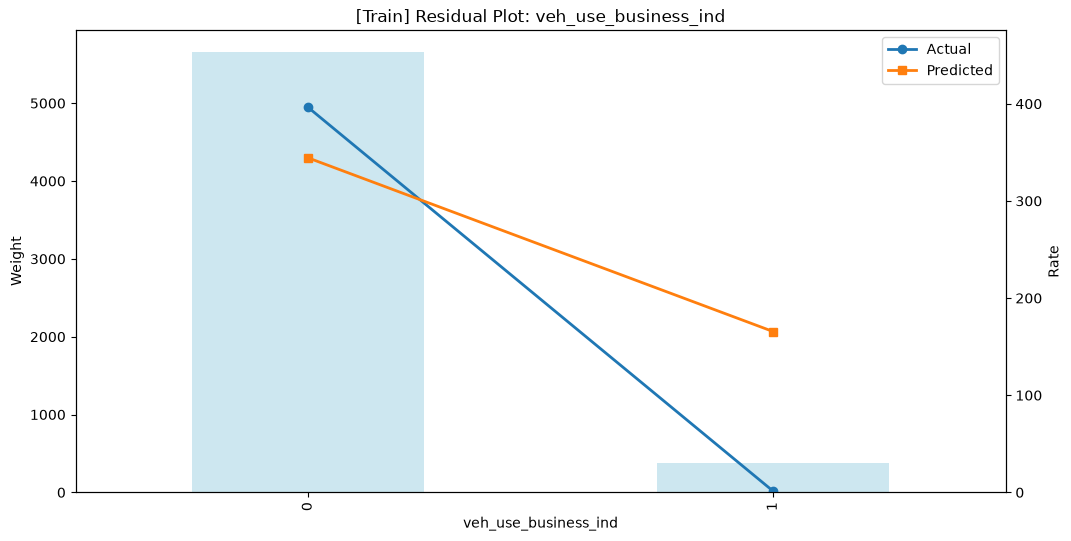

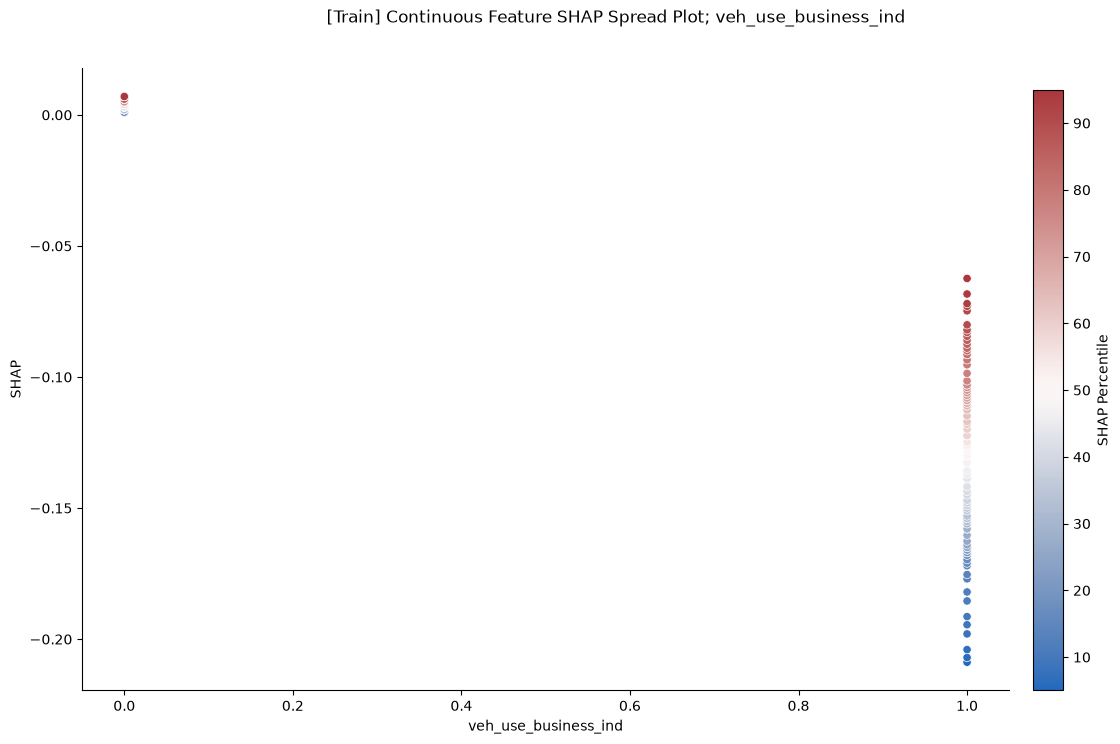

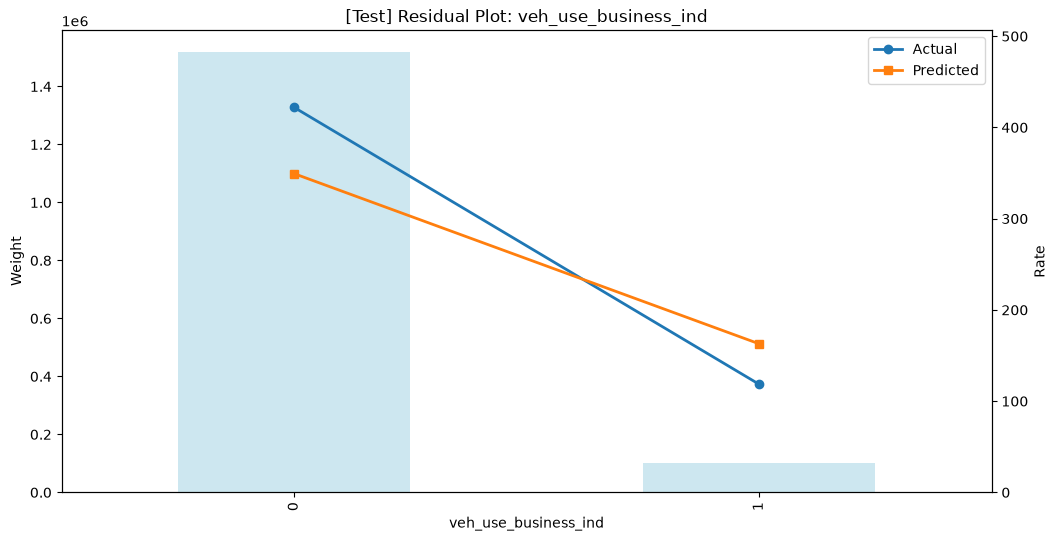

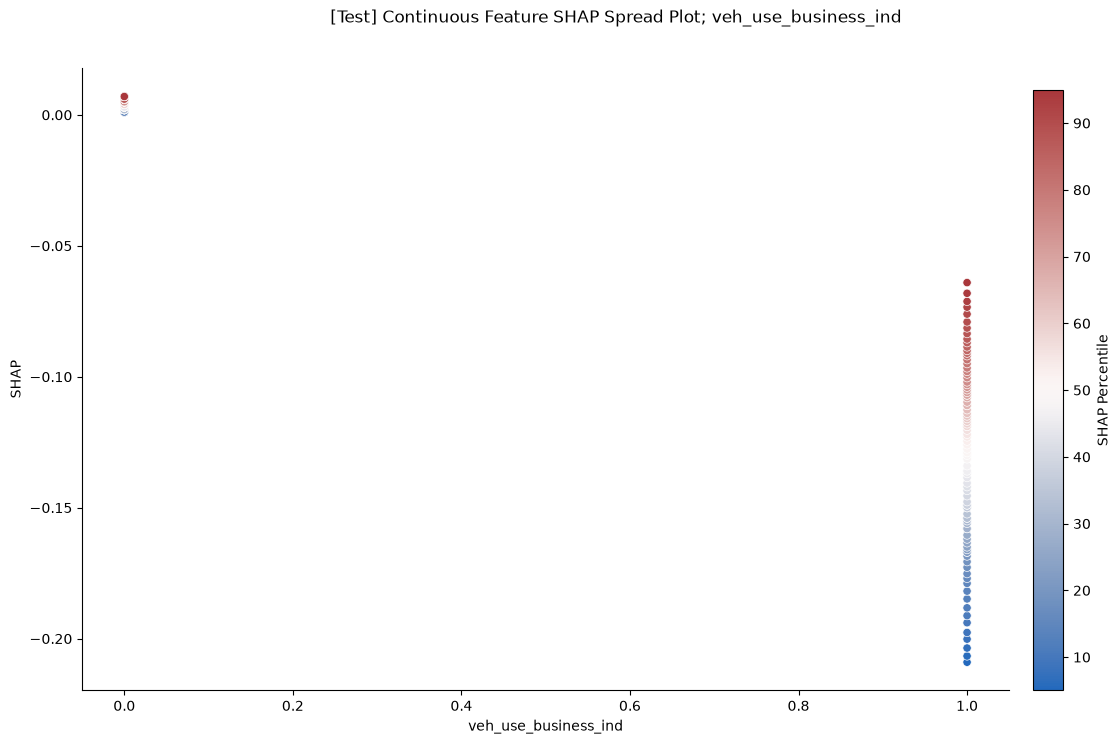


FEATURE: vc_hill_ascent_assist_raw


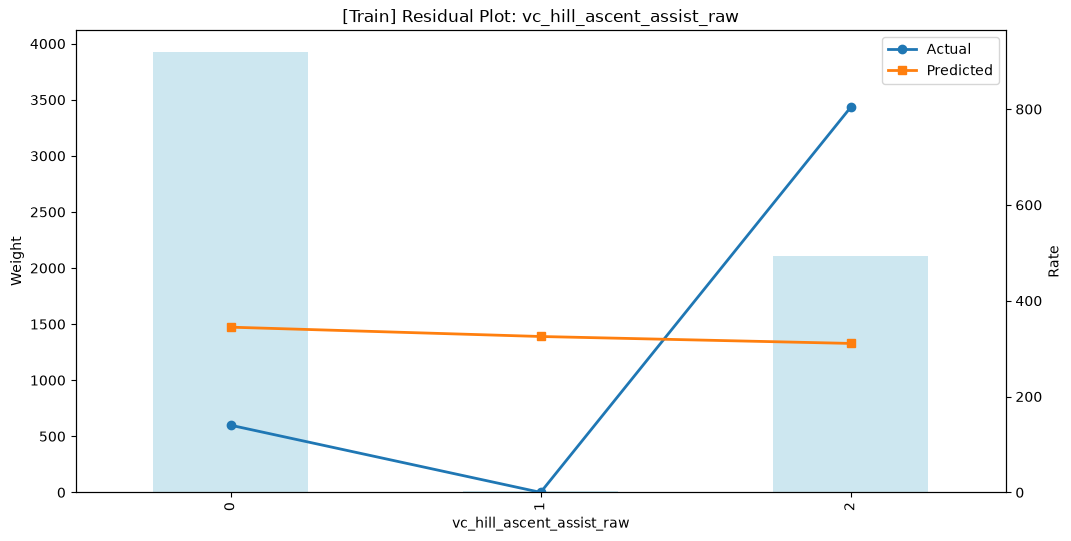

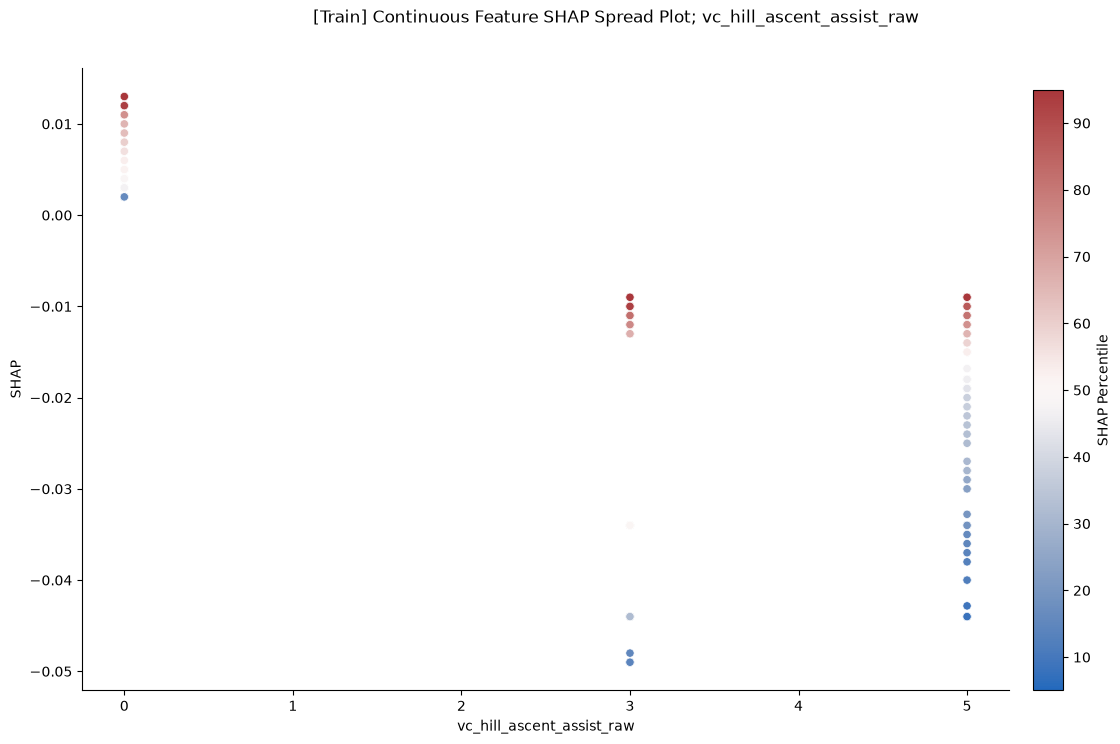

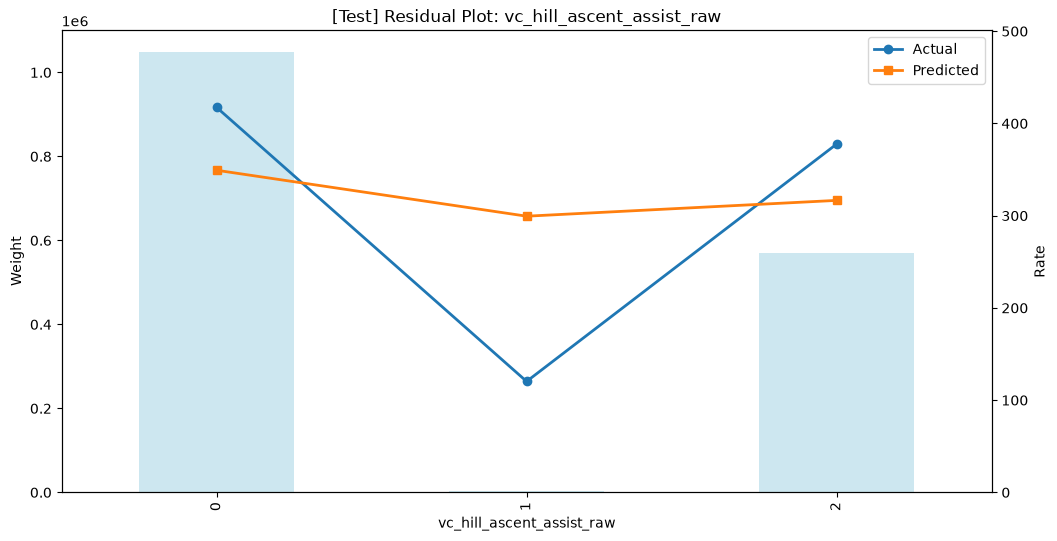

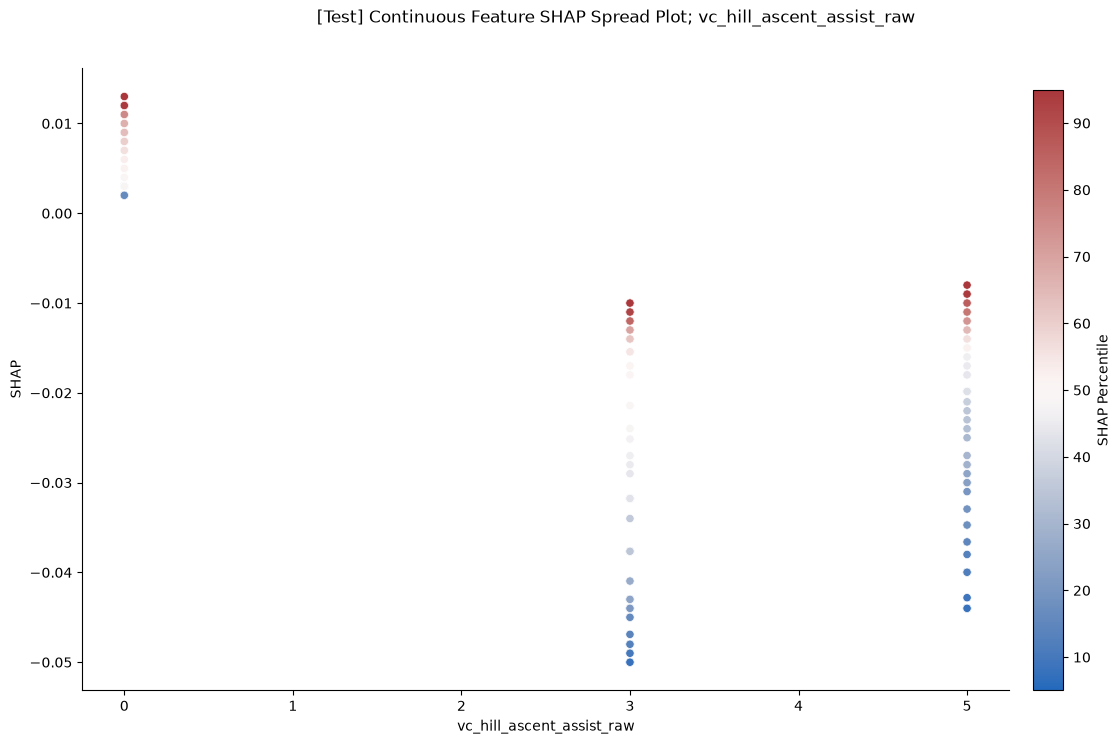


FEATURE: vc_adaptive_cruise_control_raw


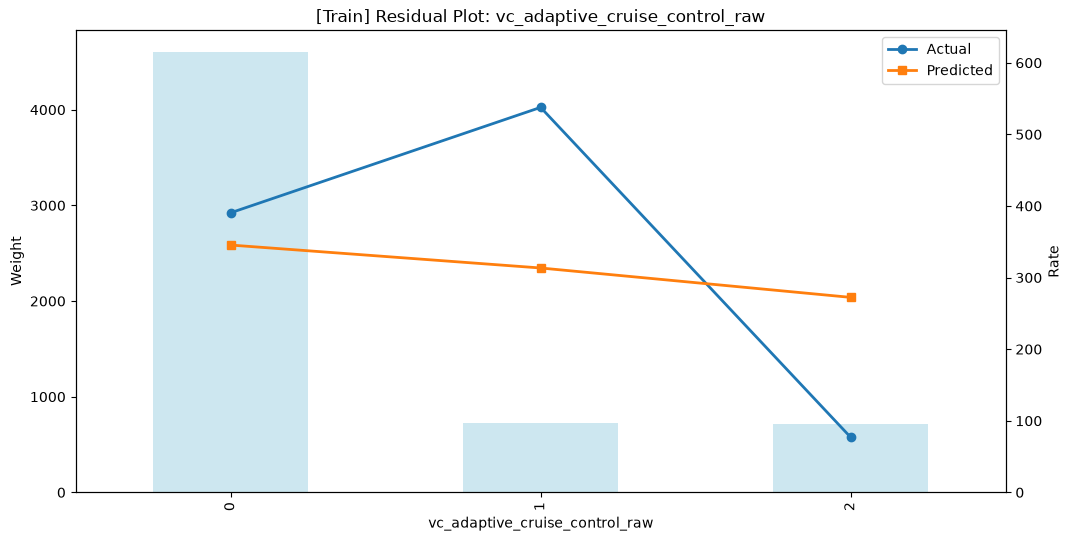

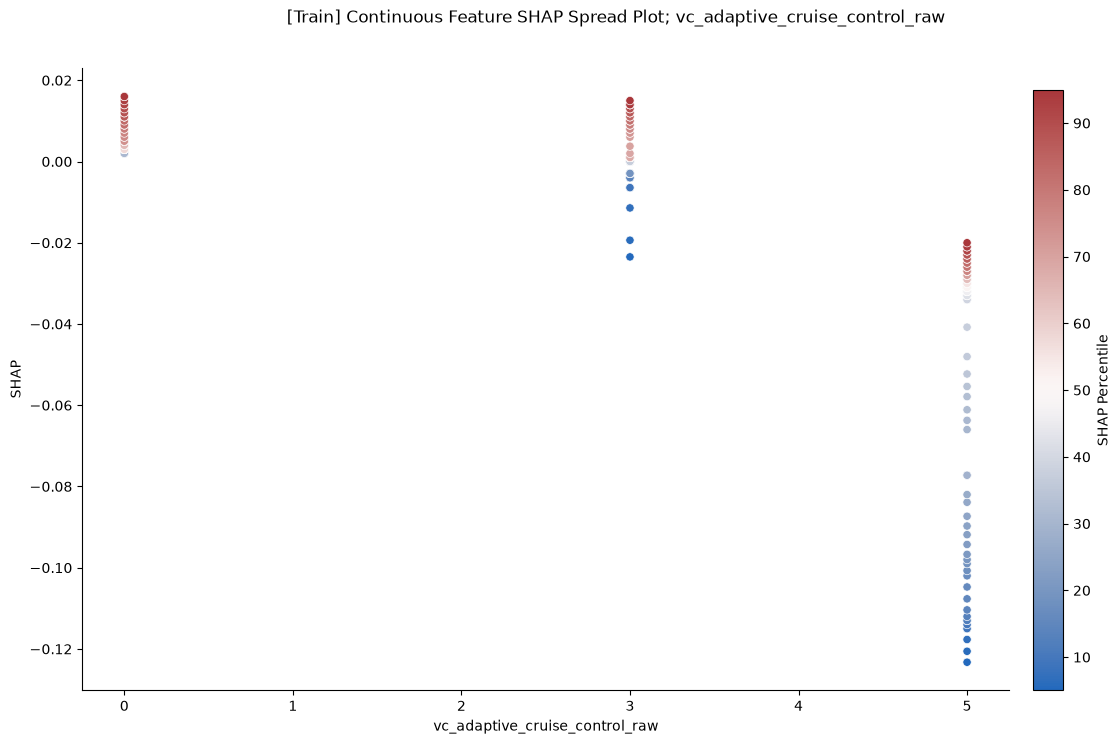

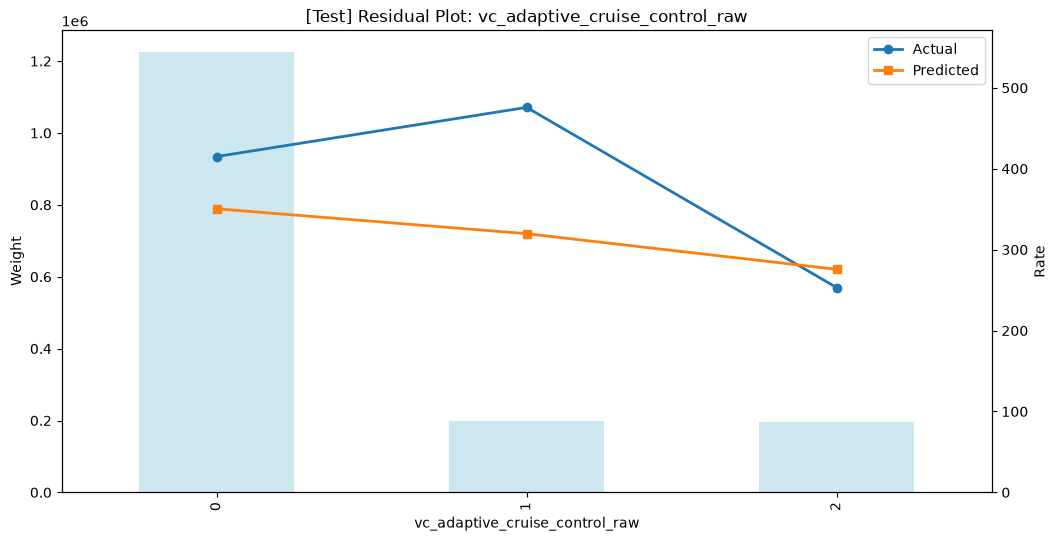

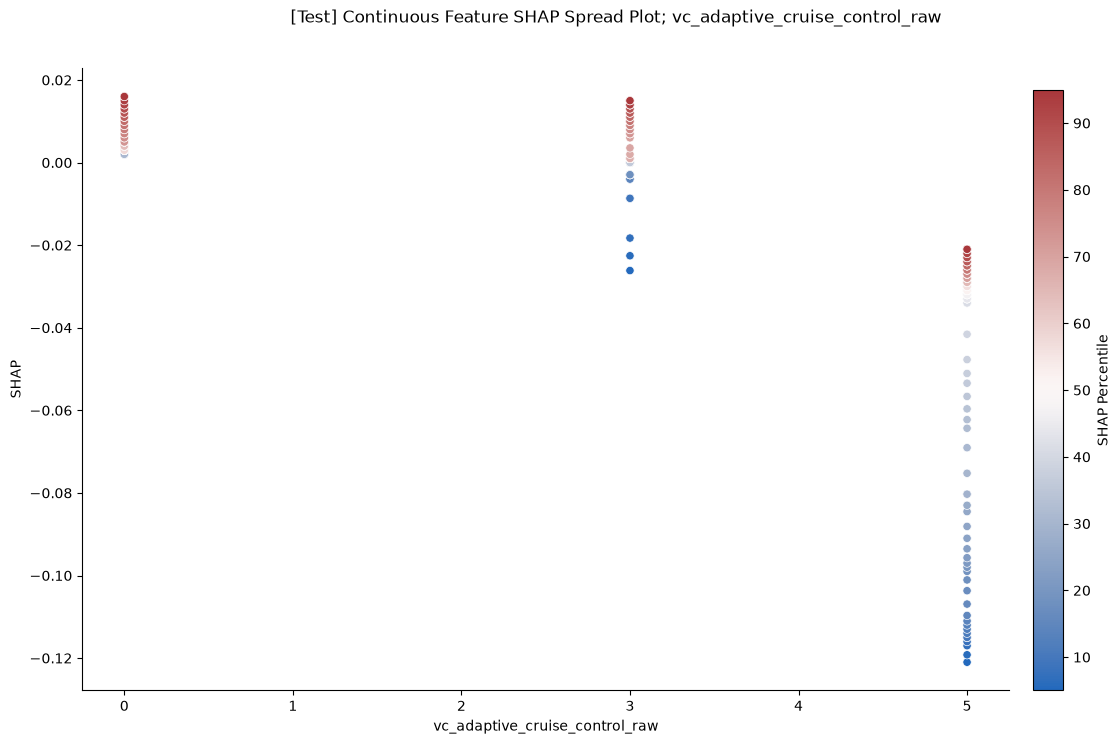


FEATURE: vc_touch_screen_raw


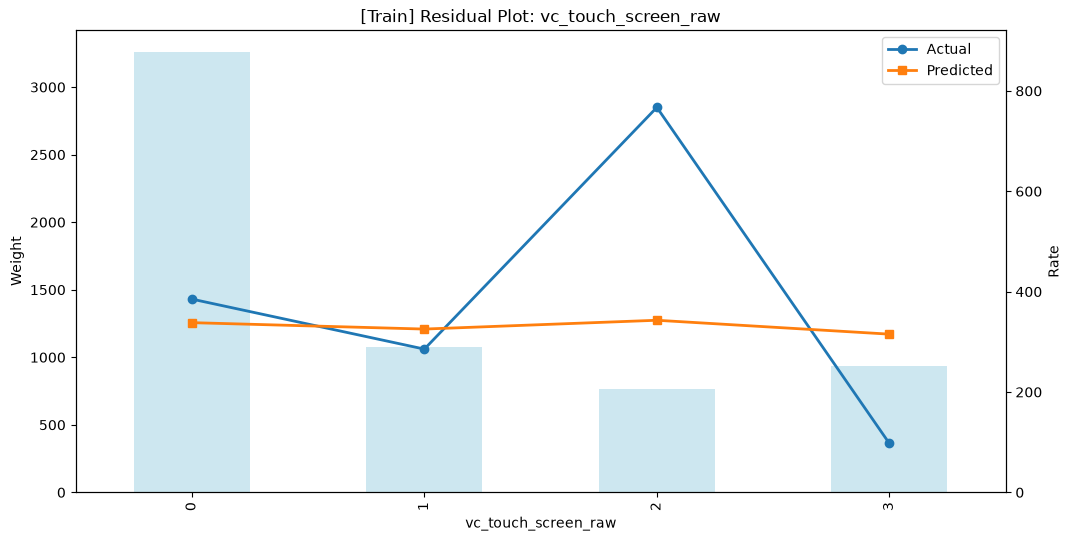

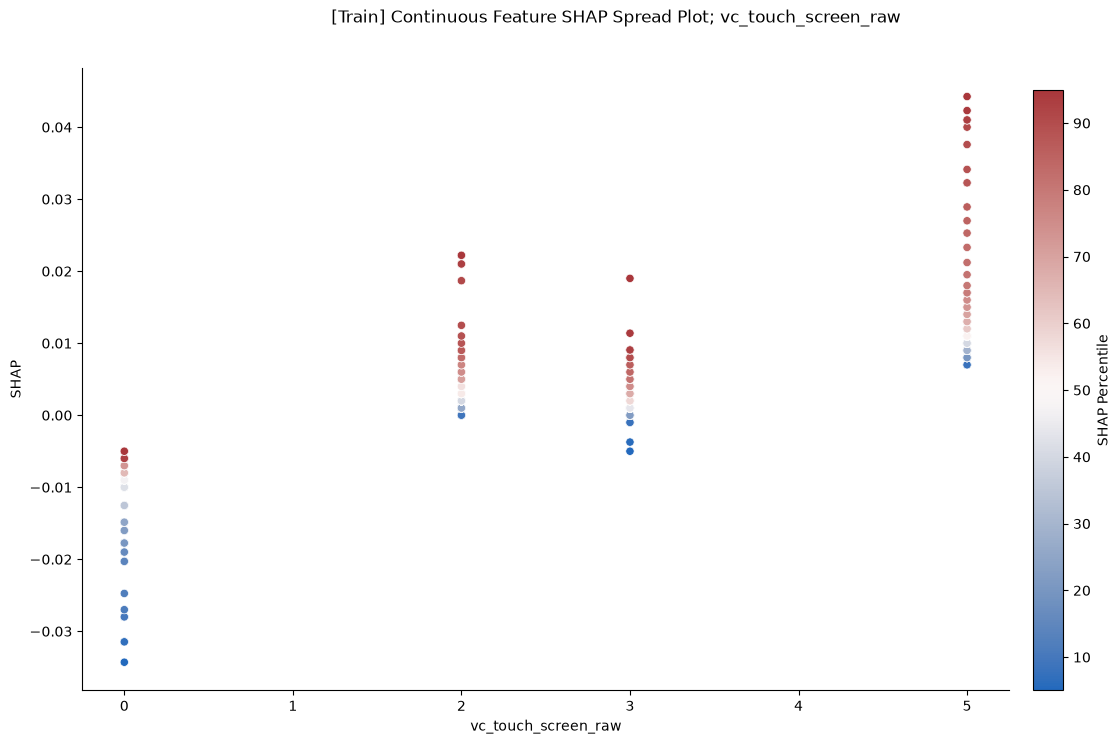

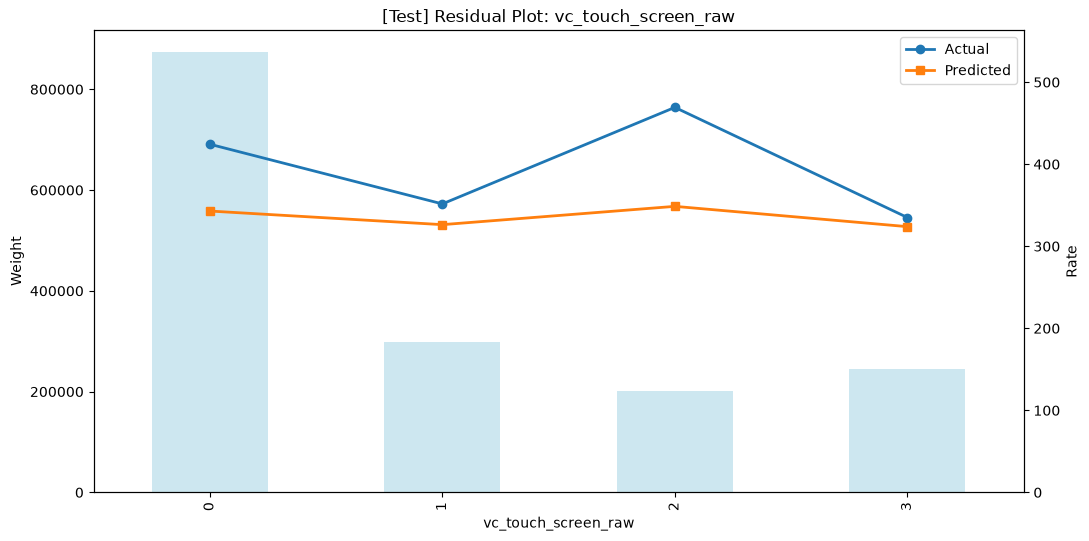

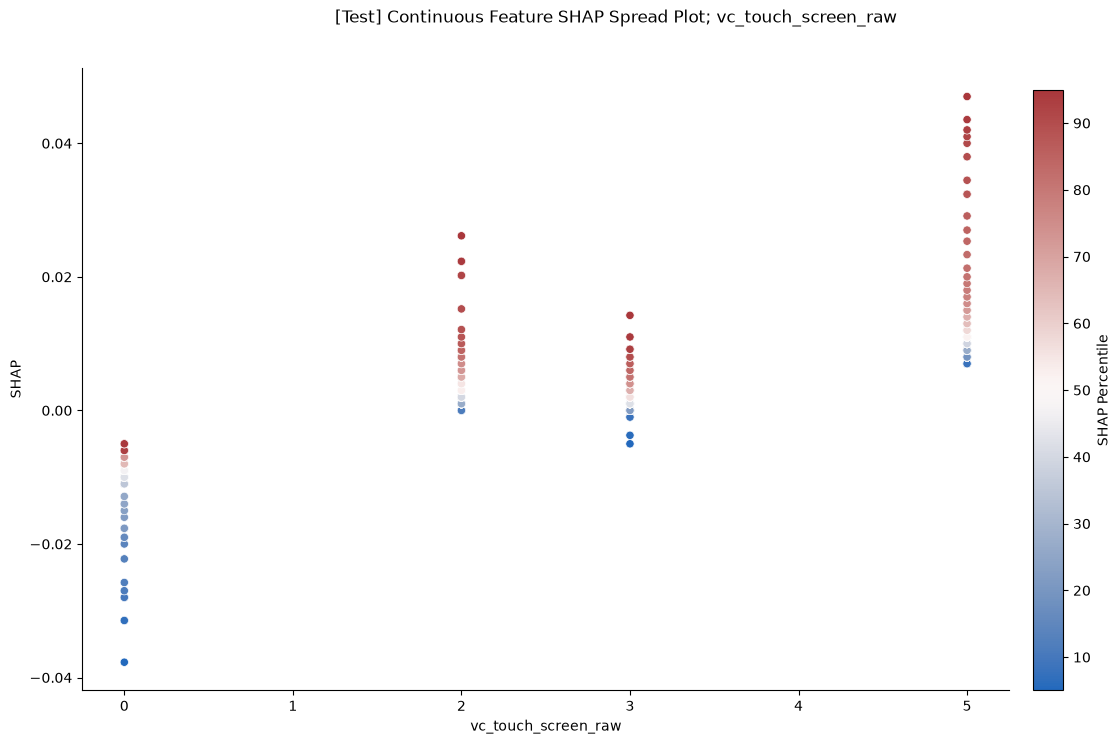


FEATURE: multi_pol_yes_cal


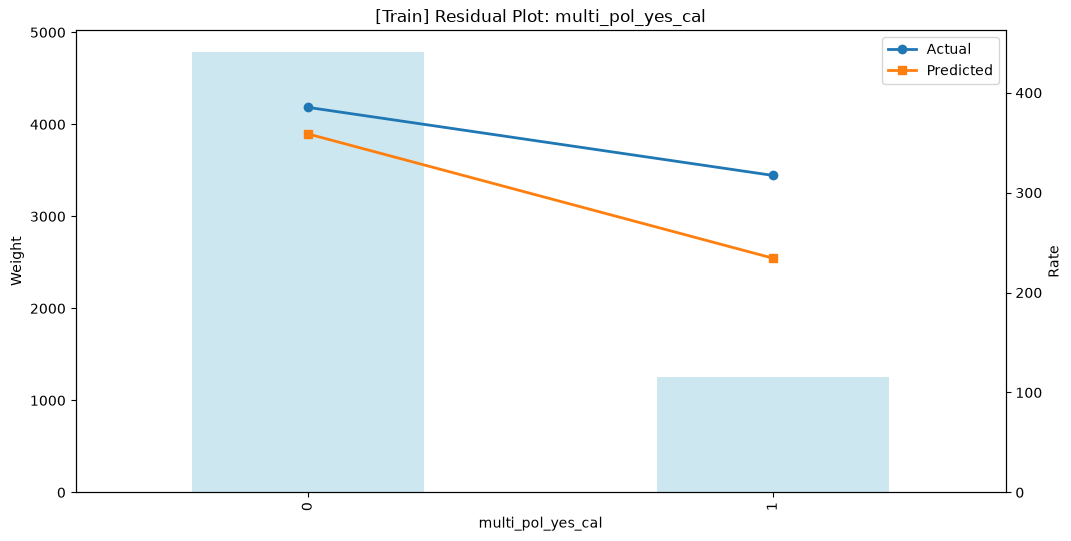

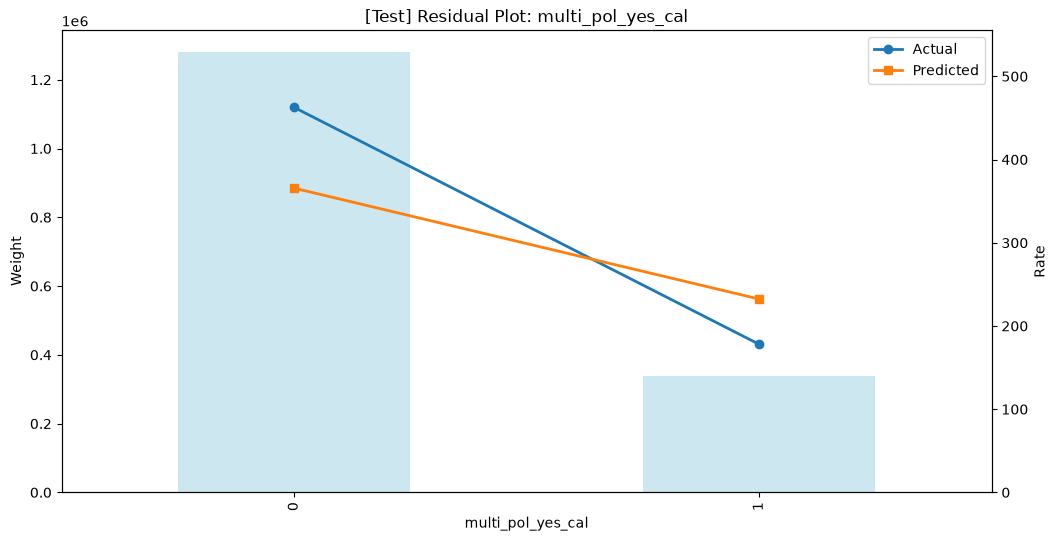


FEATURE: vc_wipers_automatic_raw


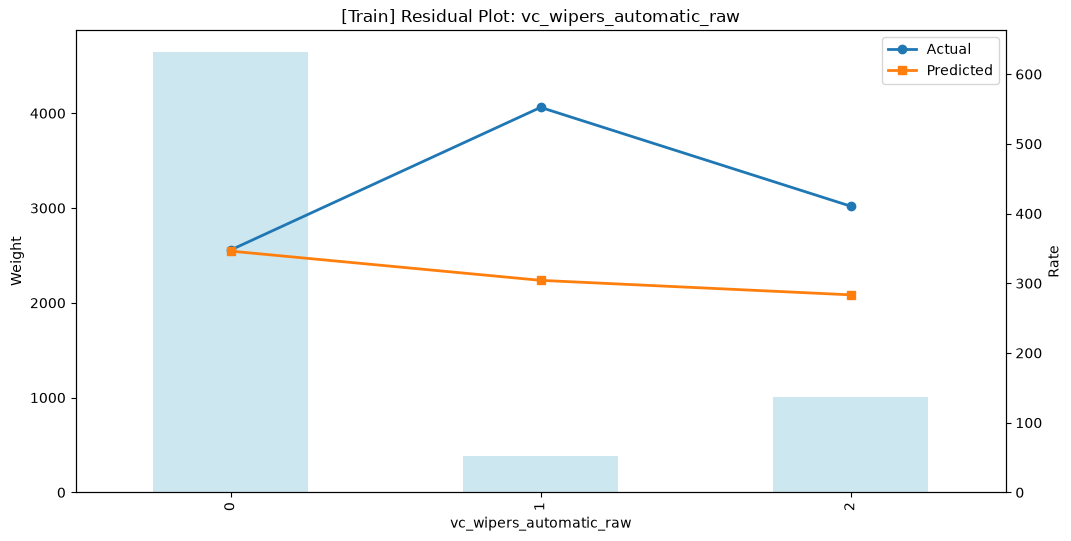

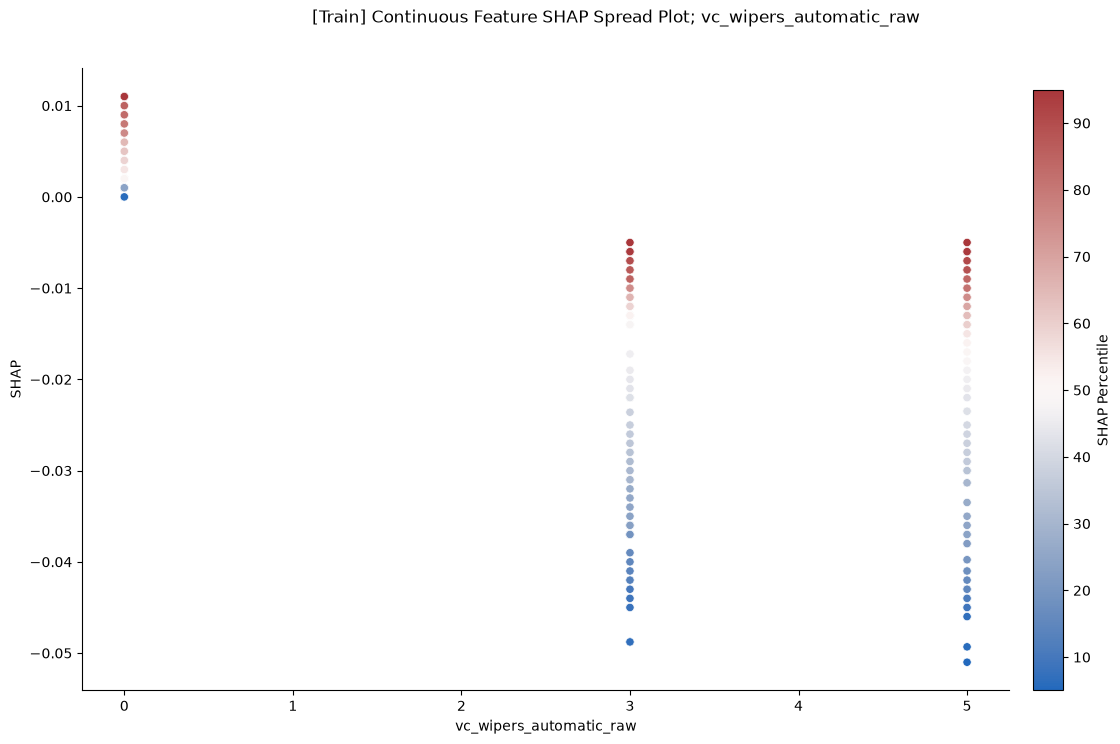

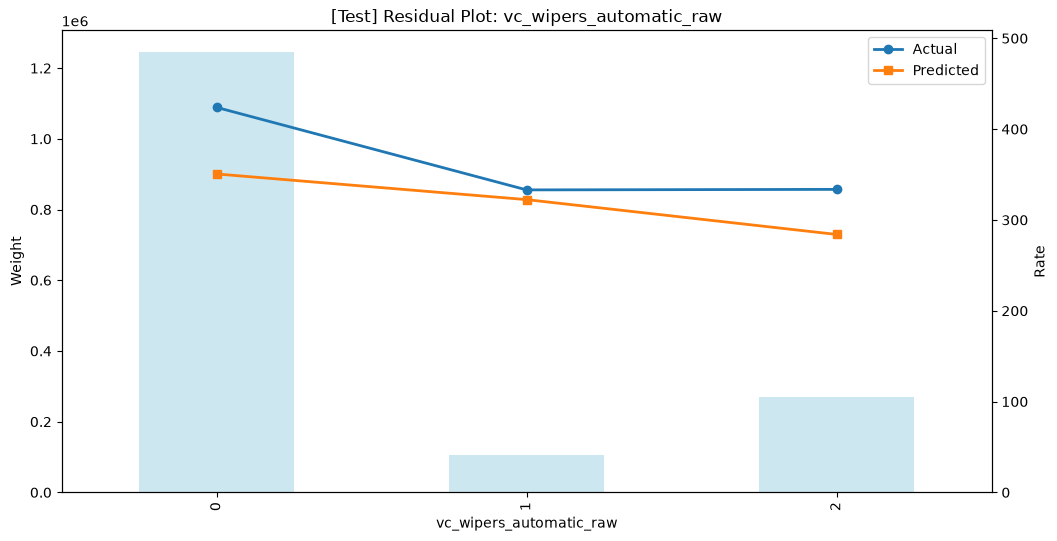

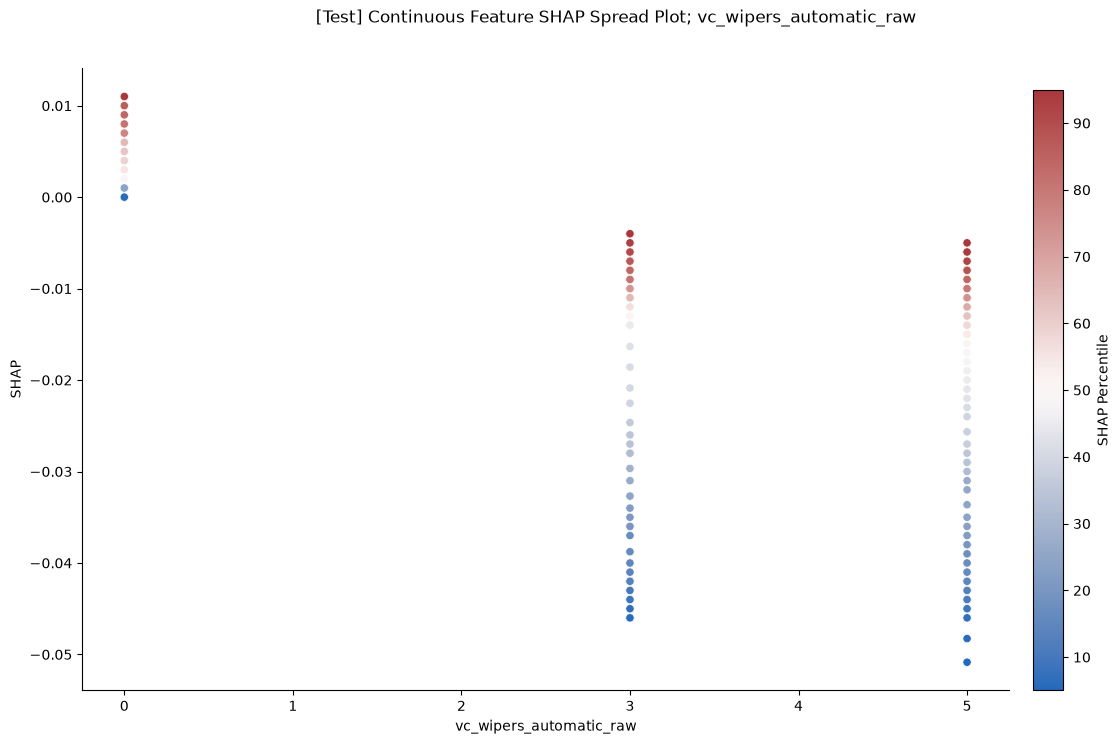


FEATURE: gender_male_ind


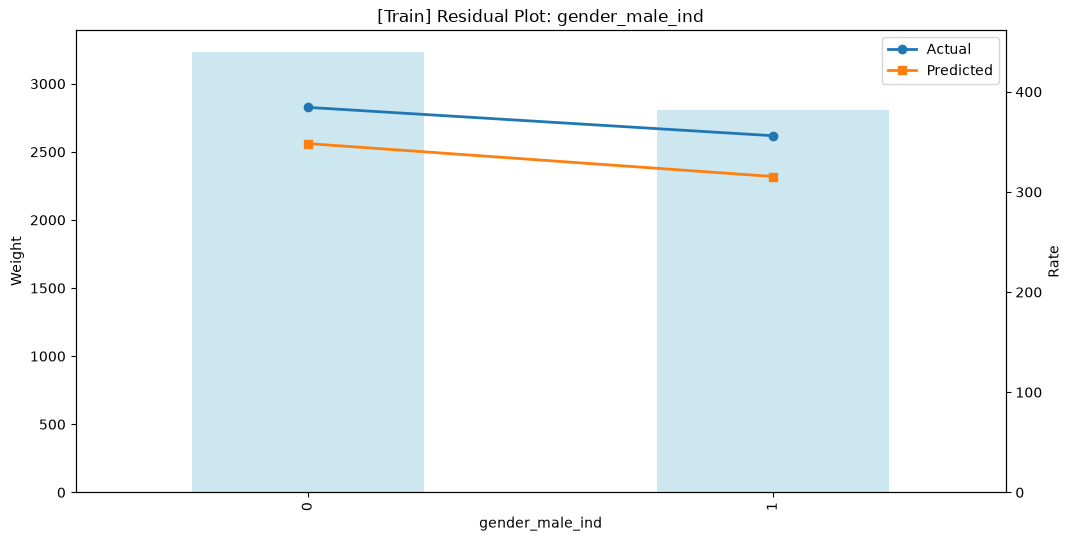

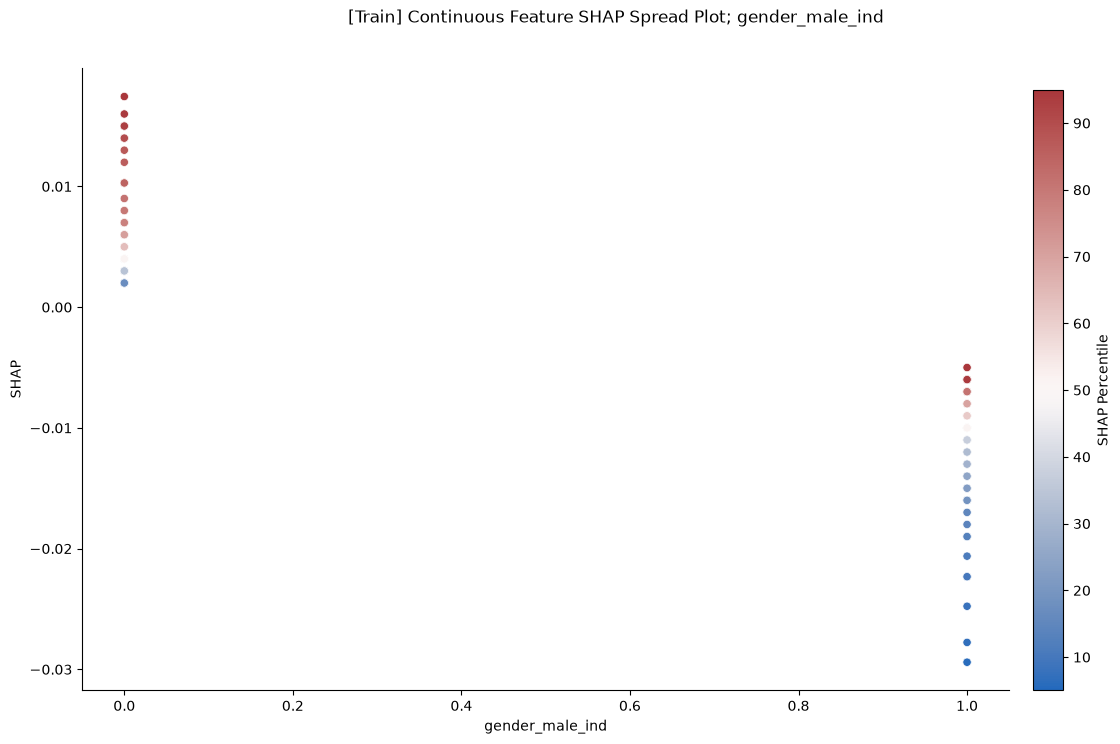

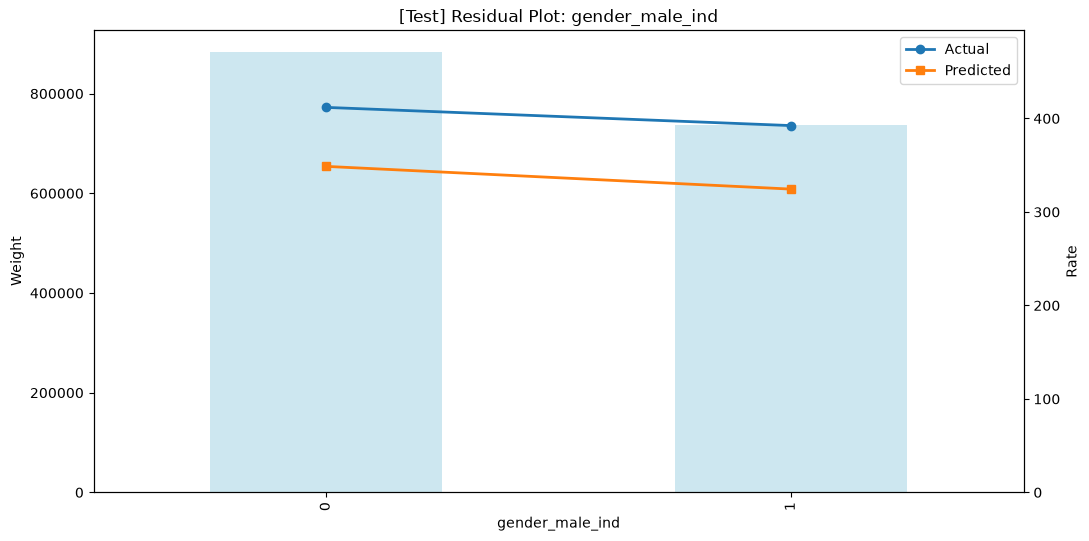

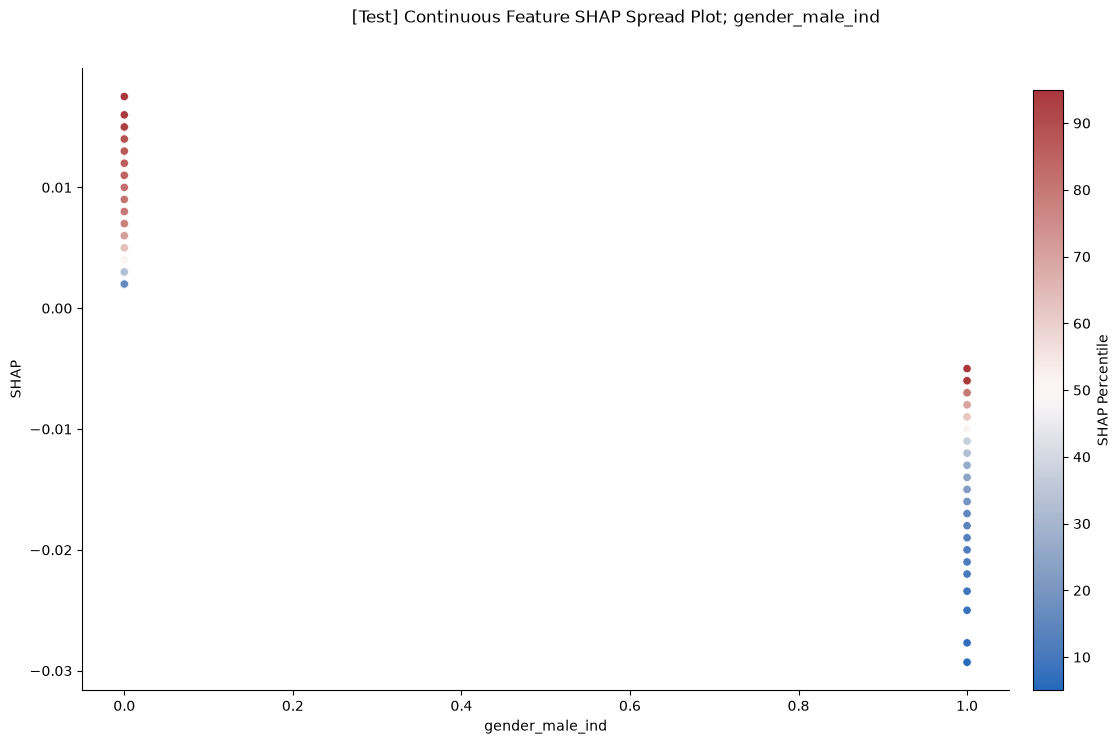


FEATURE: vc_headlights_auto_on_off_raw


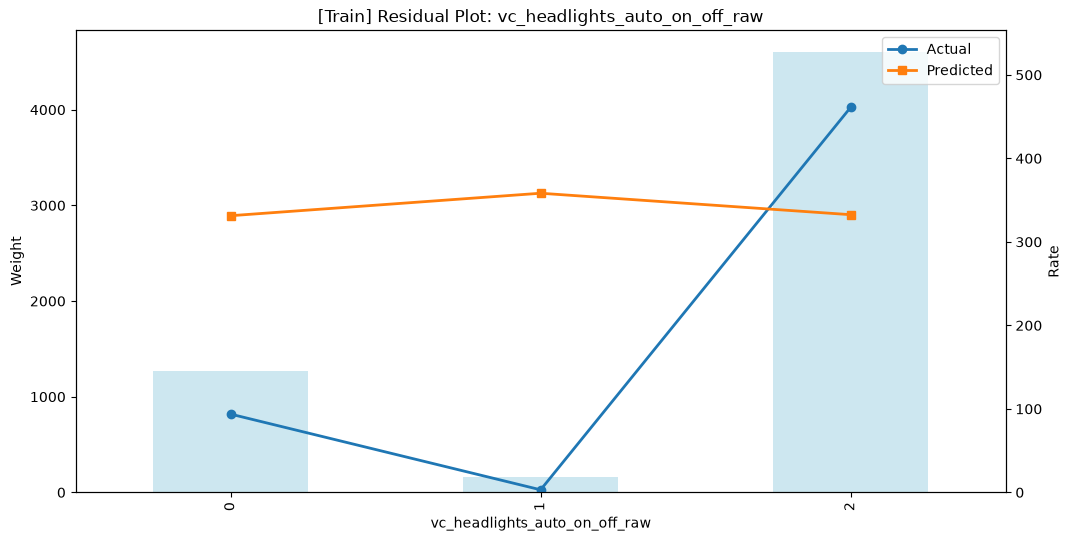

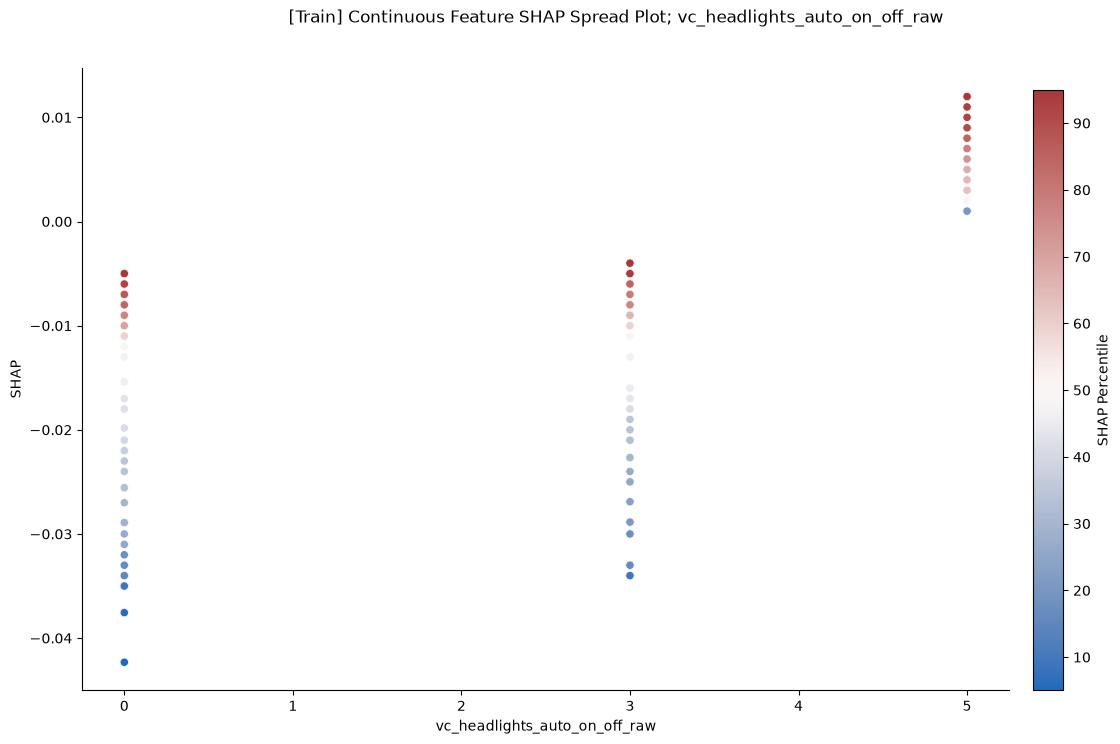

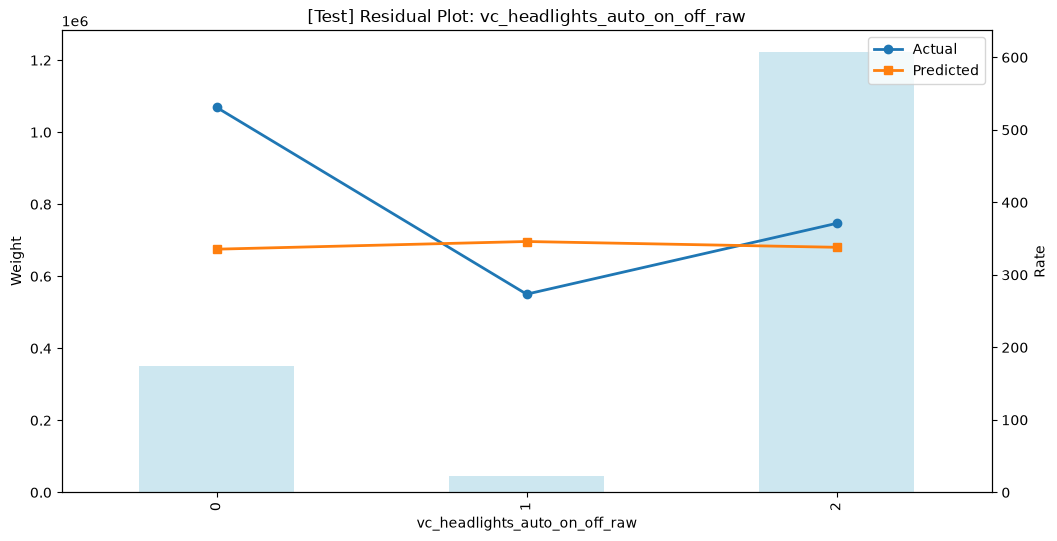

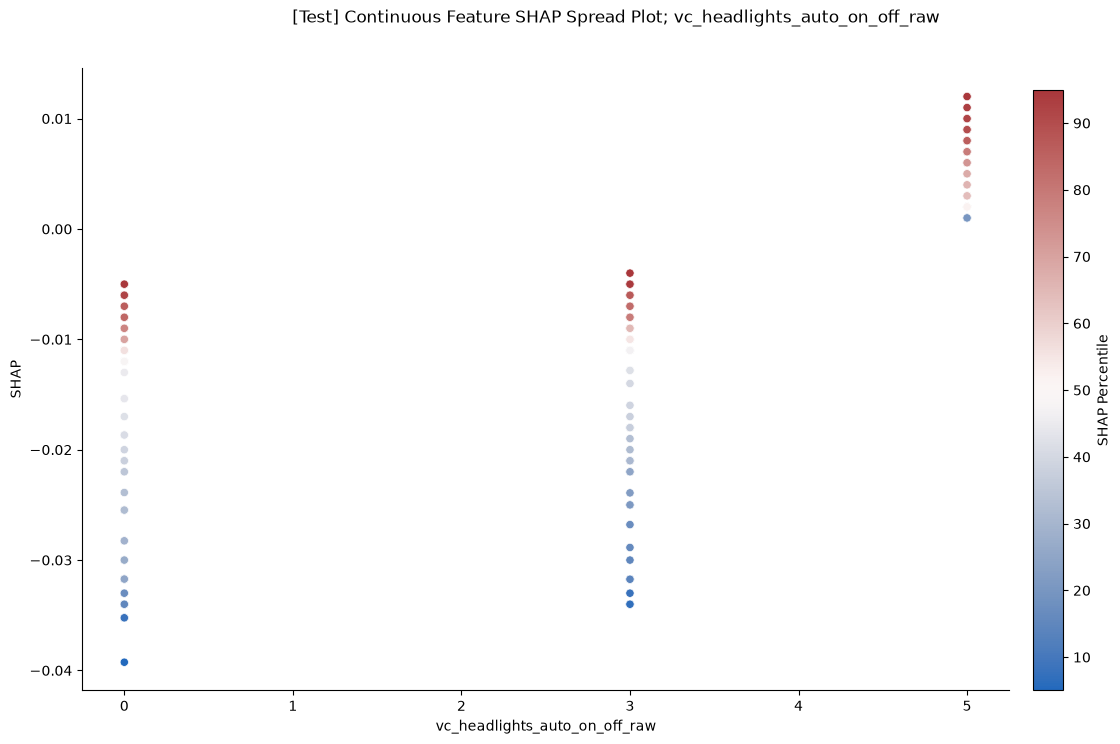


FEATURE: vc_surround_sound_raw


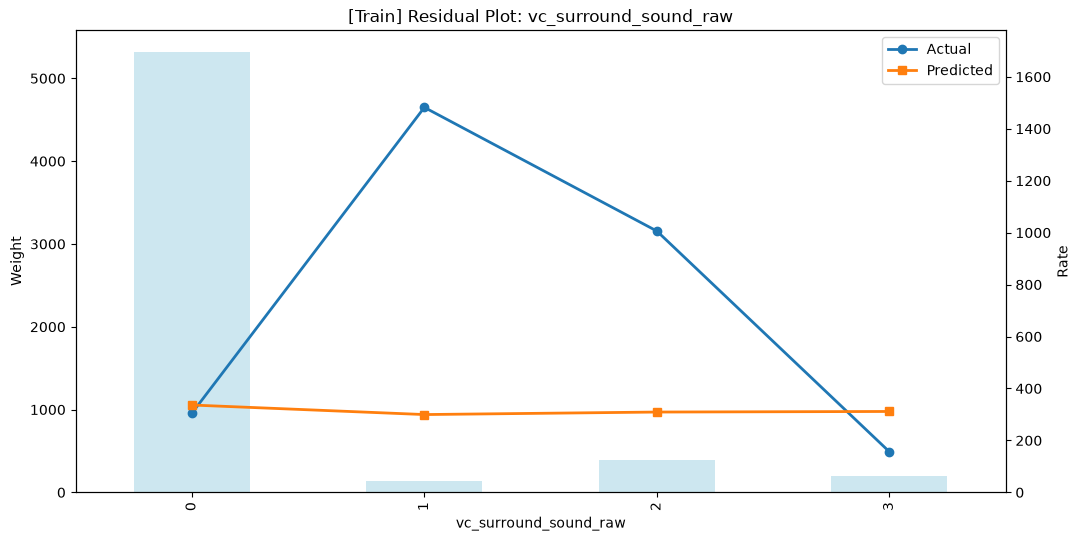

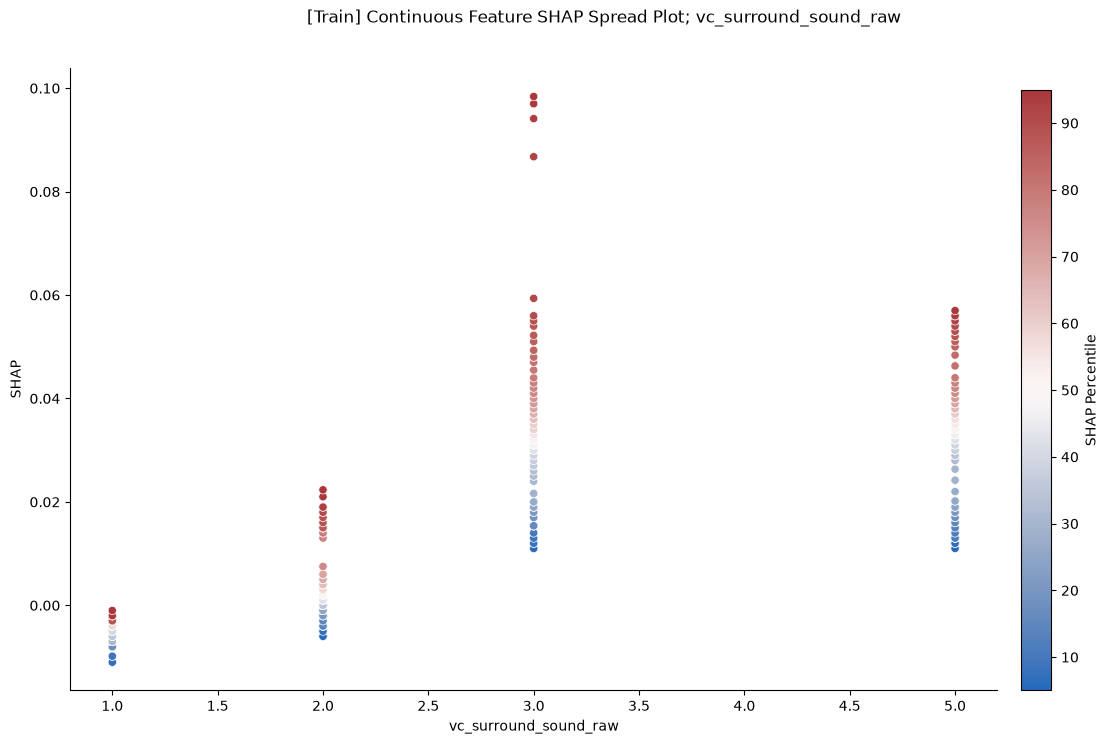

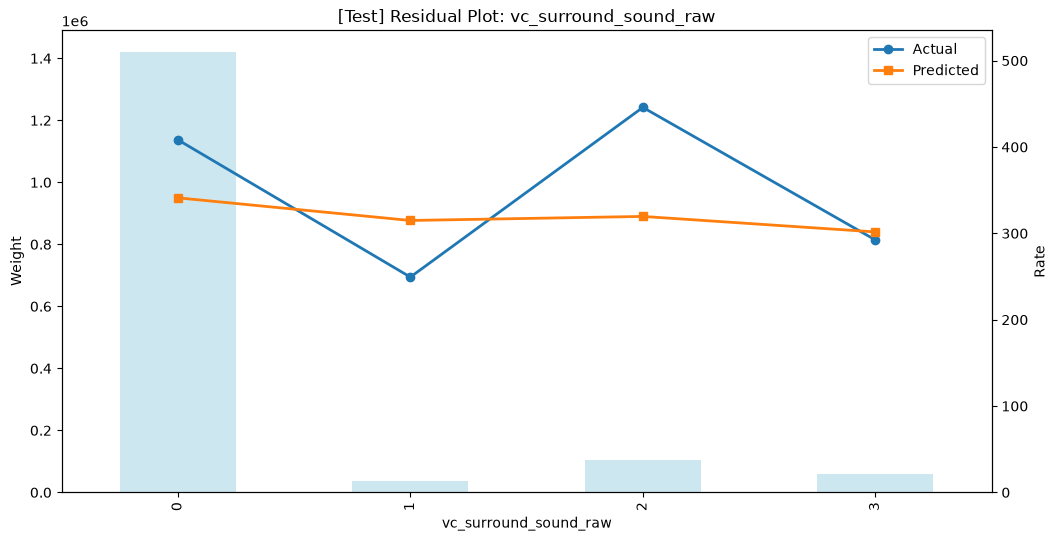

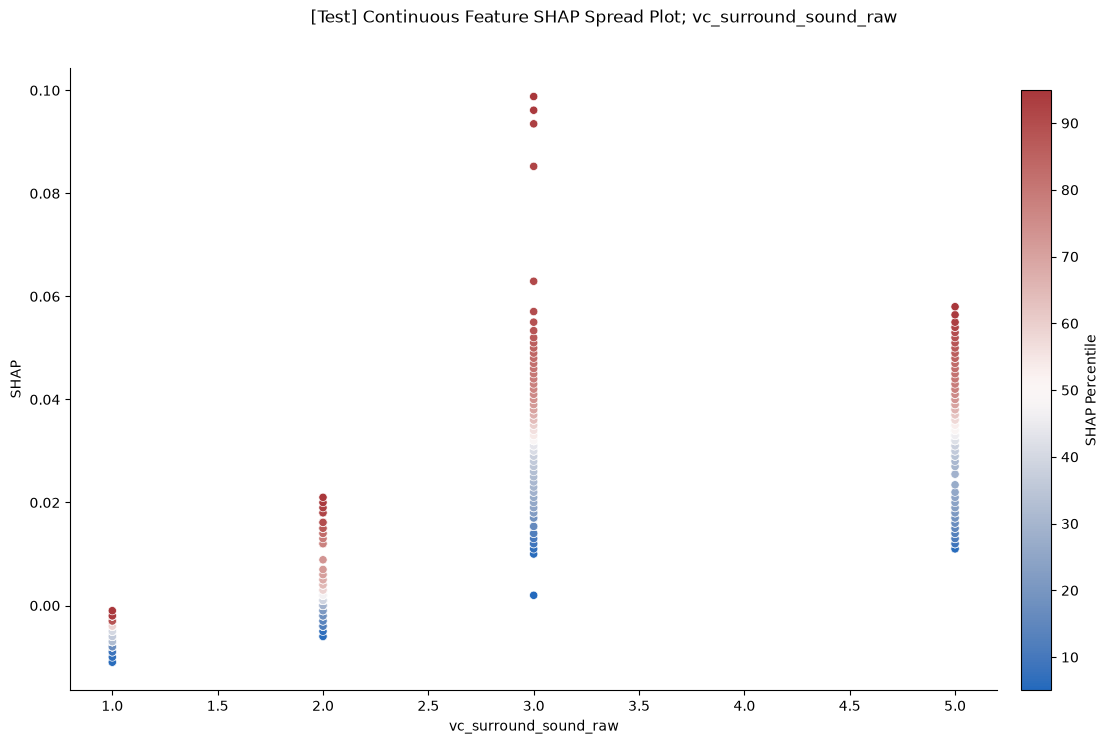


FEATURE: vc_power_sunroof_raw


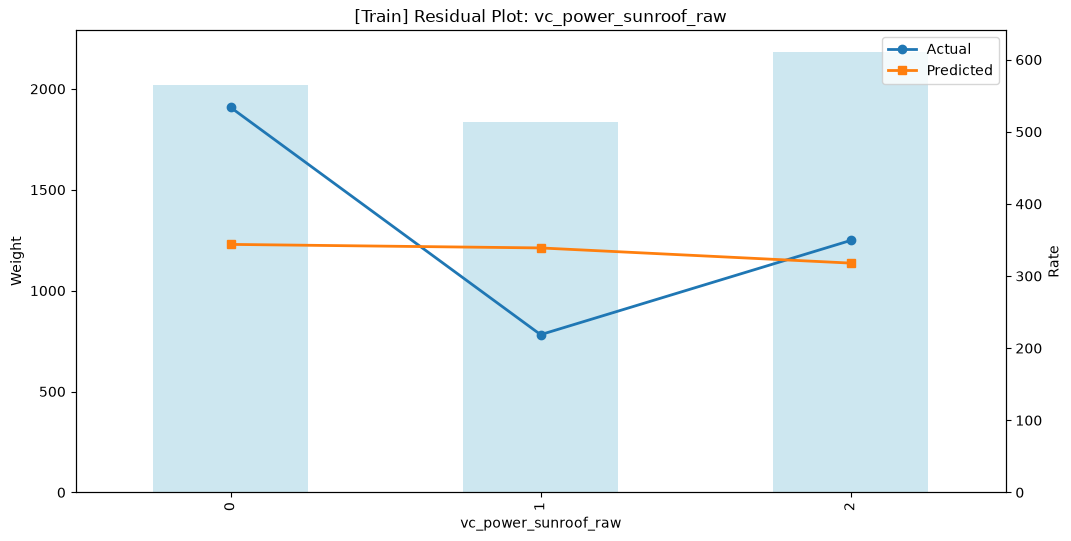

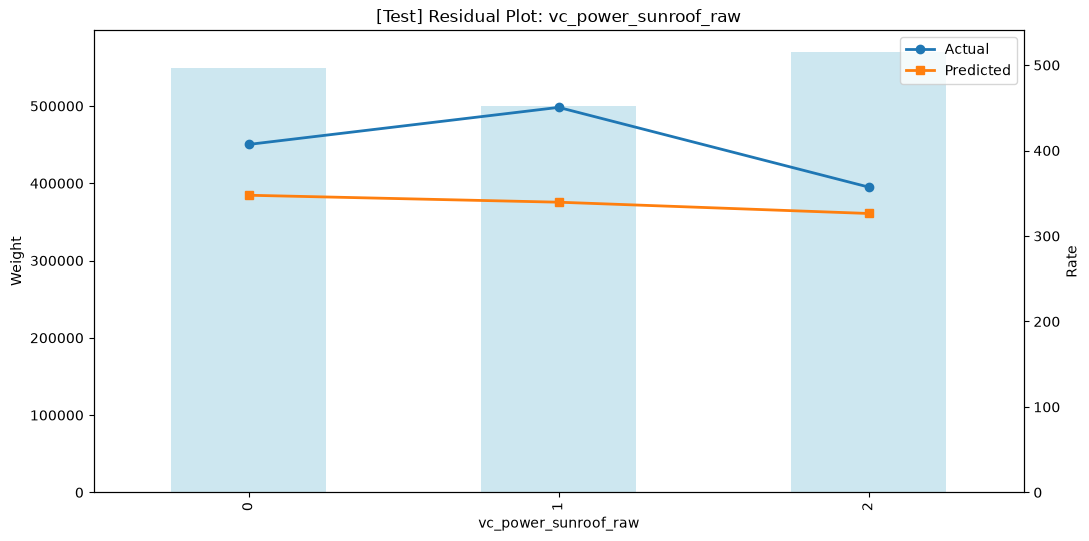


FEATURE: vc_auto_dimming_side_mirrors_raw


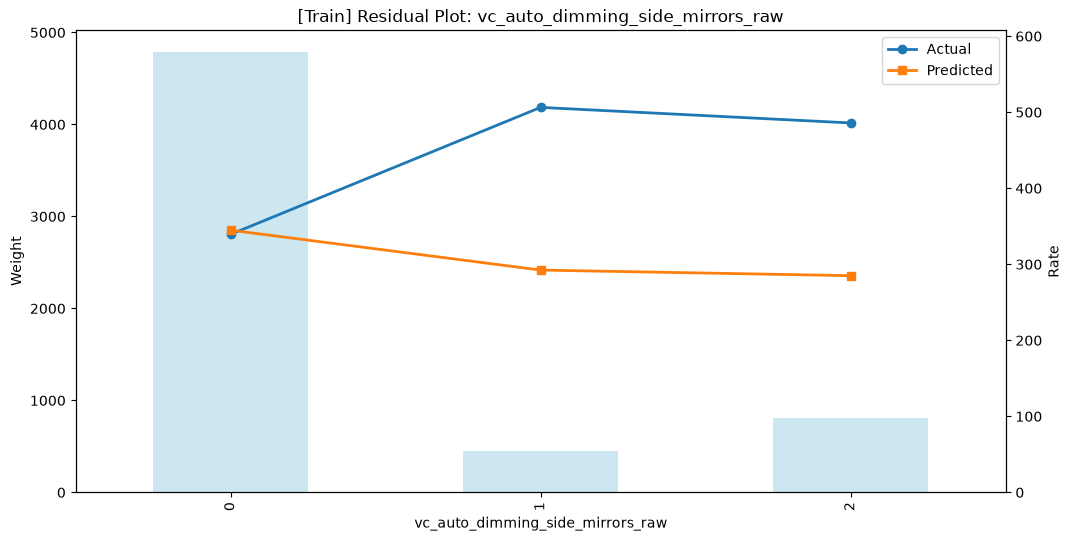

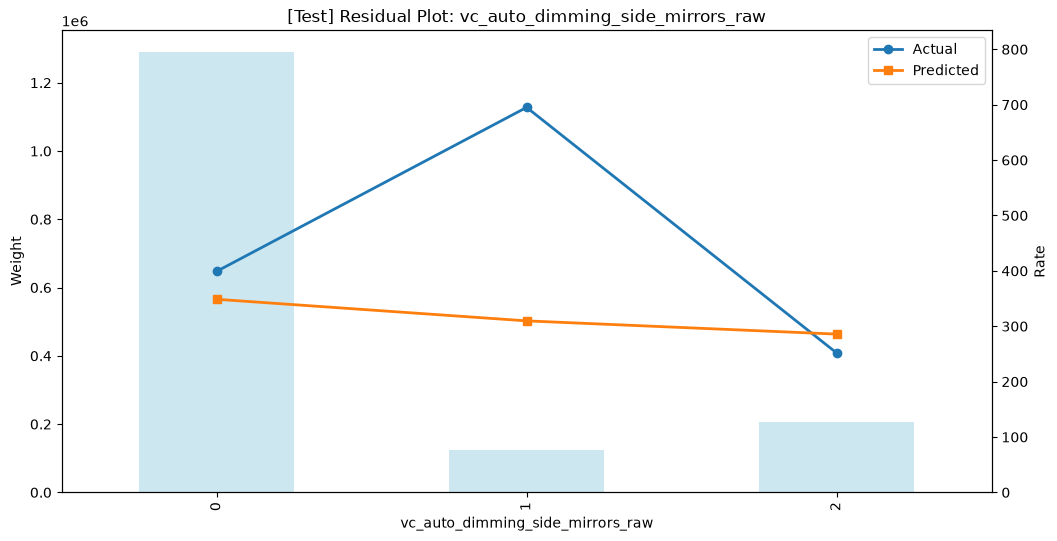


FEATURE: vc_taillights_led_raw


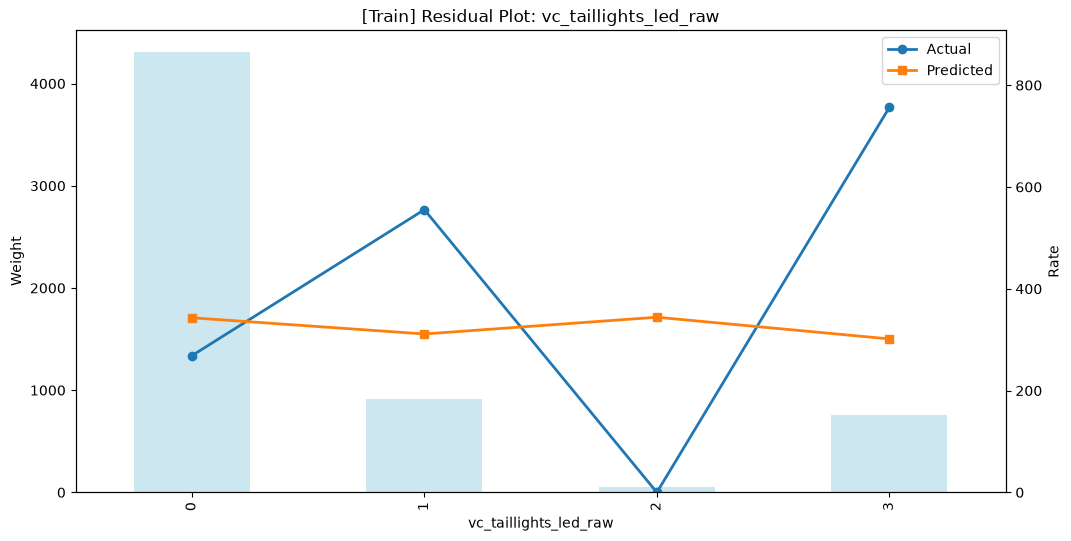

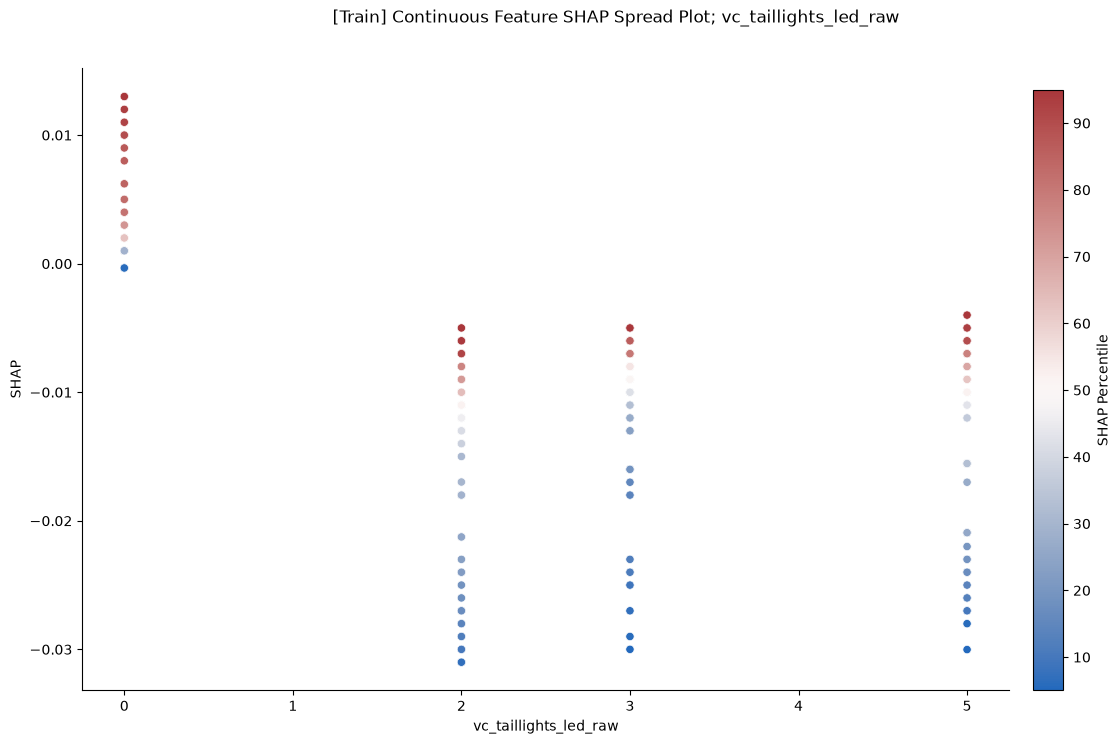

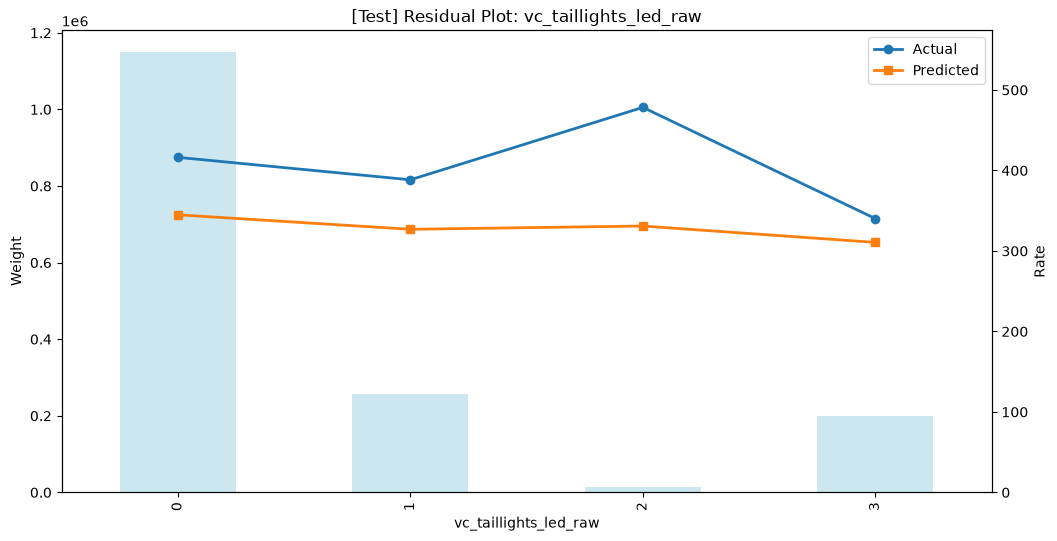

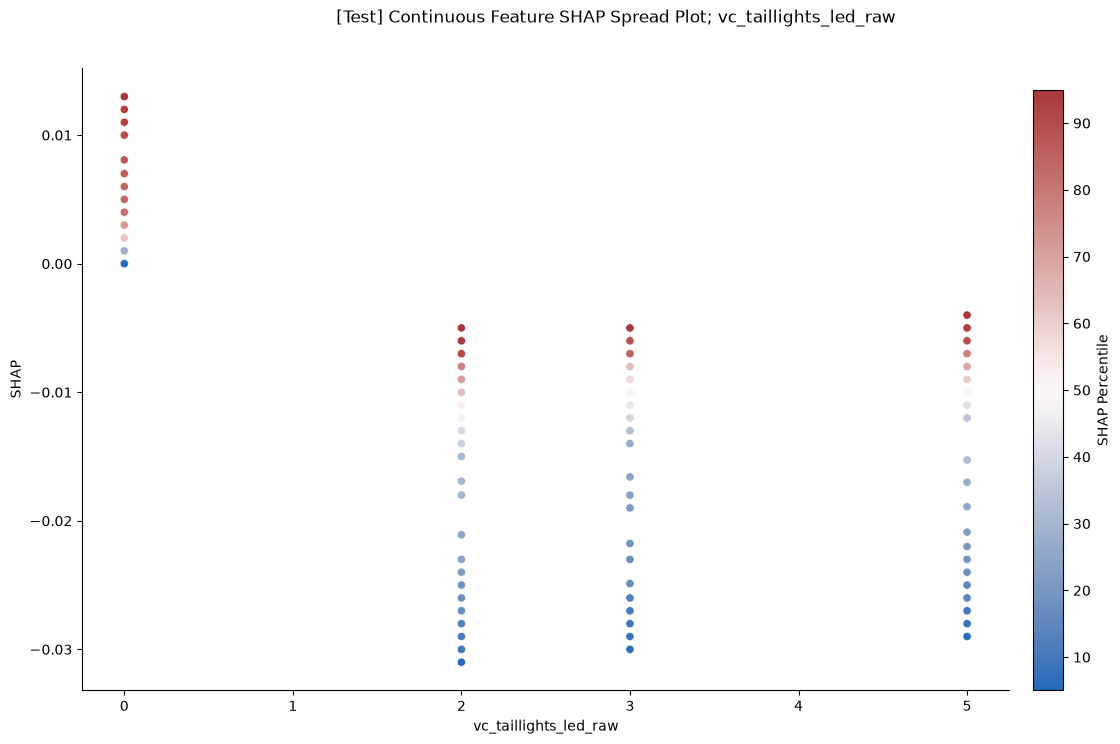


FEATURE: vc_auto_dimming_rearview_mirror_raw


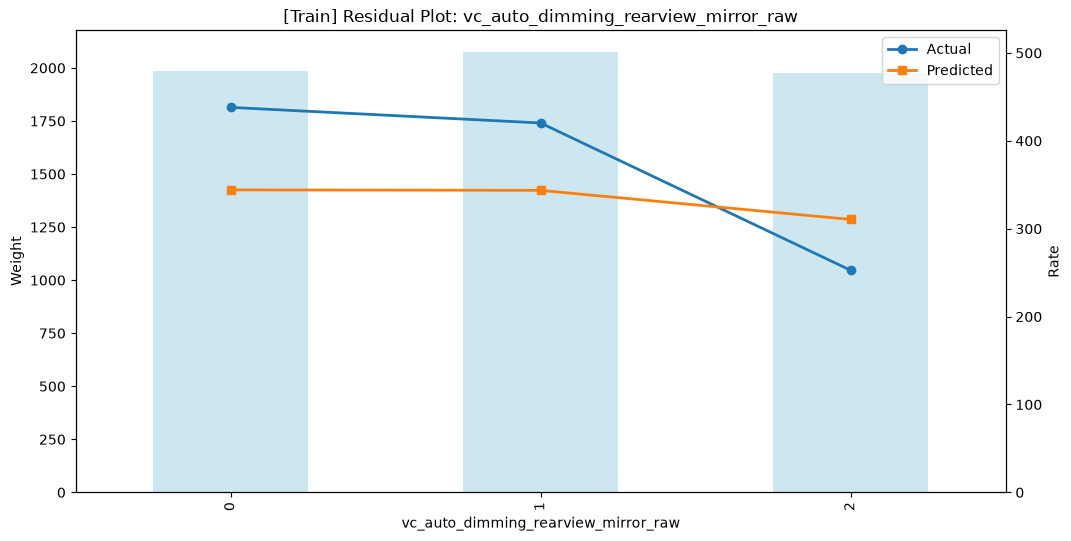

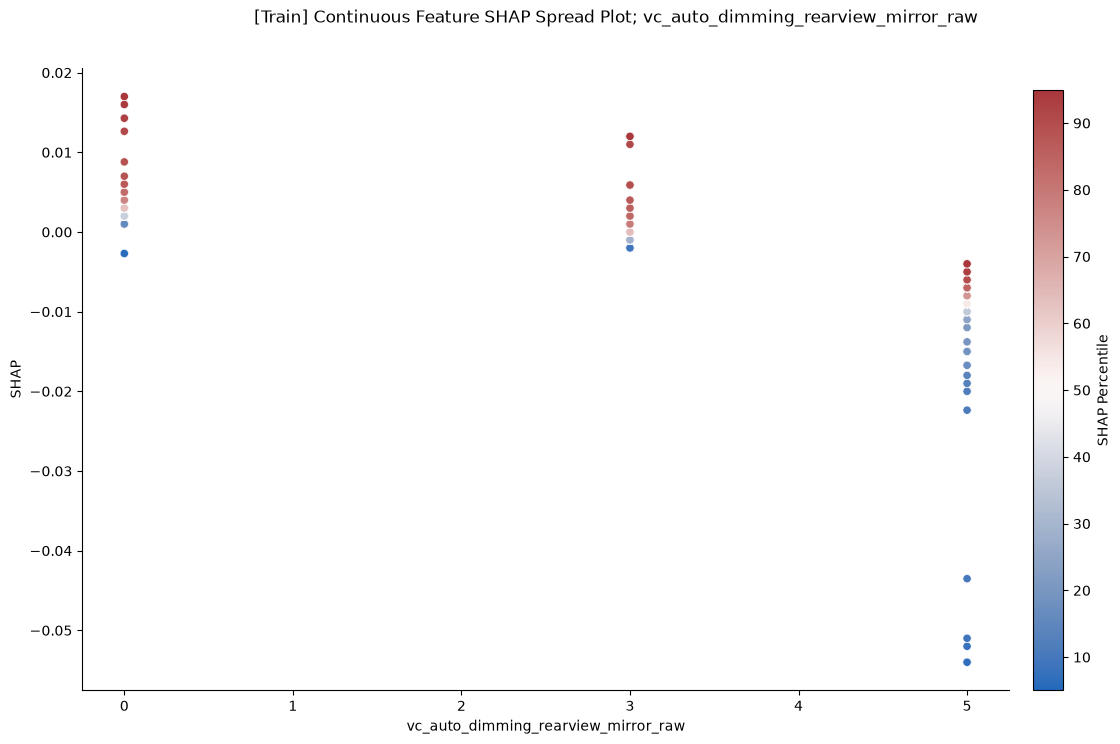

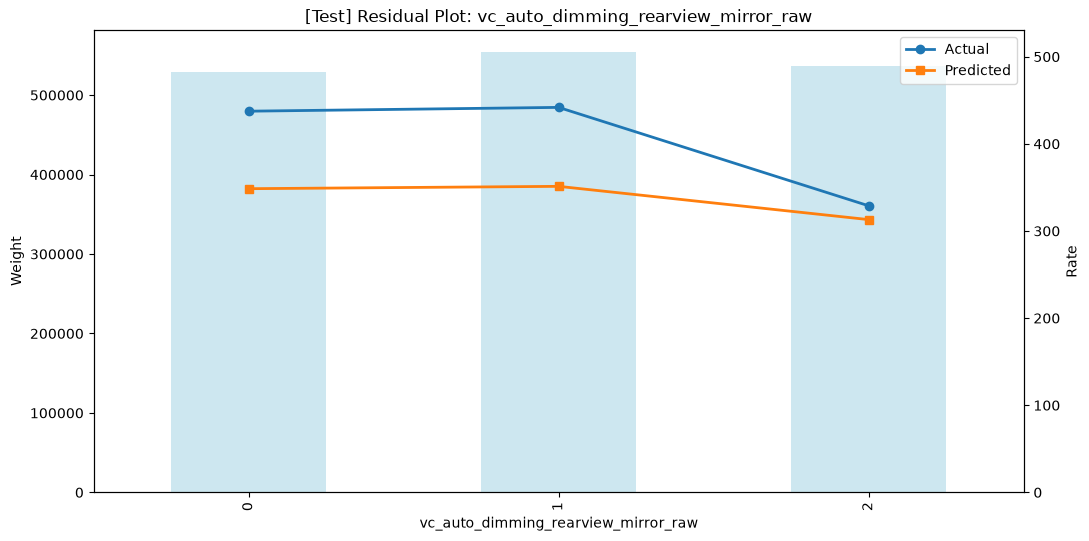

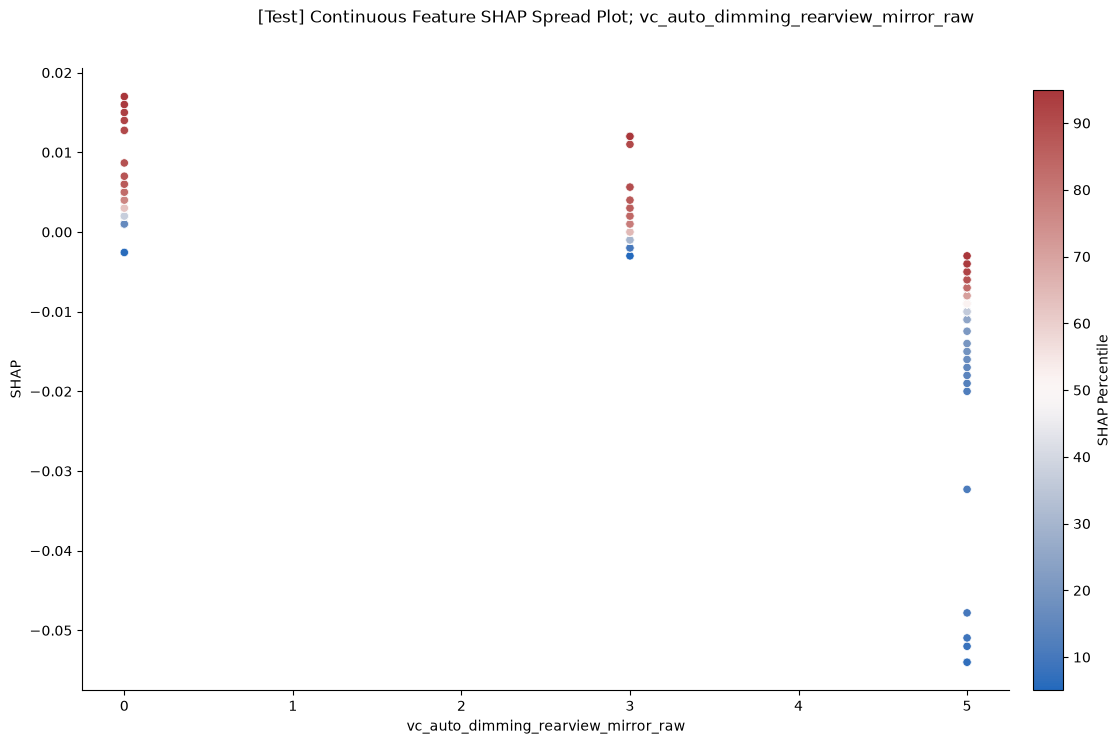


FEATURE: vc_automatic_high_beams_raw


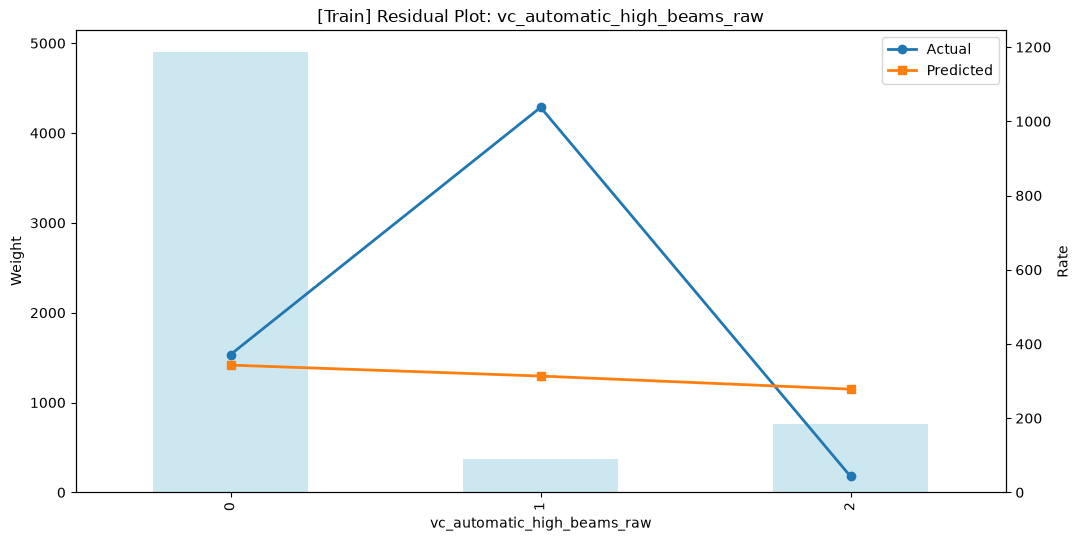

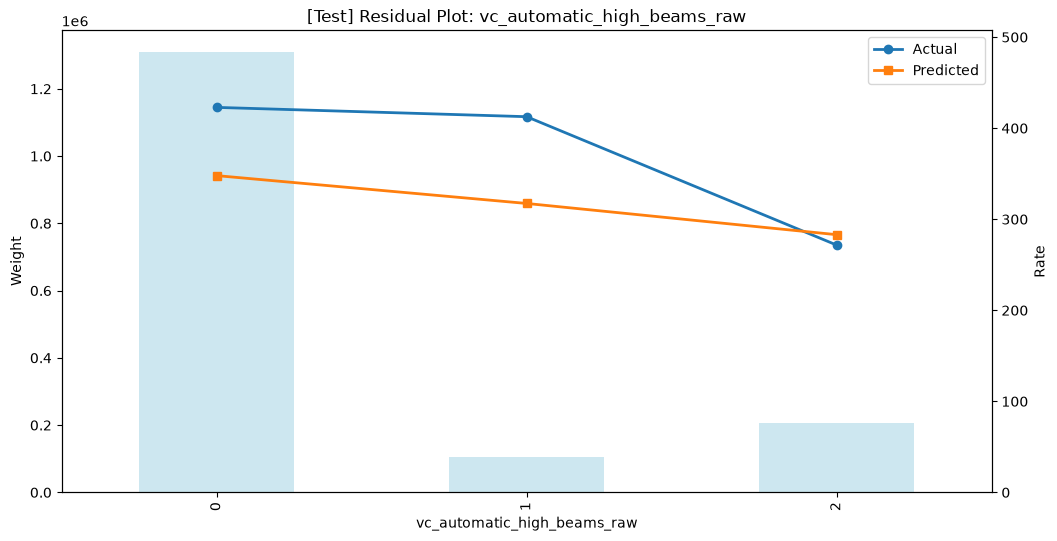


FEATURE: vc_variable_power_steering_raw


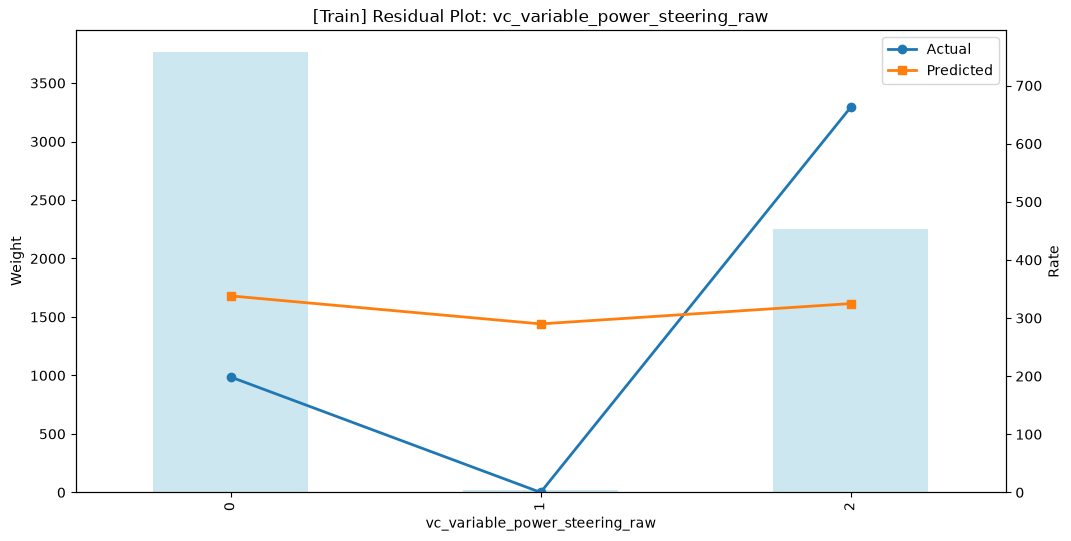

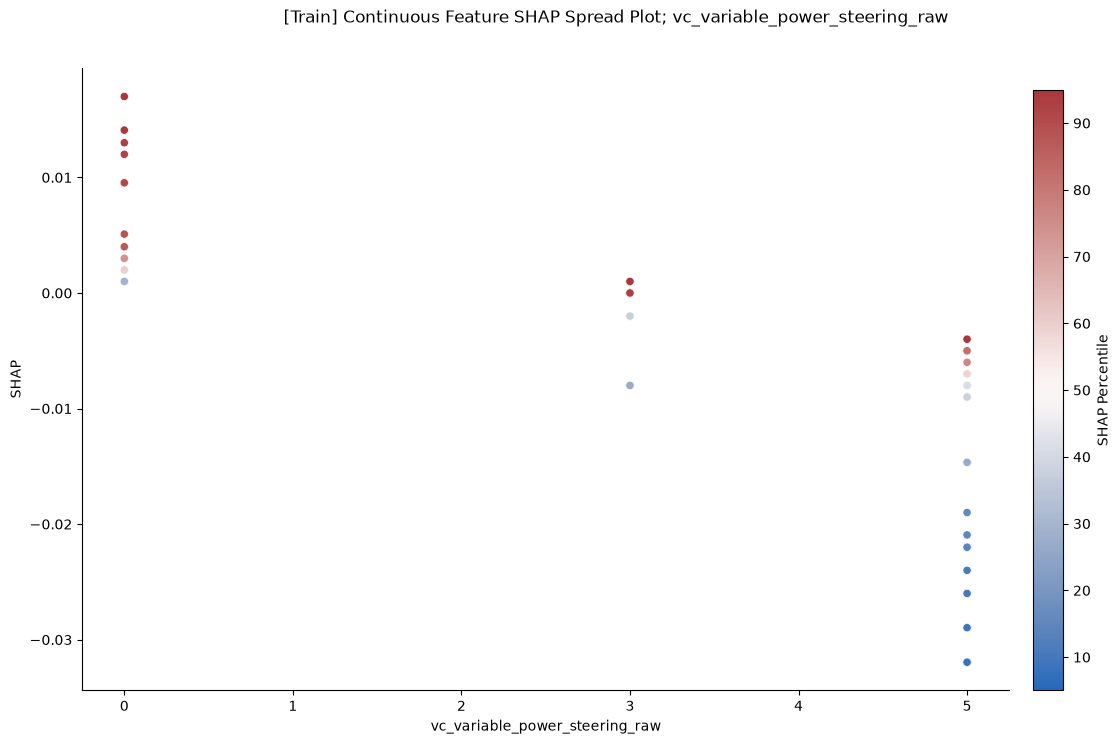

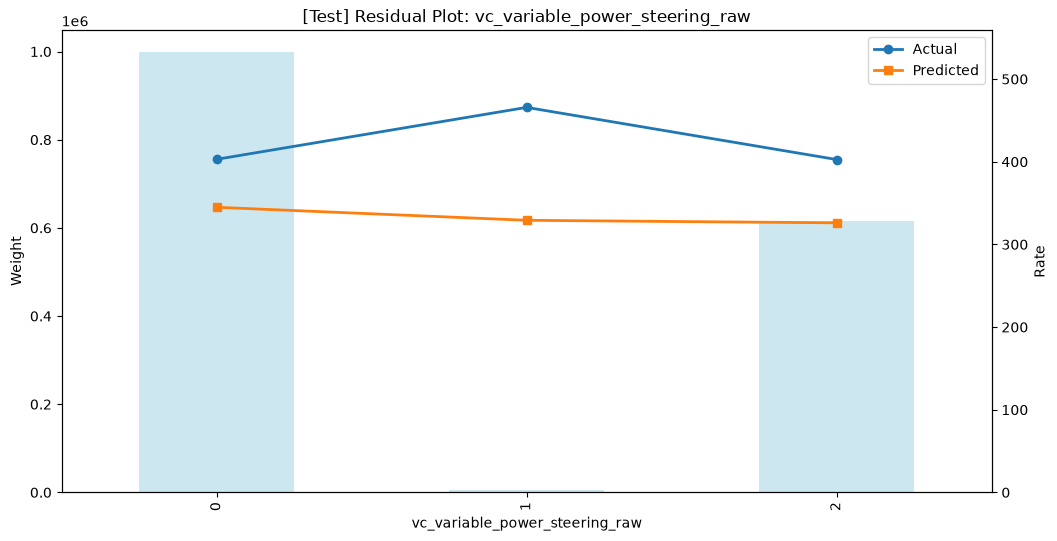

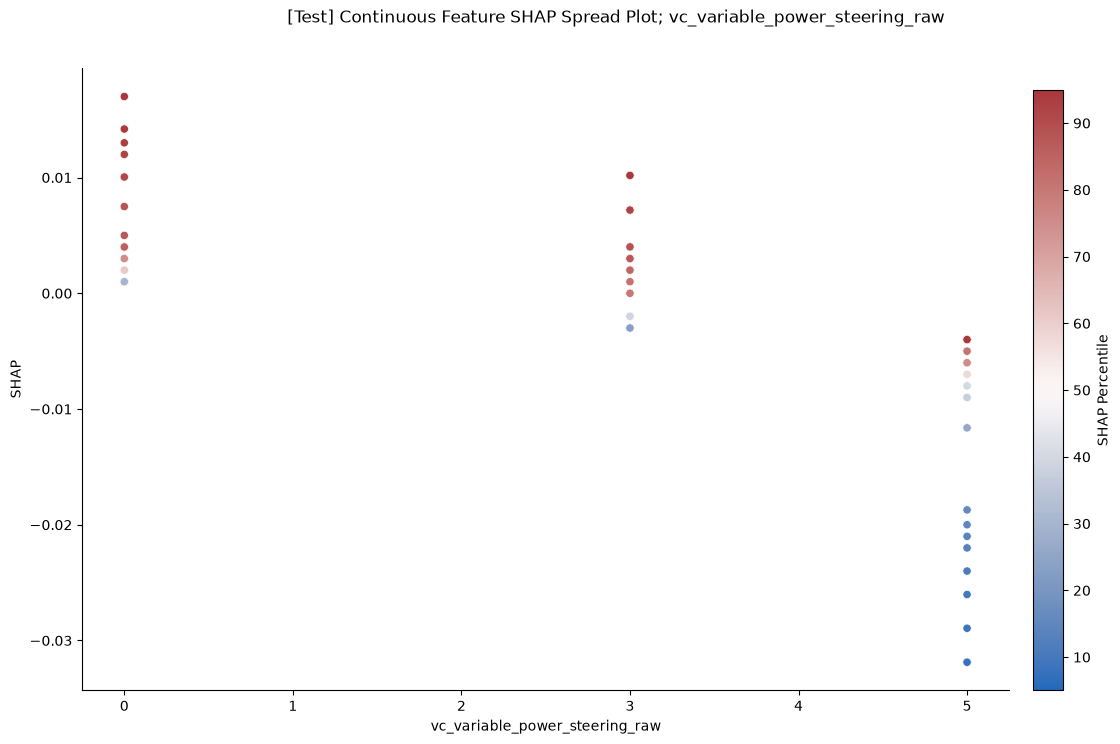


FEATURE: vc_seating_rows_raw


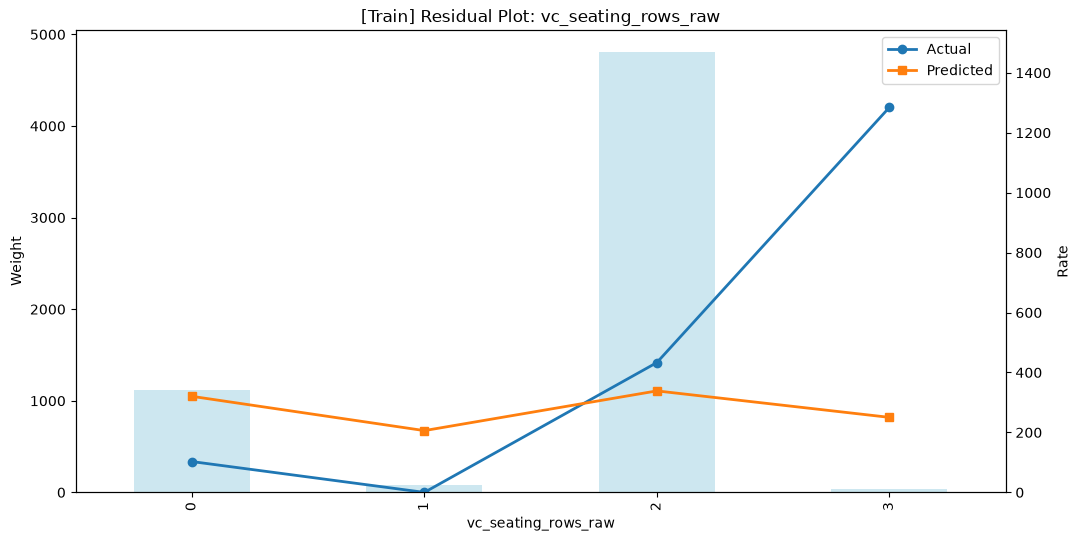

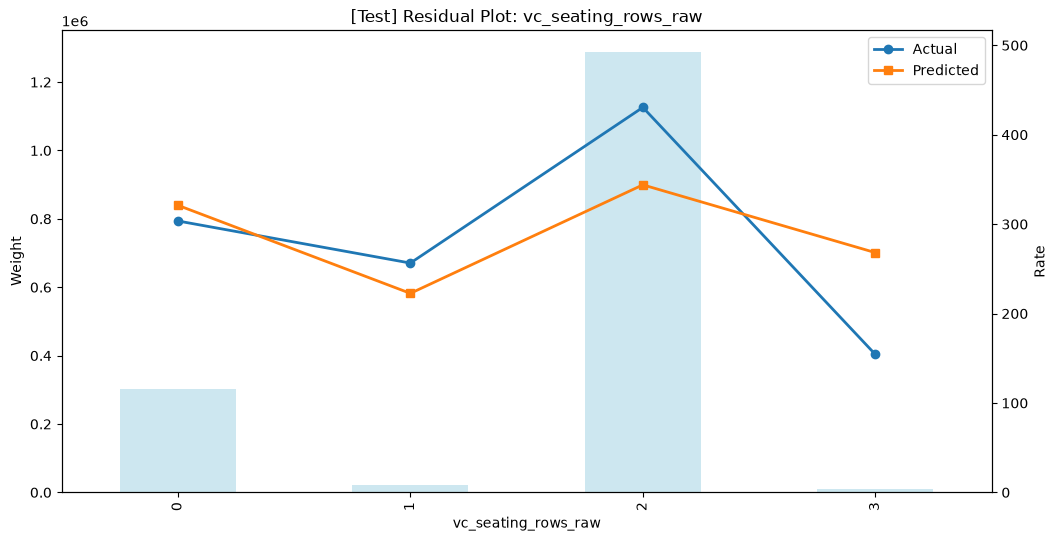


FEATURE: vc_drive_type_awd_ind


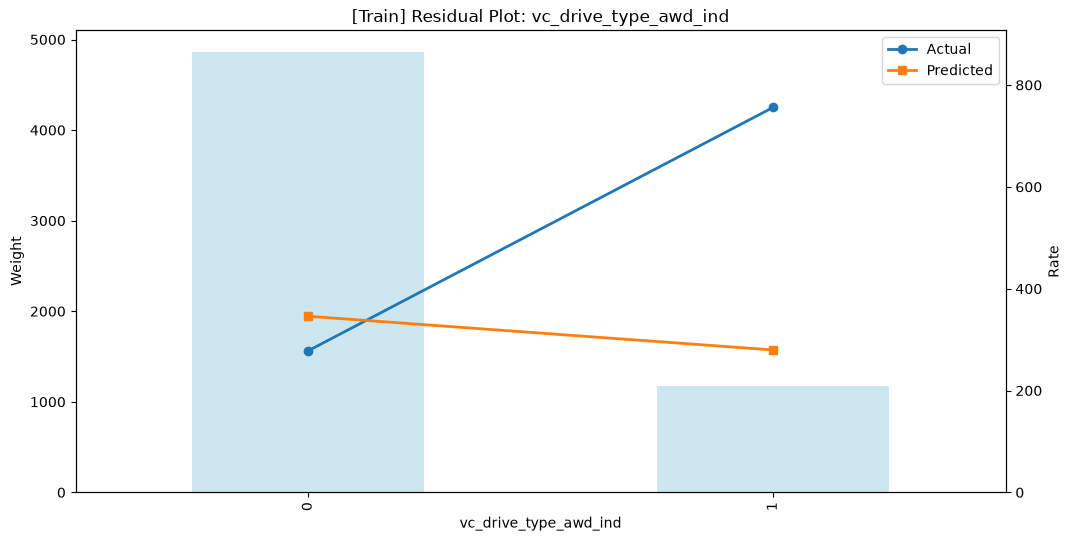

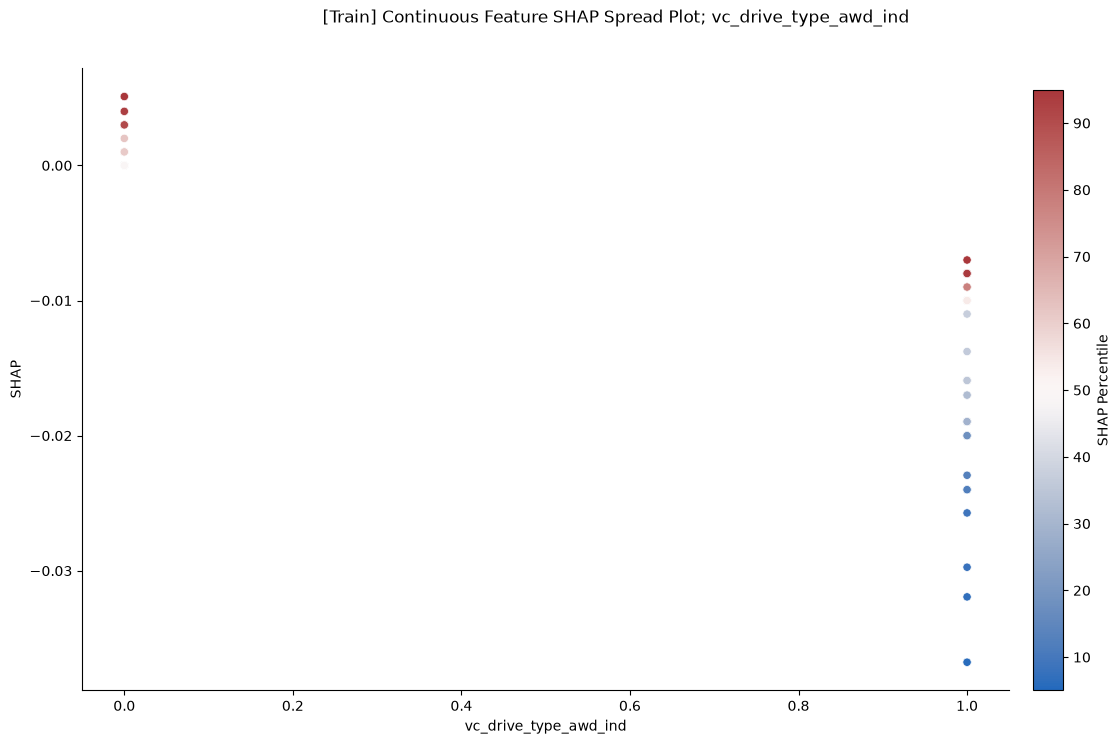

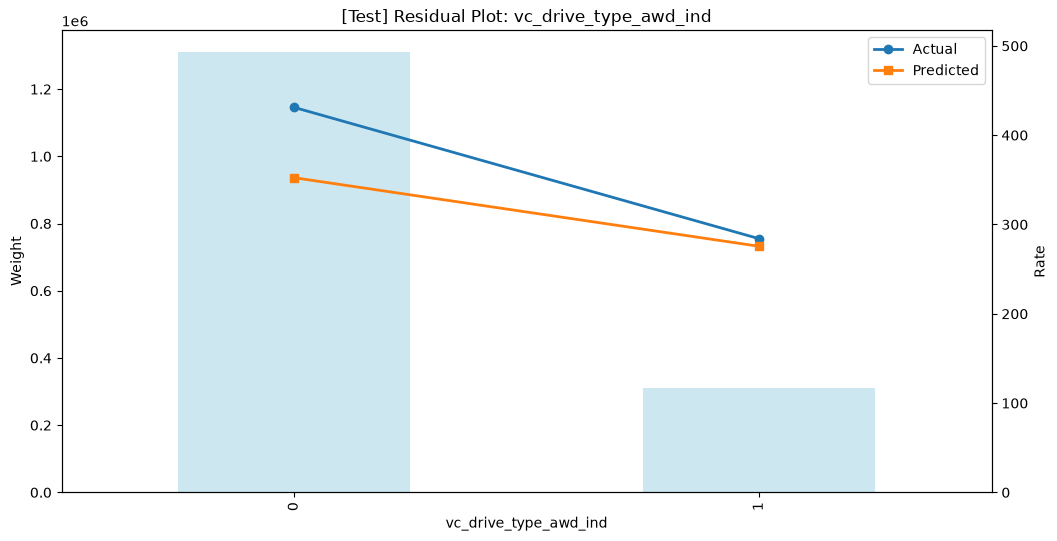

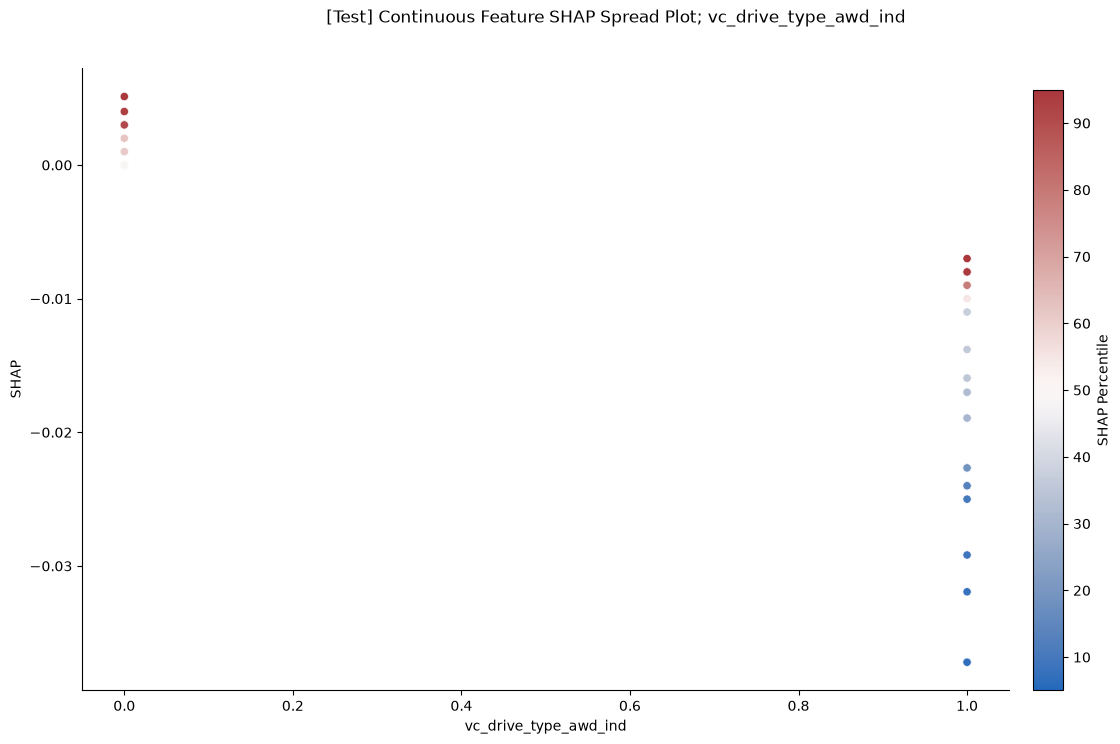


FEATURE: vc_active_collision_avoidance_system_raw


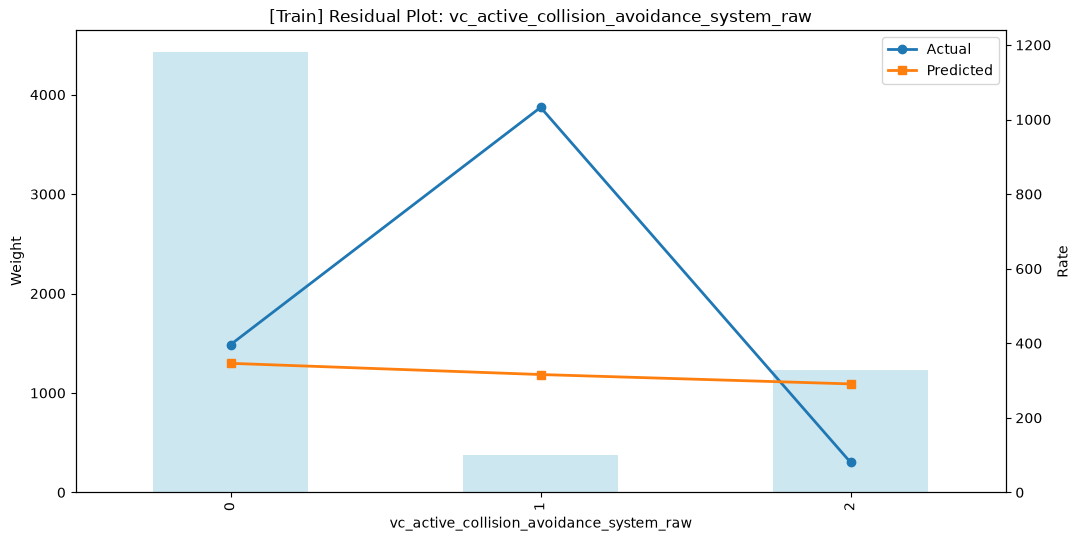

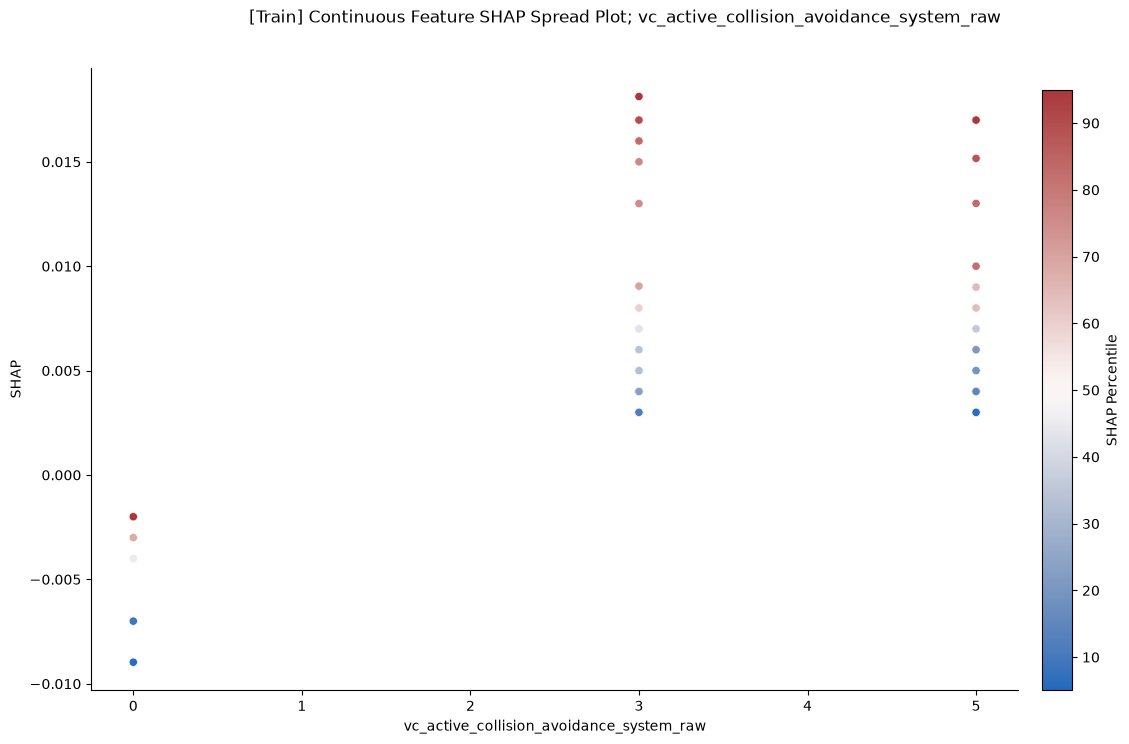

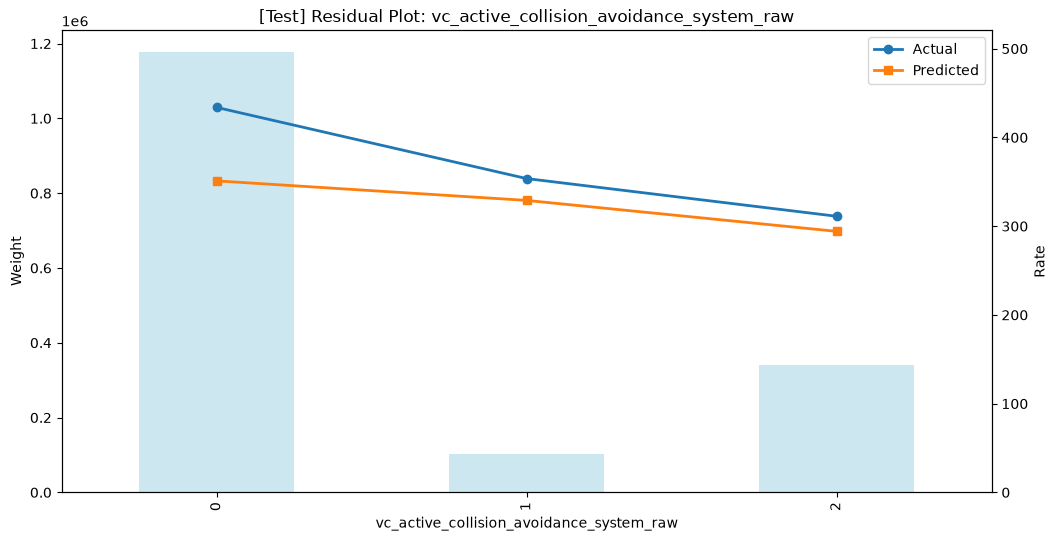


FEATURE: vc_sunroof_raw


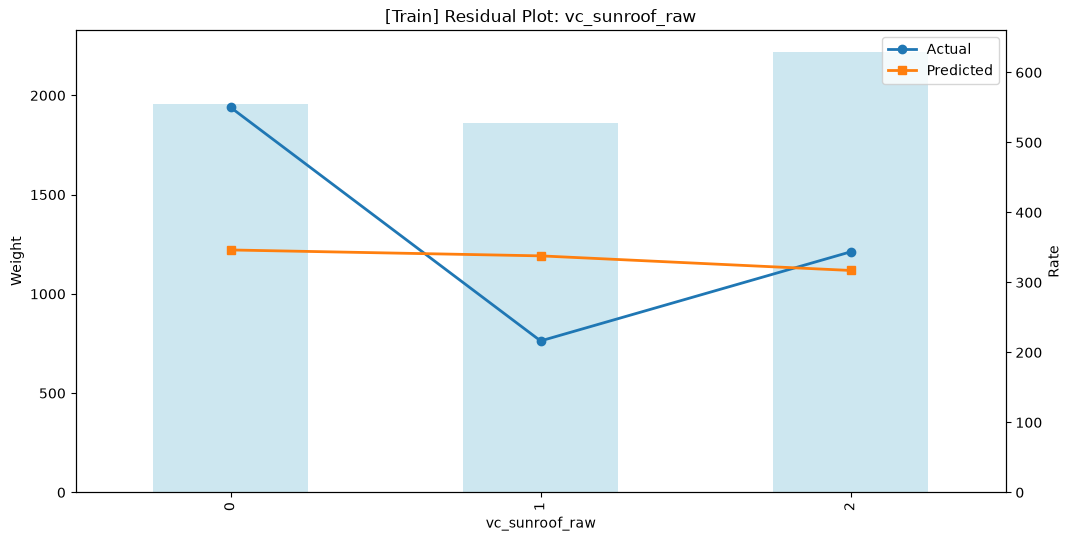

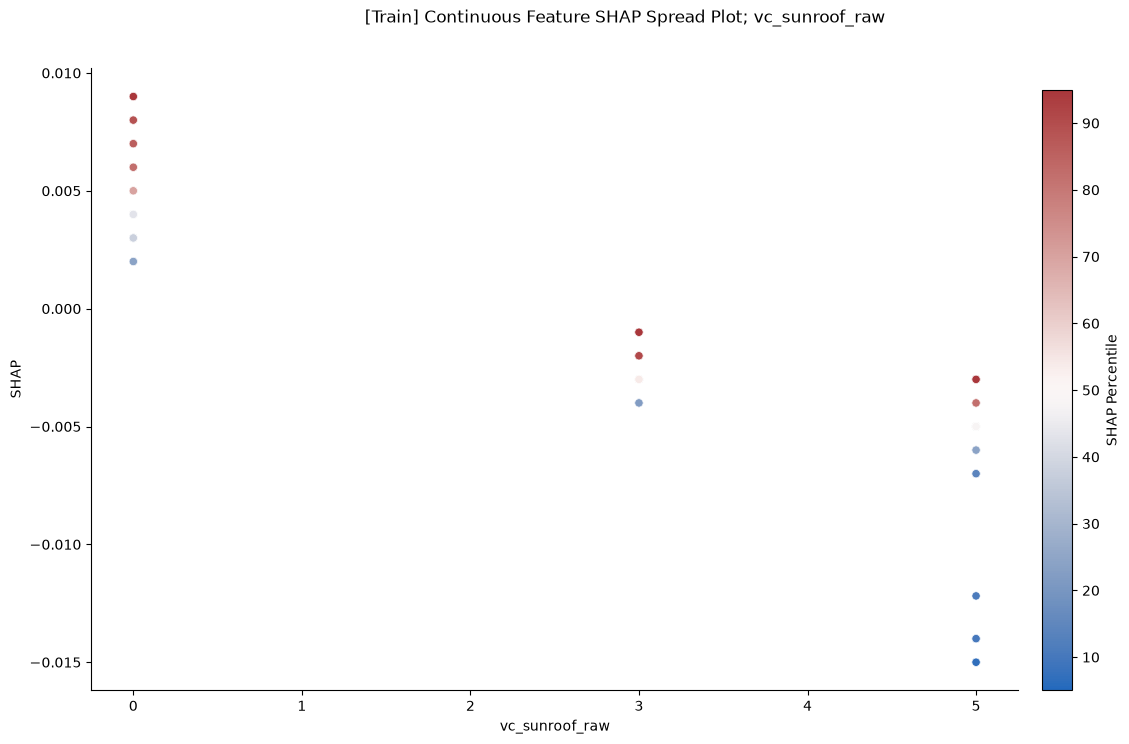

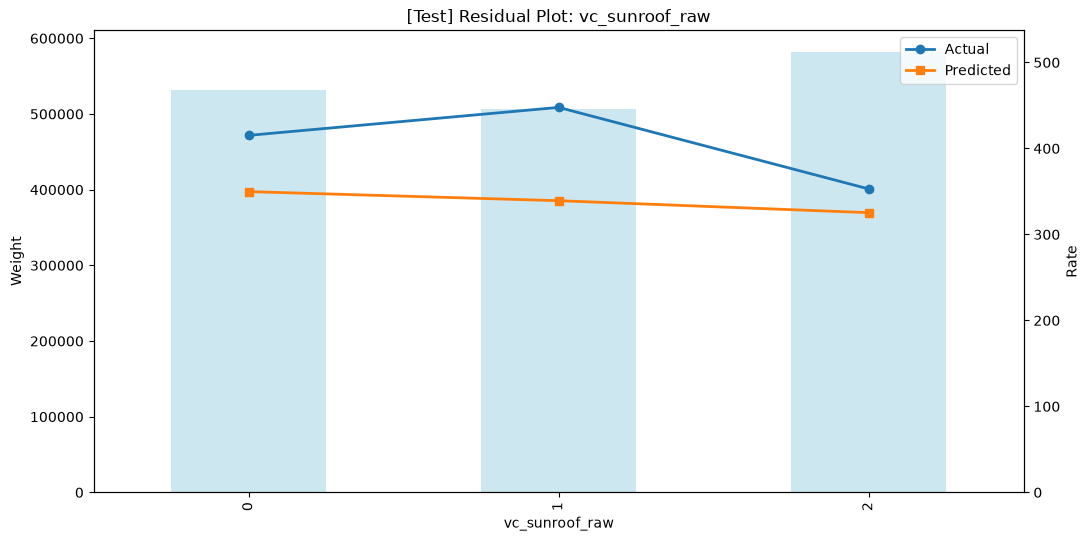

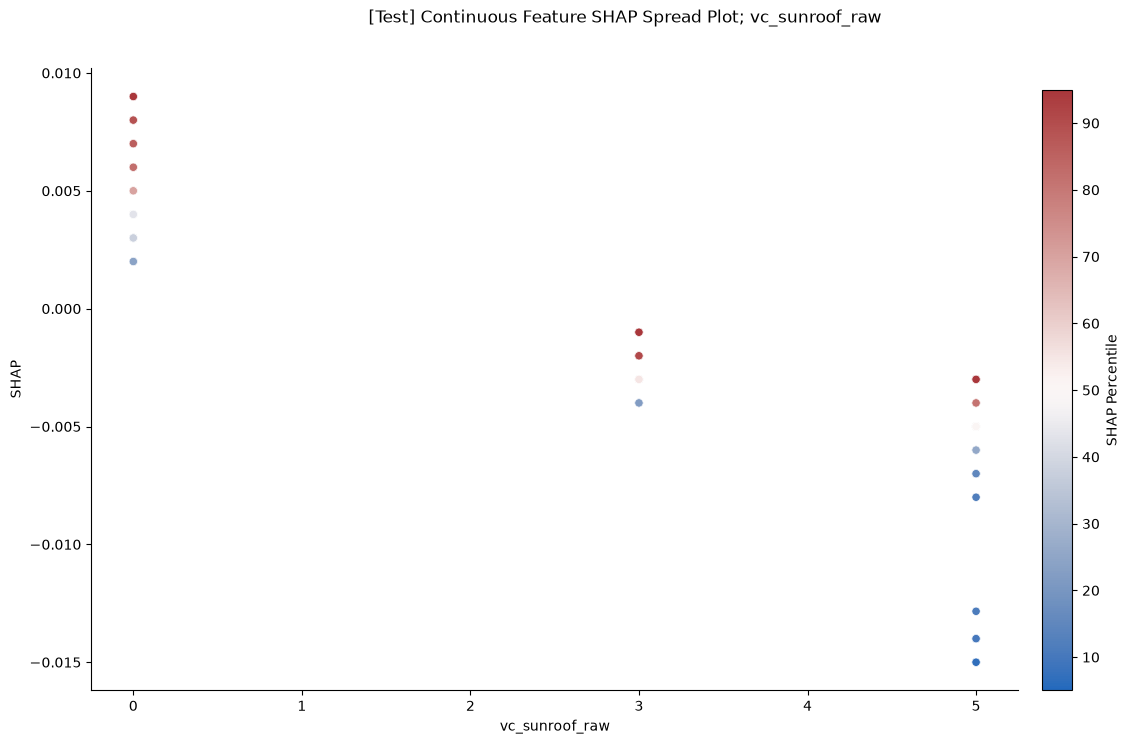


FEATURE: vc_transmission_type_automatic_ind


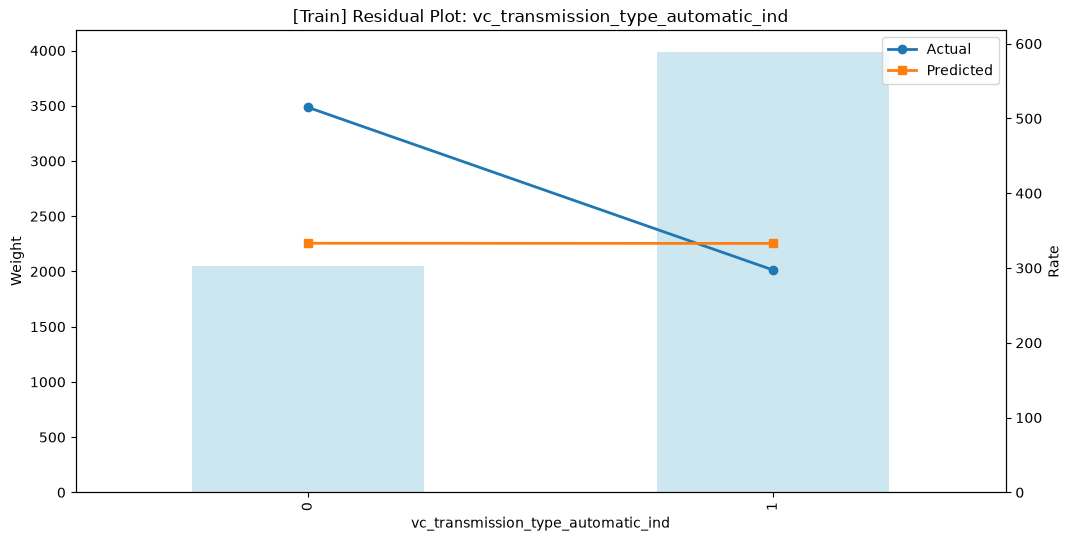

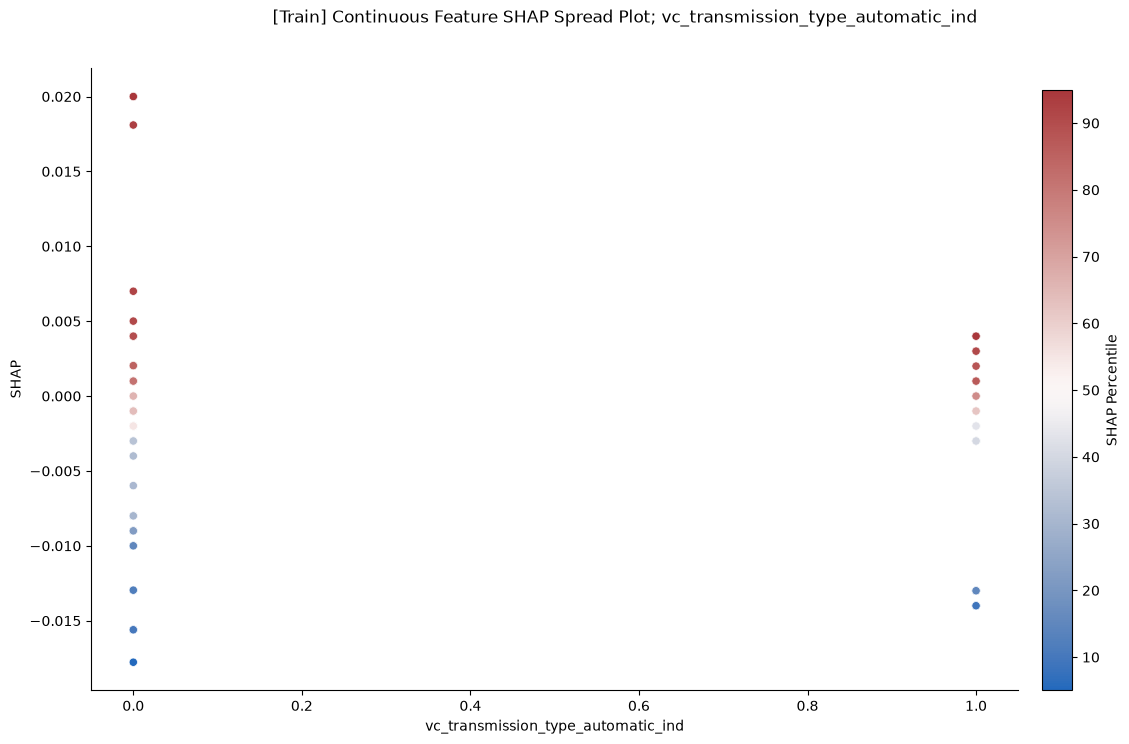

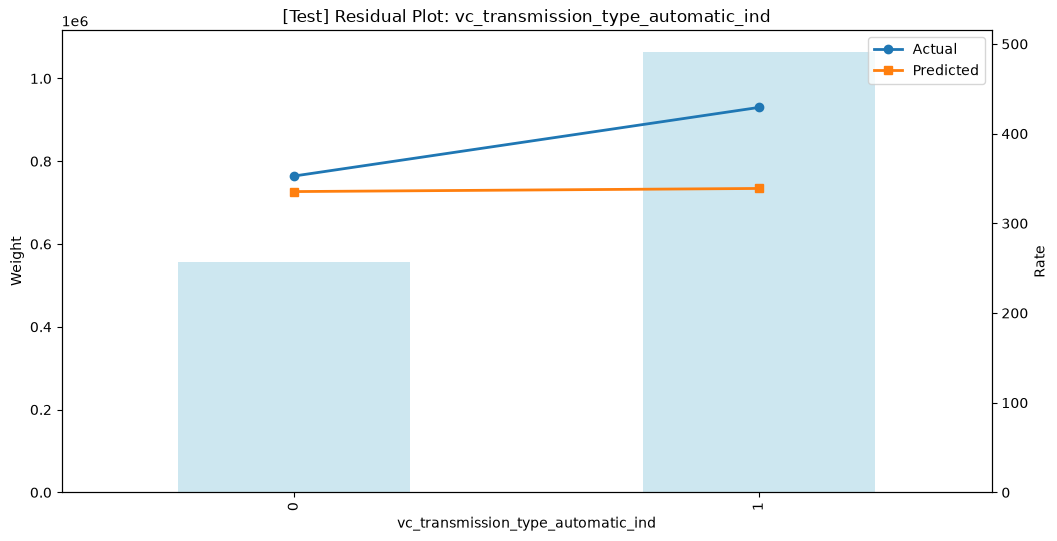

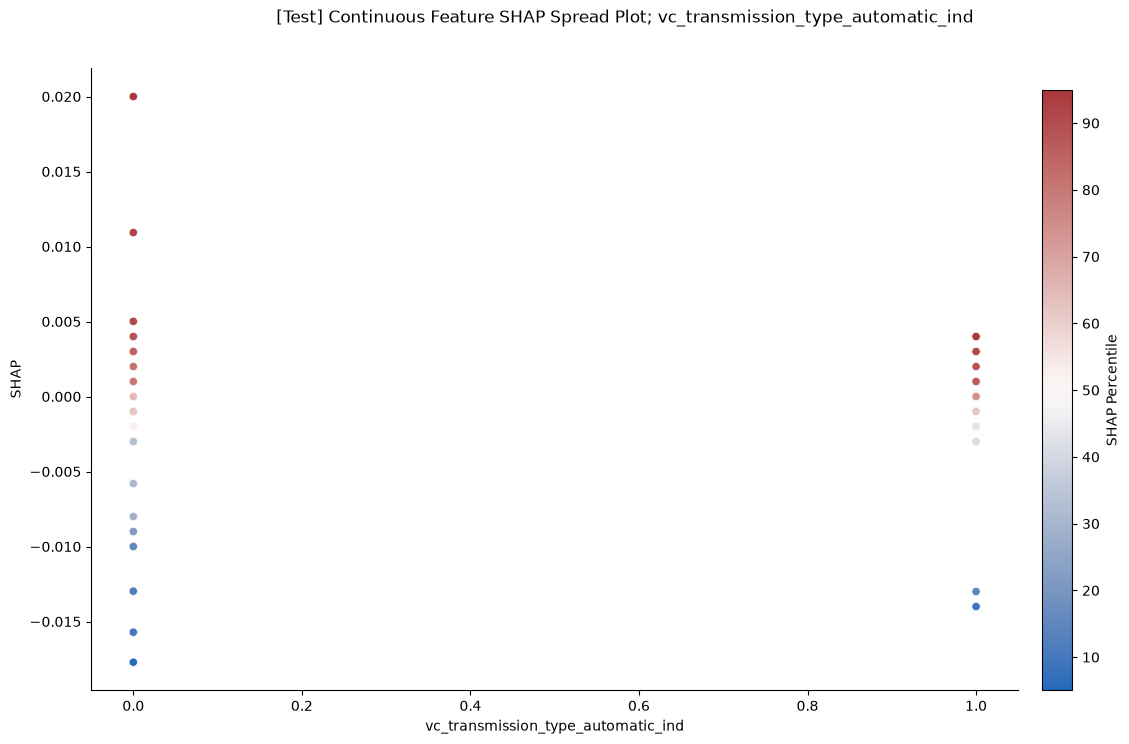


FEATURE: vc_active_parking_assistance_raw


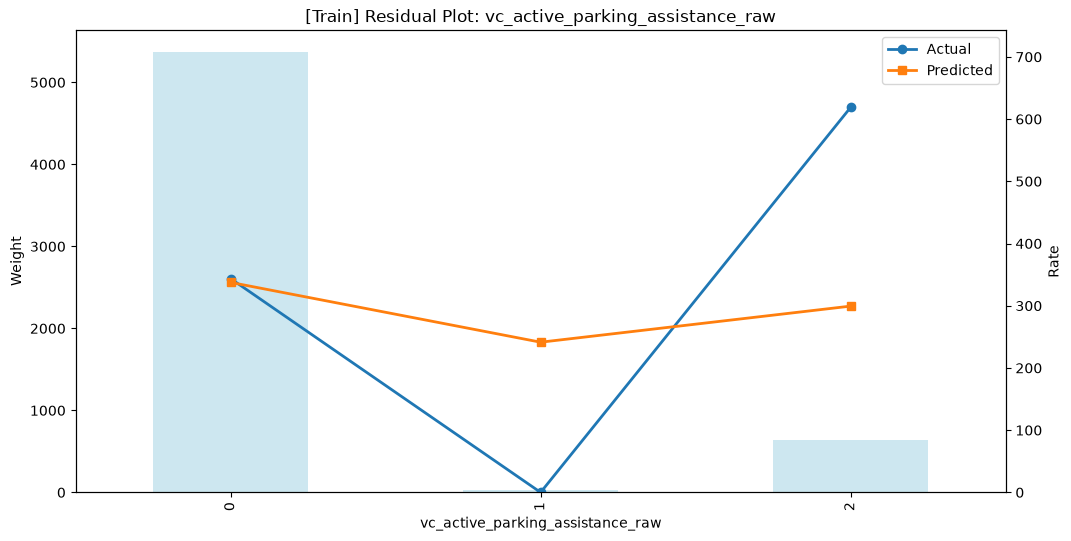

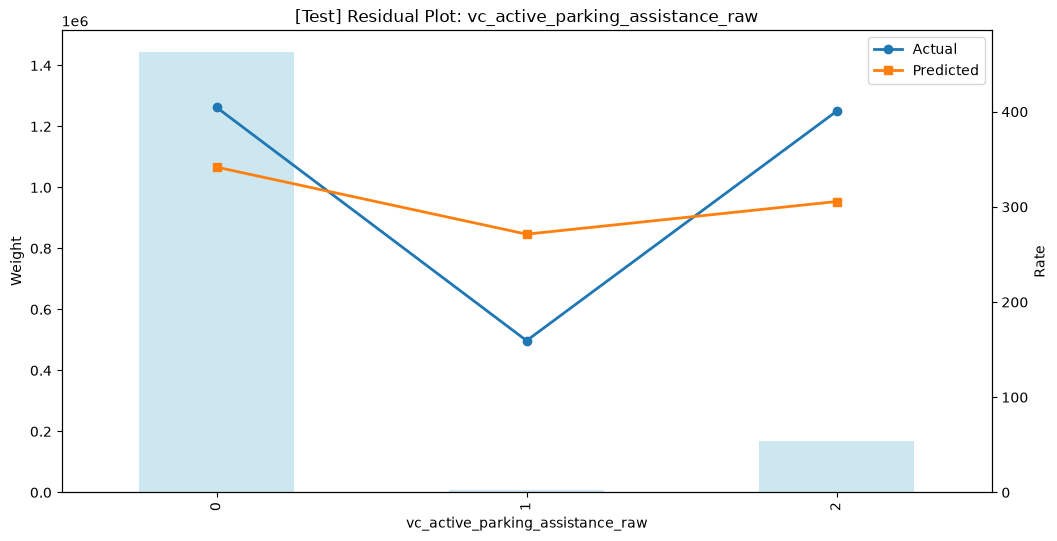


FEATURE: late_payments_raw


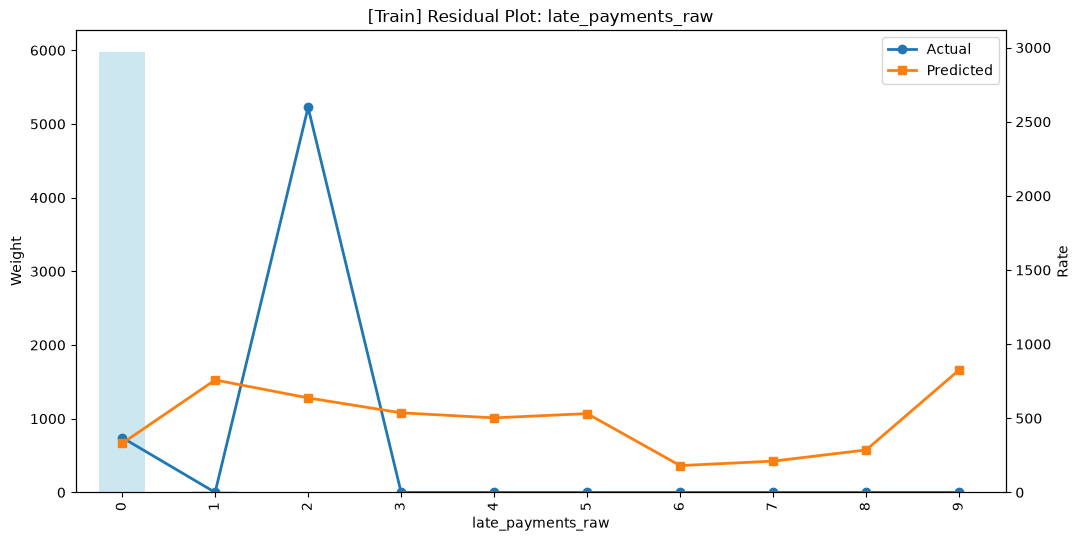


FEATURE: vc_drive_type_fwd_ind


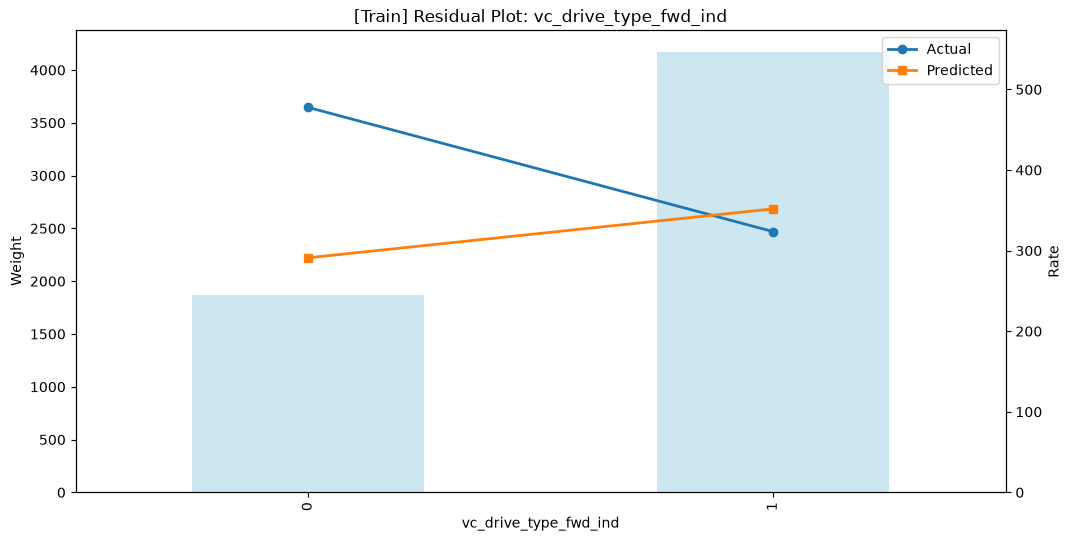

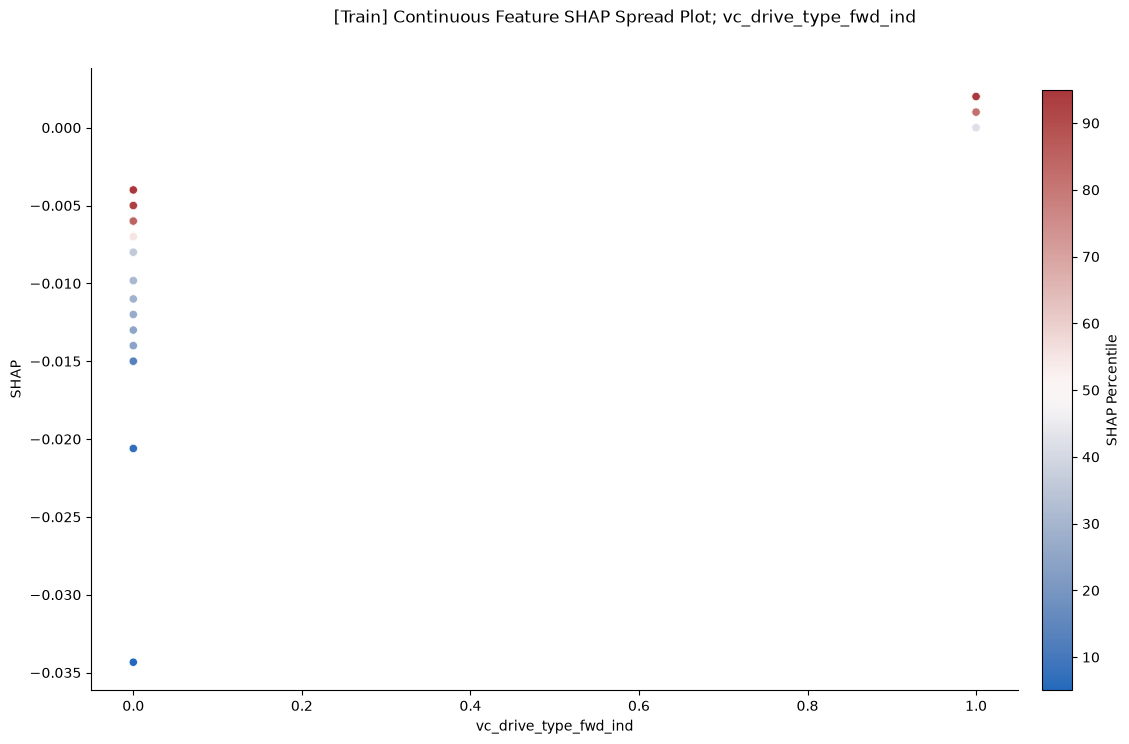

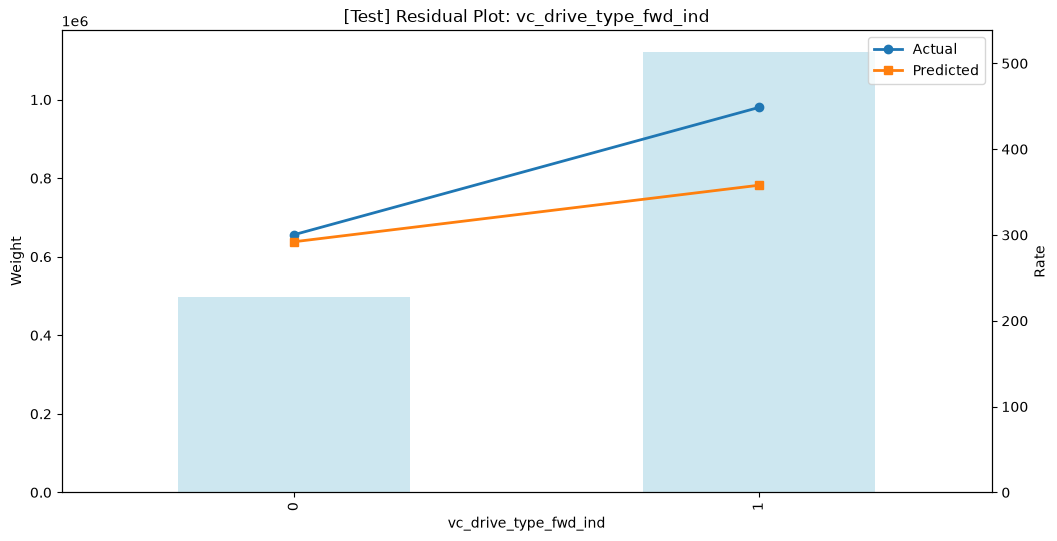

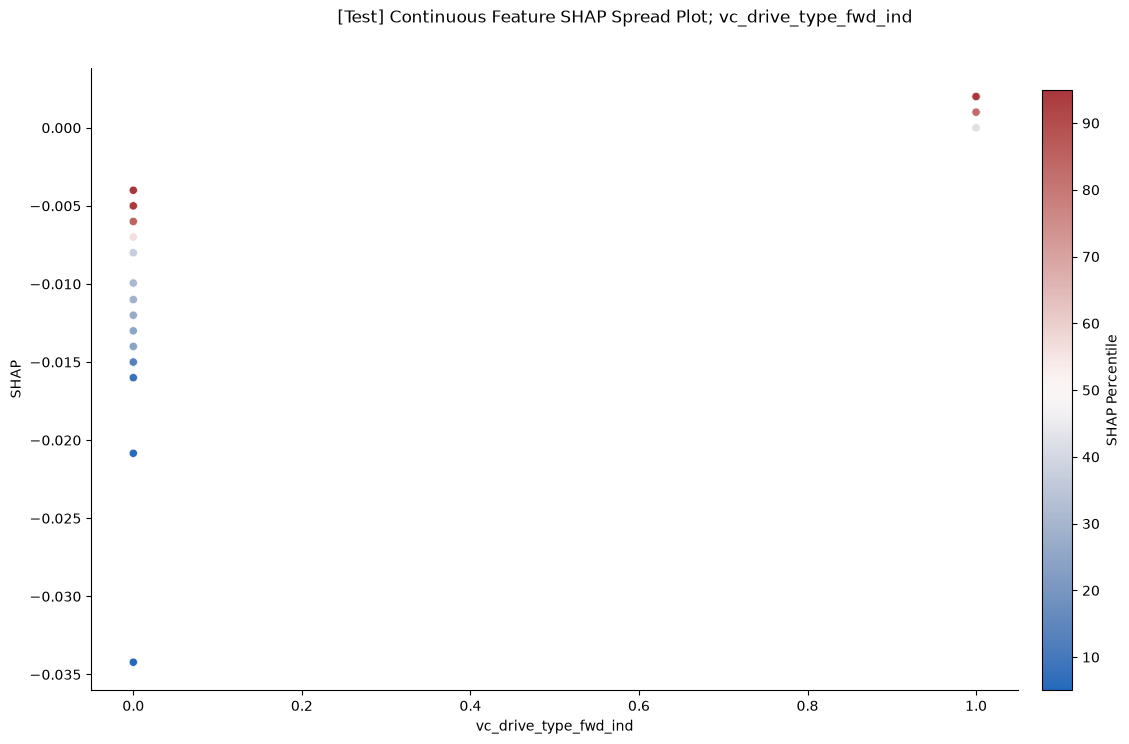


FEATURE: vc_pedestrian_detection_raw


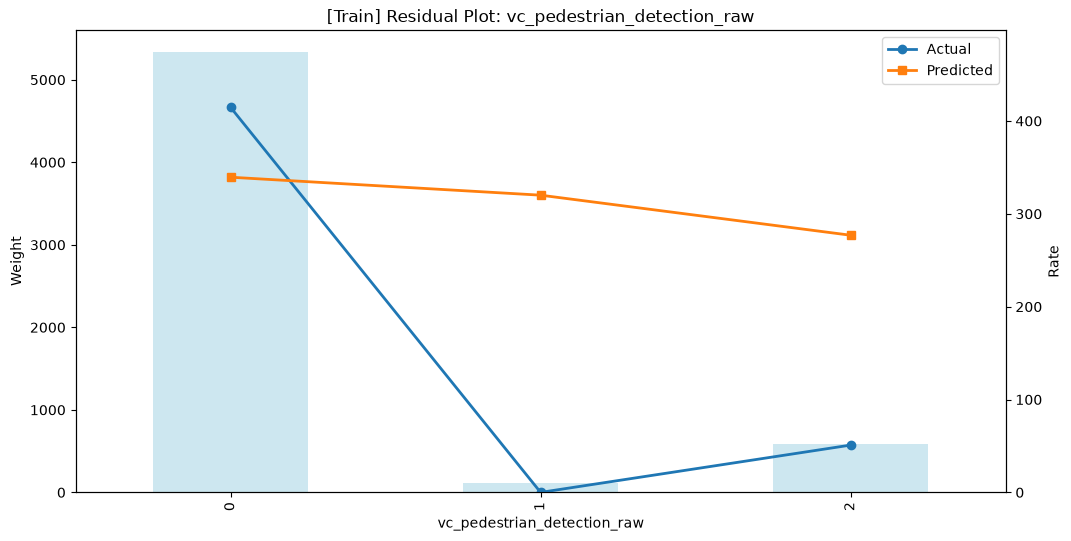

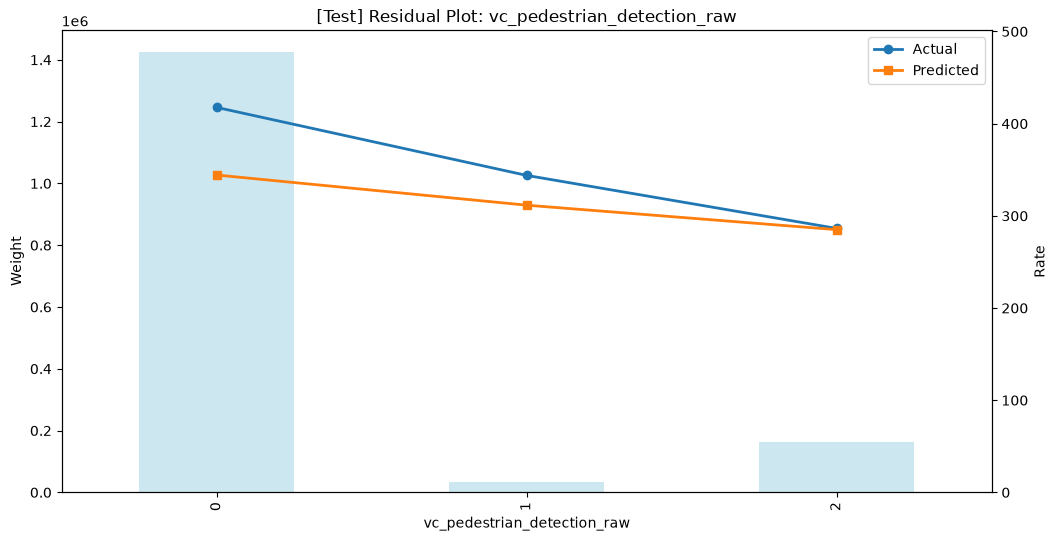


FEATURE: vc_fog_lights_raw


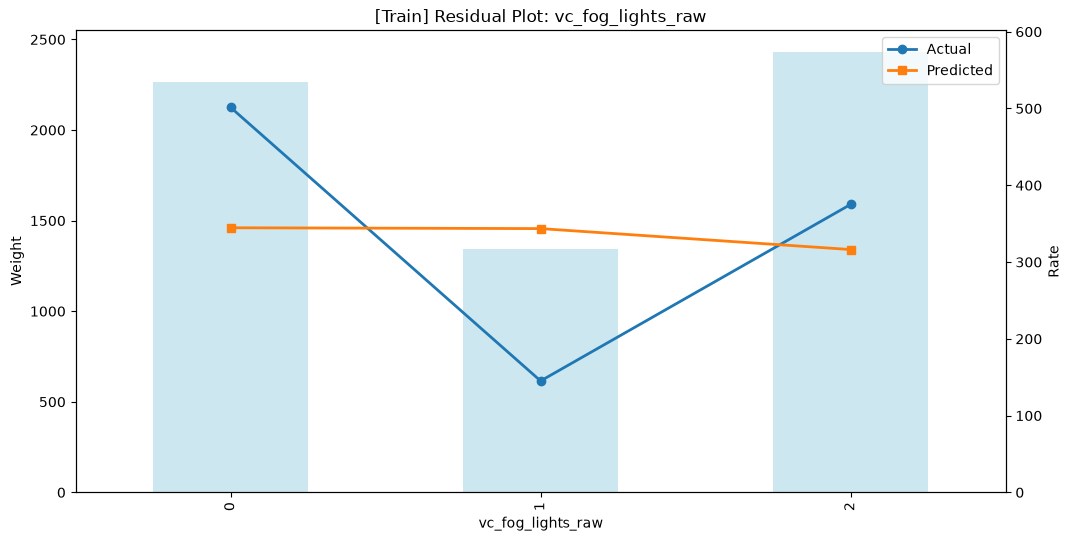

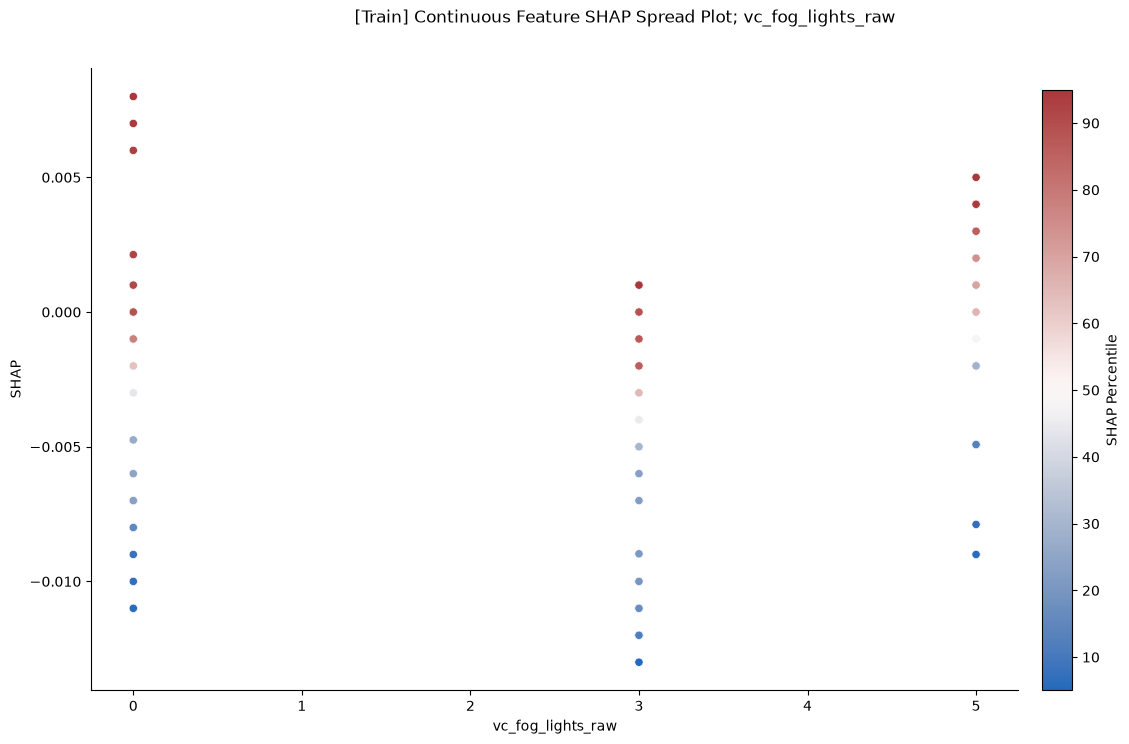

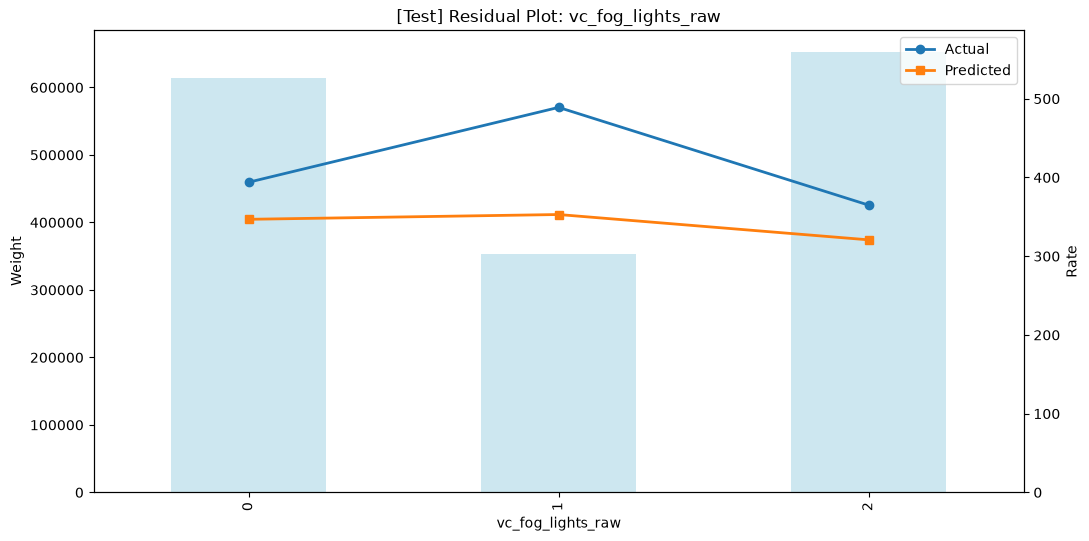

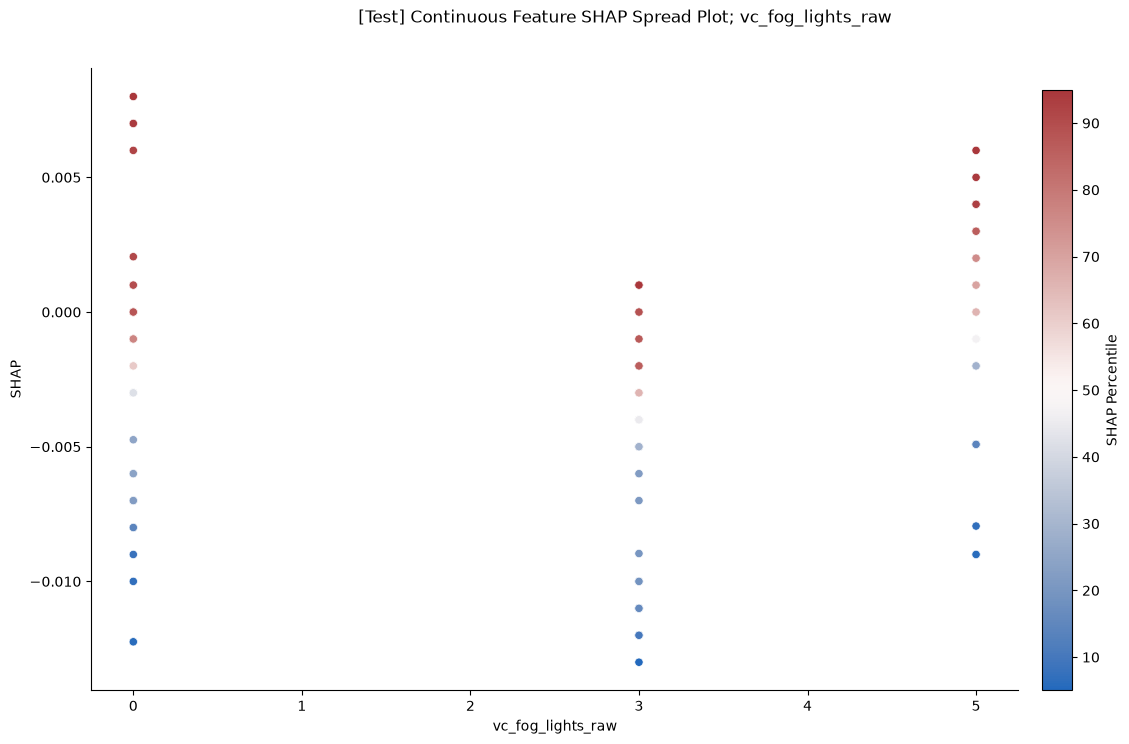


FEATURE: owt_leasepers_ind


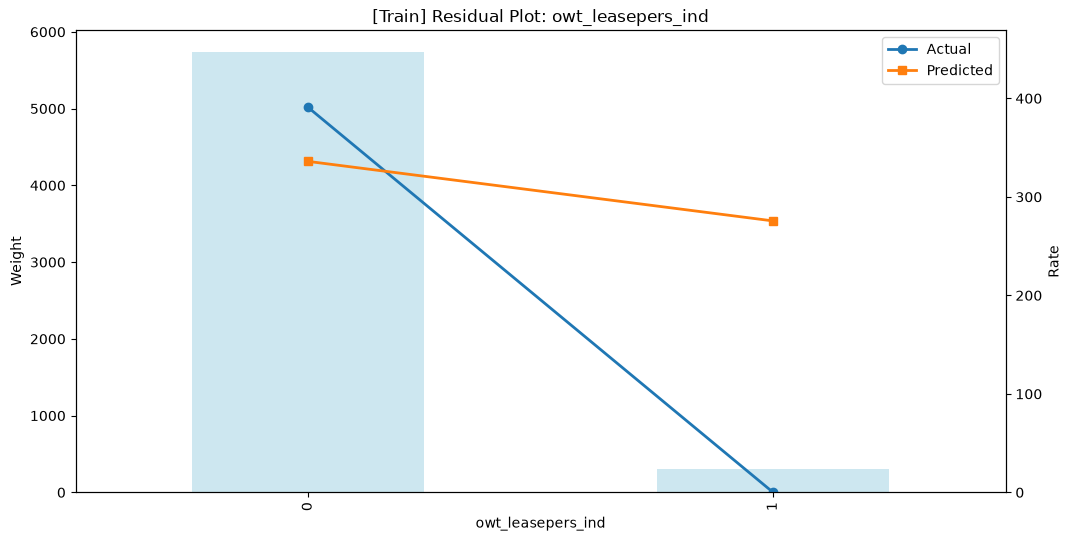

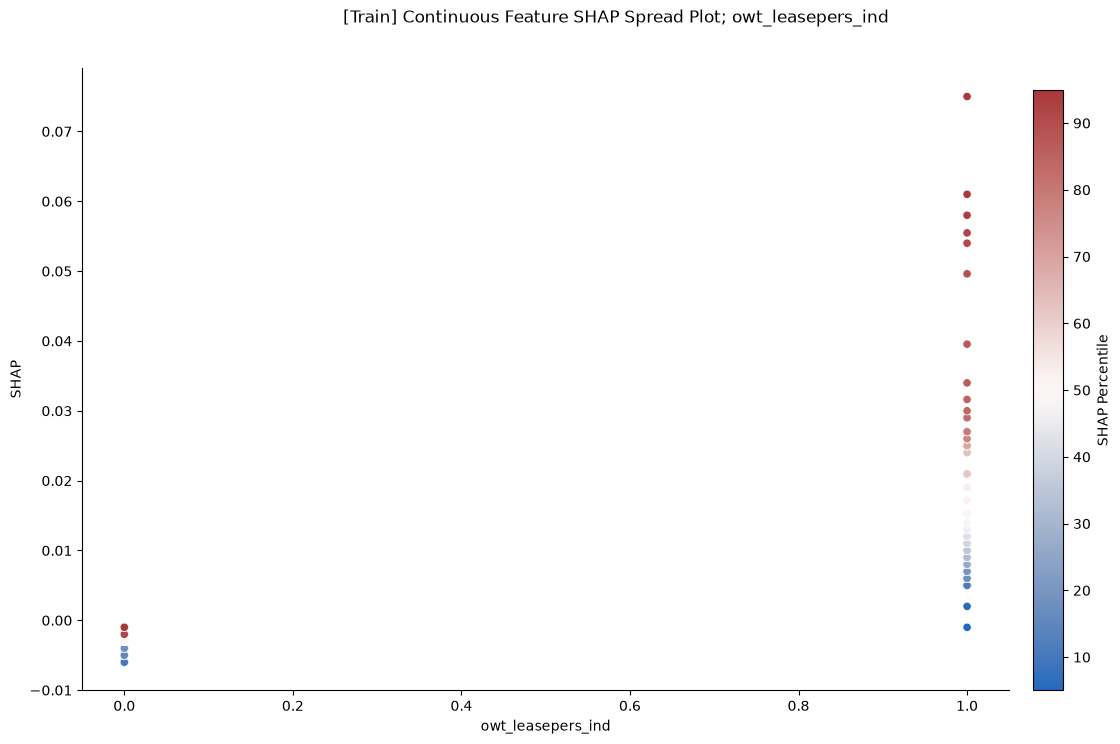

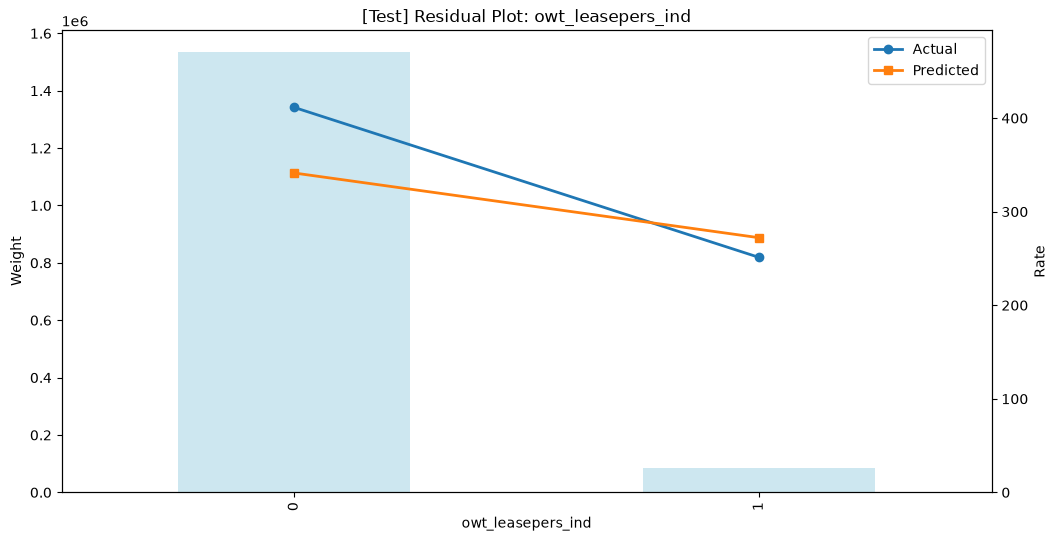

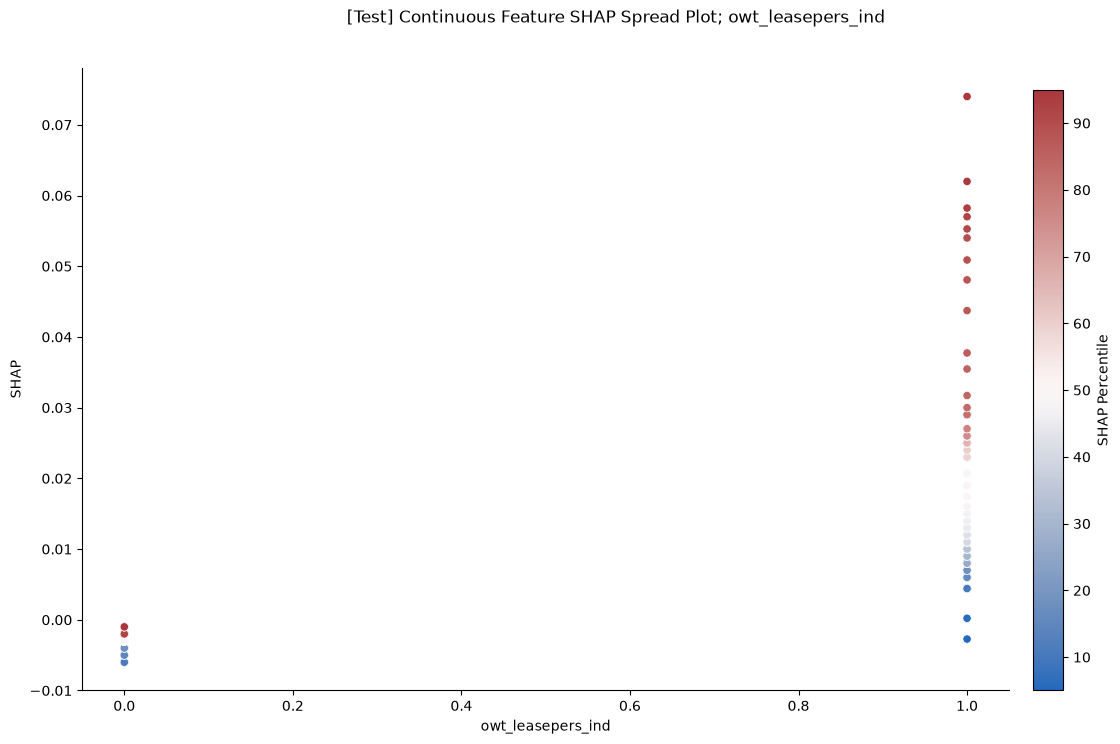


[OK] Displayed 140 plots


In [13]:
from IPython.display import Image, display
print("\n" + "="*60)
print("DISPLAYING ALL PLOTS")
print("="*60)
for f in features:
    if f not in plots_by_feature or not plots_by_feature[f]:
        continue
    print("\n" + "="*60)
    print(f"FEATURE: {f}")
    print("="*60)
    for plot_path in plots_by_feature[f]:
        if Path(plot_path).exists():
            display(Image(filename=plot_path))
        else:
            print(f"WARNING: {plot_path} not found")
print(f"\n[OK] Displayed {sum(len(v) for v in plots_by_feature.values())} plots")

In [14]:
summary["features"] = features
summary["top_n"] = top_n
summary_file = f"{output_base}/results/07_analysis_summary.yaml"
with open(summary_file, "w") as f:
    yaml.dump(summary, f)
print(f"\nSummary: {summary_file}")


Summary: output/car_coll/v1/results/07_analysis_summary.yaml


In [15]:
print("\n" + "#"*40)
print("# STAGE 07: COMPLETE")
print("#"*40)
print(f"Plots: {summary['plots']}")


########################################
# STAGE 07: COMPLETE
########################################
Plots: 140
